In [1]:
# CELL 1: Imports et options d'affichage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings


def ignorer_avertissements():
    # Avertissements internes de trois bibliothèques, sans effet sur les résultats : Keras (DeprecationWarning à la
    # sauvegarde du réseau), seaborn (PendingDeprecationWarning des boîtes à moustaches horizontales) et
    # scikit-learn (UserWarning de la propagation de la configuration aux processus d'entraînement parallèle).
    # L'entraînement parallèle peut remplacer la liste des filtres : la fonction est rappelée en tête des
    # cellules concernées
    warnings.filterwarnings('ignore', category=DeprecationWarning, module='keras')
    warnings.filterwarnings('ignore', category=PendingDeprecationWarning, module='seaborn')
    warnings.filterwarnings('ignore', category=UserWarning, module='sklearn.utils.parallel')


ignorer_avertissements()

# Style des graphiques
sns.set_theme(style="whitegrid")
# Affichage des tableaux : toutes les colonnes, sur une largeur de 200 caractères, textes complets
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)

In [2]:
# CELL 2: Chargement des données J+1

# Jeux de données J+1 produits par 02_preprocessing
dossier = '../data/output/'
X_train_scaled = pd.read_csv(dossier + 'X_train_J1_scaled.csv')
X_test_scaled = pd.read_csv(dossier + 'X_test_J1_scaled.csv')
X_train_arbres = pd.read_csv(dossier + 'X_train_J1_arbres.csv')
X_test_arbres = pd.read_csv(dossier + 'X_test_J1_arbres.csv')
y_train = pd.read_csv(dossier + 'y_train_J1.csv')['RainTomorrow']
y_test = pd.read_csv(dossier + 'y_test_J1.csv')['RainTomorrow']
meta_train = pd.read_csv(dossier + 'meta_train_J1.csv')
meta_test = pd.read_csv(dossier + 'meta_test_J1.csv')
meta_train['Date'] = pd.to_datetime(meta_train['Date'])
meta_test['Date'] = pd.to_datetime(meta_test['Date'])

# Transformations ajustées sur X_train en 02 (taux de pluie par station, scalers et leurs colonnes)
artefacts = joblib.load('../models/preprocessing_artifacts.joblib')

print(f"X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}")
print(f"X_train_arbres: {X_train_arbres.shape} | X_test_arbres: {X_test_arbres.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print(f"meta_train: {meta_train.shape} | meta_test: {meta_test.shape}")
print(f"\nColonnes ({X_train_scaled.shape[1]}): {list(X_train_scaled.columns)}")
print(f"Mêmes colonnes dans les jeux mis à l'échelle et non mis à l'échelle: "
      f"{list(X_train_scaled.columns) == list(X_train_arbres.columns)}")
print(f"Location_encoded mise à l'échelle par StandardScaler en 02: "
      f"{'Location_encoded' in artefacts['colonnes_scalers']['StandardScaler']}")
print(f"\nTaux de pluie le lendemain (y = 1): entraînement {y_train.mean() * 100:.2f}% | test {y_test.mean() * 100:.2f}%")

X_train_scaled: (113748, 24) | X_test_scaled: (28445, 24)
X_train_arbres: (113748, 24) | X_test_arbres: (28445, 24)
y_train: (113748,) | y_test: (28445,)
meta_train: (113748, 2) | meta_test: (28445, 2)

Colonnes (24): ['MinTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Temp3pm', 'RainToday', 'Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month_sin', 'Month_cos', 'Season_sin', 'Season_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'Location_encoded']
Mêmes colonnes dans les jeux mis à l'échelle et non mis à l'échelle: True
Location_encoded mise à l'échelle par StandardScaler en 02: True

Taux de pluie le lendemain (y = 1): entraînement 22.44% | test 22.32%


In [3]:
# CELL 3: Définition des plis chronologiques (mêmes plis que le pré-traitement)

# Dates uniques de l'entraînement, triées, découpées en 6 blocs consécutifs de taille (presque) égale
dates_uniques = np.sort(meta_train['Date'].unique())
blocs = np.array_split(dates_uniques, 6)

# Pli k (k = 1 à 5) : entraînement = blocs 1 à k, validation = bloc k+1 (fenêtre croissante)
plis = []
for k in range(1, 6):
    dates_tr = np.concatenate(blocs[:k])
    dates_va = blocs[k]
    masque_tr = meta_train['Date'].isin(dates_tr)
    masque_va = meta_train['Date'].isin(dates_va)
    plis.append((masque_tr, masque_va))

    pct_yes_va = y_train[masque_va].mean() * 100
    dates_entrainement = meta_train.loc[masque_tr, 'Date']
    dates_validation = meta_train.loc[masque_va, 'Date']
    print(f"Pli {k}:")
    print(f"  Entraînement: du {str(dates_entrainement.min())[:10]} au {str(dates_entrainement.max())[:10]}"
          f" ({masque_tr.sum()} lignes)")
    print(f"  Validation:   du {str(dates_validation.min())[:10]} au {str(dates_validation.max())[:10]}"
          f" ({masque_va.sum()} lignes, RainTomorrow = Yes: {pct_yes_va:.2f}%)")

Pli 1:
  Entraînement: du 2007-11-01 au 2009-02-16 (4417 lignes)
  Validation:   du 2009-02-17 au 2010-06-05 (21500 lignes, RainTomorrow = Yes: 22.10%)
Pli 2:
  Entraînement: du 2007-11-01 au 2010-06-05 (25917 lignes)
  Validation:   du 2010-06-06 au 2011-10-22 (21359 lignes, RainTomorrow = Yes: 25.39%)
Pli 3:
  Entraînement: du 2007-11-01 au 2011-10-22 (47276 lignes)
  Validation:   du 2011-10-23 au 2013-04-07 (21448 lignes, RainTomorrow = Yes: 22.39%)
Pli 4:
  Entraînement: du 2007-11-01 au 2013-04-07 (68724 lignes)
  Validation:   du 2013-04-08 au 2014-07-24 (22636 lignes, RainTomorrow = Yes: 22.15%)
Pli 5:
  Entraînement: du 2007-11-01 au 2014-07-24 (91360 lignes)
  Validation:   du 2014-07-25 au 2015-11-09 (22388 lignes, RainTomorrow = Yes: 20.85%)


In [4]:
# CELL 4: Fonctions de recalcul de Location_encoded par pli

from sklearn.preprocessing import StandardScaler

# Dans les fichiers, Location_encoded a été calculée sur tout l'ensemble d'entraînement.
# Dans un pli, elle est recalculée sur la partie entraînement du pli uniquement, pour que la partie
# validation n'intervienne jamais dans son calcul.


def colonne_location(X):
    # Location_encoded (jeu J+1) ou Location_encoded_J2 (jeu J+2)
    if 'Location_encoded_J2' in X.columns:
        return 'Location_encoded_J2'
    return 'Location_encoded'


def encoder_location_pli(X, meta, y, pli):
    # Taux de pluie (y = 1) par station sur la partie entraînement du pli (pli = masques entraînement, validation) ;
    # station absente de cette partie : taux global de la partie entraînement
    X_tr = X[pli[0]].copy()
    X_va = X[pli[1]].copy()
    location_tr = meta.loc[pli[0], 'Location']
    taux_station = y[pli[0]].groupby(location_tr).mean()
    taux_global = y[pli[0]].mean()
    X_tr[colonne_location(X)] = location_tr.map(taux_station).fillna(taux_global)
    X_va[colonne_location(X)] = meta.loc[pli[1], 'Location'].map(taux_station).fillna(taux_global)
    return X_tr, X_va


def standardiser_location(X_tr, X_va):
    # Même règle que dans 02 (CELL 74) : StandardScaler ajusté sur la partie entraînement du pli
    scaler = StandardScaler()
    X_tr[[colonne_location(X_tr)]] = scaler.fit_transform(X_tr[[colonne_location(X_tr)]])
    X_va[[colonne_location(X_va)]] = scaler.transform(X_va[[colonne_location(X_va)]])
    return X_tr, X_va

In [5]:
# CELL 5: Préparation des données de chaque pli

# Données de chaque pli préparées une seule fois, puis réutilisées par toutes les étapes de validation :
# Location_encoded recalculée sur la partie entraînement du pli (et mise à l'échelle pour les données mises à l'échelle)
donnees_plis = []
y_va_plis = []
for k in range(len(plis)):
    Xs_tr, Xs_va = encoder_location_pli(X_train_scaled, meta_train, y_train, plis[k])
    Xs_tr, Xs_va = standardiser_location(Xs_tr, Xs_va)
    Xa_tr, Xa_va = encoder_location_pli(X_train_arbres, meta_train, y_train, plis[k])
    donnees_plis.append({'Xs_tr': Xs_tr, 'Xs_va': Xs_va, 'Xa_tr': Xa_tr, 'Xa_va': Xa_va,
                         'y_tr': y_train[plis[k][0]], 'y_va': y_train[plis[k][1]]})
    y_va_plis.append(y_train[plis[k][1]])

In [6]:
# CELL 6: Location_encoded recalculée sur le pli 5

d = donnees_plis[4]
print("Pli 5, Location_encoded recalculée sur la partie entraînement du pli:")
print(f"  Non mise à l'échelle : min = {d['Xa_tr']['Location_encoded'].min():.4f} | max = {d['Xa_tr']['Location_encoded'].max():.4f}")
print(f"  Mise à l'échelle     : moyenne (entraînement) = {d['Xs_tr']['Location_encoded'].mean():.4f} | "
      f"écart-type (entraînement) = {d['Xs_tr']['Location_encoded'].std():.4f}")
print(f"  Valeurs manquantes   : {int(d['Xs_va']['Location_encoded'].isnull().sum())} (validation, mise à l'échelle), "
      f"{int(d['Xa_va']['Location_encoded'].isnull().sum())} (validation, non mise à l'échelle)")

Pli 5, Location_encoded recalculée sur la partie entraînement du pli:
  Non mise à l'échelle : min = 0.0714 | max = 0.3736
  Mise à l'échelle     : moyenne (entraînement) = -0.0000 | écart-type (entraînement) = 1.0000
  Valeurs manquantes   : 0 (validation, mise à l'échelle), 0 (validation, non mise à l'échelle)


In [7]:
# CELL 7: Modèle naïf de référence (toujours "pas de pluie")

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Prédiction constante 0 ("pas de pluie") sur la partie validation de chaque pli : seuil minimal à dépasser
lignes_naif = []
for k in range(len(plis)):
    y_va = y_va_plis[k]
    pred_naif = np.zeros(len(y_va)).astype(int)
    # Le modèle naïf ne prédit jamais la pluie : aucune prédiction positive, donc précision et F1
    # valent 0 par définition ; rappel et exactitude sont calculés normalement
    lignes_naif.append({
        'Pli': k + 1,
        'Exactitude': accuracy_score(y_va, pred_naif),
        'Précision': 0.0,
        'Rappel': recall_score(y_va, pred_naif),
        'F1': 0.0
    })

table_naif = pd.DataFrame(lignes_naif)
print("Modèle naïf (toujours 0), partie validation de chaque pli:")
print(table_naif)
print(f"\nMoyennes: exactitude = {table_naif['Exactitude'].mean():.4f} | précision = {table_naif['Précision'].mean():.4f} | "
      f"rappel = {table_naif['Rappel'].mean():.4f} | F1 = {table_naif['F1'].mean():.4f}")

Modèle naïf (toujours 0), partie validation de chaque pli:
   Pli  Exactitude  Précision  Rappel   F1
0    1    0.778977        0.0     0.0  0.0
1    2    0.746149        0.0     0.0  0.0
2    3    0.776110        0.0     0.0  0.0
3    4    0.778494        0.0     0.0  0.0
4    5    0.791540        0.0     0.0  0.0

Moyennes: exactitude = 0.7743 | précision = 0.0000 | rappel = 0.0000 | F1 = 0.0000


In [8]:
# CELL 8: Fonctions d'entraînement et de mesure (scikit-learn et XGBoost)

from time import time
from sklearn.metrics import roc_curve, auc


def entrainer_et_predire(modele, X_fit, y_fit, X_va):
    # Entraînement, classe prédite et probabilité de la classe 1 sur la validation, avec les durées
    debut = time()
    modele.fit(X_fit, y_fit)
    duree_fit = time() - debut
    debut = time()
    pred = modele.predict(X_va)
    duree_pred = time() - debut
    proba_1 = modele.predict_proba(X_va)[:, 1]
    return pred, proba_1, duree_fit, duree_pred


def mesurer(ligne, y_va, pred, proba_1):
    # Complète la ligne (pli, modèle, option éventuelle, durées) avec les métriques de la classe 1, puis l'affiche
    fpr, tpr, seuils_roc = roc_curve(y_va, proba_1)
    ligne['F1'] = f1_score(y_va, pred)
    ligne['Précision'] = precision_score(y_va, pred)
    ligne['Rappel'] = recall_score(y_va, pred)
    ligne['Exactitude'] = accuracy_score(y_va, pred)
    ligne['AUC'] = auc(fpr, tpr)
    libelle = f"Pli {ligne['Pli']} | {ligne['Modèle']}"
    if 'Option' in ligne:
        libelle = libelle + f" | {ligne['Option']}"
    print(f"{libelle} | F1 = {ligne['F1']:.4f} | précision = {ligne['Précision']:.4f} | rappel = {ligne['Rappel']:.4f} | "
          f"exactitude = {ligne['Exactitude']:.4f} | AUC = {ligne['AUC']:.4f} | "
          f"entraînement {ligne['Temps entraînement (s)']:.2f} s | prédiction {ligne['Temps prédiction (s)']:.2f} s")
    return ligne

In [9]:
# CELL 9: Fonctions du réseau de neurones (Keras)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Réseau des paramètres par défaut (même réseau que dans 02, CELL 32) : couches cachées de 64 et 32 neurones, sans Dropout
reseau_par_defaut = {'couches': (64, 32), 'dropout': 0}


def entrainer_reseau(X_fit, y_fit, parametres):
    # Graine fixée, couche d'entrée, 2 couches cachées (Dropout après chacune seulement si le taux est non nul),
    # sortie softmax à 2 classes ; renvoie le réseau entraîné et la durée d'entraînement
    tf.keras.utils.set_random_seed(42)
    reseau = Sequential()
    reseau.add(Input(shape=(X_fit.shape[1],)))
    reseau.add(Dense(parametres['couches'][0], activation='relu'))
    if parametres['dropout'] > 0:
        reseau.add(Dropout(rate=parametres['dropout']))
    reseau.add(Dense(parametres['couches'][1], activation='relu'))
    if parametres['dropout'] > 0:
        reseau.add(Dropout(rate=parametres['dropout']))
    reseau.add(Dense(2, activation='softmax'))
    reseau.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    debut = time()
    reseau.fit(X_fit, y_fit, epochs=30, batch_size=32, validation_split=0.1,
               callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=0)
    return reseau, time() - debut


def predire_reseau(reseau, X_va):
    # Classe prédite = classe de plus forte probabilité ; probabilité de la classe 1 = 2e colonne
    debut = time()
    probas = reseau.predict(X_va, verbose=0)
    duree_pred = time() - debut
    return np.argmax(probas, axis=1), probas[:, 1], duree_pred

In [10]:
# CELL 10: Paramètres par défaut : régression logistique (données mises à l'échelle)

from sklearn.linear_model import LogisticRegression

# Régression logistique, KNN et réseau de neurones : données mises à l'échelle ; Random Forest et XGBoost :
# données non mises à l'échelle. Aucune correction du déséquilibre à ce stade, seuil de décision par défaut
modeles = ['Régression logistique', 'Random Forest', 'XGBoost', 'KNN', 'Réseau de neurones']
resultats = []
for k in range(len(plis)):
    d = donnees_plis[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Régression logistique | F1 = 0.5689 | précision = 0.7163 | rappel = 0.4718 | exactitude = 0.8420 | AUC = 0.8441 | entraînement 0.04 s | prédiction 0.00 s


Pli 2 | Régression logistique | F1 = 0.6071 | précision = 0.7411 | rappel = 0.5142 | exactitude = 0.8311 | AUC = 0.8575 | entraînement 0.18 s | prédiction 0.00 s


Pli 3 | Régression logistique | F1 = 0.5629 | précision = 0.7168 | rappel = 0.4633 | exactitude = 0.8389 | AUC = 0.8544 | entraînement 0.24 s | prédiction 0.00 s


Pli 4 | Régression logistique | F1 = 0.6011 | précision = 0.7081 | rappel = 0.5221 | exactitude = 0.8465 | AUC = 0.8617 | entraînement 0.45 s | prédiction 0.00 s


Pli 5 | Régression logistique | F1 = 0.5437 | précision = 0.7146 | rappel = 0.4388 | exactitude = 0.8465 | AUC = 0.8518 | entraînement 0.67 s | prédiction 0.00 s


In [11]:
# CELL 11: Paramètres par défaut : Random Forest (données non mises à l'échelle)

from sklearn.ensemble import RandomForestClassifier

for k in range(len(plis)):
    d = donnees_plis[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(RandomForestClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Random Forest | F1 = 0.5592 | précision = 0.7104 | rappel = 0.4611 | exactitude = 0.8393 | AUC = 0.8448 | entraînement 0.23 s | prédiction 0.07 s


Pli 2 | Random Forest | F1 = 0.6090 | précision = 0.7607 | rappel = 0.5077 | exactitude = 0.8345 | AUC = 0.8623 | entraînement 0.58 s | prédiction 0.09 s


Pli 3 | Random Forest | F1 = 0.5836 | précision = 0.7641 | rappel = 0.4721 | exactitude = 0.8492 | AUC = 0.8680 | entraînement 1.10 s | prédiction 0.12 s


Pli 4 | Random Forest | F1 = 0.6192 | précision = 0.7506 | rappel = 0.5269 | exactitude = 0.8564 | AUC = 0.8799 | entraînement 1.56 s | prédiction 0.11 s


Pli 5 | Random Forest | F1 = 0.5614 | précision = 0.7588 | rappel = 0.4455 | exactitude = 0.8549 | AUC = 0.8711 | entraînement 2.33 s | prédiction 0.14 s


In [12]:
# CELL 12: Paramètres par défaut : XGBoost (données non mises à l'échelle)

from xgboost import XGBClassifier

for k in range(len(plis)):
    d = donnees_plis[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(XGBClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'XGBoost',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | XGBoost | F1 = 0.5567 | précision = 0.6524 | rappel = 0.4855 | exactitude = 0.8291 | AUC = 0.8377 | entraînement 0.29 s | prédiction 0.02 s


Pli 2 | XGBoost | F1 = 0.6395 | précision = 0.7324 | rappel = 0.5675 | exactitude = 0.8376 | AUC = 0.8668 | entraînement 0.31 s | prédiction 0.01 s


Pli 3 | XGBoost | F1 = 0.6144 | précision = 0.7341 | rappel = 0.5283 | exactitude = 0.8515 | AUC = 0.8726 | entraînement 0.44 s | prédiction 0.02 s


Pli 4 | XGBoost | F1 = 0.6453 | précision = 0.7315 | rappel = 0.5772 | exactitude = 0.8594 | AUC = 0.8875 | entraînement 0.48 s | prédiction 0.02 s


Pli 5 | XGBoost | F1 = 0.5924 | précision = 0.7428 | rappel = 0.4926 | exactitude = 0.8587 | AUC = 0.8808 | entraînement 0.54 s | prédiction 0.01 s


In [13]:
# CELL 13: Paramètres par défaut : KNN (données mises à l'échelle)

from sklearn.neighbors import KNeighborsClassifier

for k in range(len(plis)):
    d = donnees_plis[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(KNeighborsClassifier(n_jobs=-1),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'KNN',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | KNN | F1 = 0.4839 | précision = 0.6398 | rappel = 0.3891 | exactitude = 0.8166 | AUC = 0.7716 | entraînement 0.01 s | prédiction 0.29 s


Pli 2 | KNN | F1 = 0.5680 | précision = 0.6816 | rappel = 0.4869 | exactitude = 0.8120 | AUC = 0.8068 | entraînement 0.01 s | prédiction 0.48 s


Pli 3 | KNN | F1 = 0.5422 | précision = 0.6594 | rappel = 0.4604 | exactitude = 0.8260 | AUC = 0.8045 | entraînement 0.02 s | prédiction 1.13 s


Pli 4 | KNN | F1 = 0.5746 | précision = 0.6703 | rappel = 0.5028 | exactitude = 0.8351 | AUC = 0.8246 | entraînement 0.02 s | prédiction 1.45 s


Pli 5 | KNN | F1 = 0.5312 | précision = 0.6639 | rappel = 0.4427 | exactitude = 0.8371 | AUC = 0.8068 | entraînement 0.04 s | prédiction 1.95 s


In [14]:
# CELL 14: Paramètres par défaut : réseau de neurones (données mises à l'échelle)

for k in range(len(plis)):
    d = donnees_plis[k]
    reseau, duree_fit = entrainer_reseau(d['Xs_tr'].values, d['y_tr'].values, reseau_par_defaut)
    pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
    ligne = {'Pli': k + 1, 'Modèle': 'Réseau de neurones',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats.append(mesurer(ligne, d['y_va'], pred, proba_1))

table_resultats = pd.DataFrame(resultats)

Pli 1 | Réseau de neurones | F1 = 0.5876 | précision = 0.6685 | rappel = 0.5242 | exactitude = 0.8374 | AUC = 0.8498 | entraînement 4.26 s | prédiction 0.65 s


Pli 2 | Réseau de neurones | F1 = 0.6427 | précision = 0.7307 | rappel = 0.5736 | exactitude = 0.8381 | AUC = 0.8725 | entraînement 17.76 s | prédiction 0.73 s


Pli 3 | Réseau de neurones | F1 = 0.5988 | précision = 0.7184 | rappel = 0.5133 | exactitude = 0.8460 | AUC = 0.8739 | entraînement 21.21 s | prédiction 0.82 s


Pli 4 | Réseau de neurones | F1 = 0.6305 | précision = 0.7305 | rappel = 0.5546 | exactitude = 0.8560 | AUC = 0.8826 | entraînement 24.78 s | prédiction 0.83 s


Pli 5 | Réseau de neurones | F1 = 0.5865 | précision = 0.7477 | rappel = 0.4825 | exactitude = 0.8582 | AUC = 0.8783 | entraînement 42.22 s | prédiction 0.77 s


In [15]:
# CELL 15: Récapitulatif des 5 modèles (paramètres par défaut) et du modèle naïf

# Moyennes sur les 5 plis pour chaque modèle (écart-type de l'échantillon des 5 F1)
lignes_recap = []
for nom in modeles:
    r = table_resultats[table_resultats['Modèle'] == nom]
    lignes_recap.append({
        'Modèle': nom,
        'F1 moyen': r['F1'].mean(),
        'Écart-type F1': r['F1'].std(),
        'Précision moyenne': r['Précision'].mean(),
        'Rappel moyen': r['Rappel'].mean(),
        'Exactitude moyenne': r['Exactitude'].mean(),
        'AUC moyenne': r['AUC'].mean(),
        'Temps entraînement moyen (s)': r['Temps entraînement (s)'].mean(),
        'Temps prédiction moyen (s)': r['Temps prédiction (s)'].mean()
    })

# Ligne du modèle naïf (pas de probabilité, donc pas d'AUC, et pas d'entraînement)
lignes_recap.append({
    'Modèle': 'Naïf (toujours pas de pluie)',
    'F1 moyen': table_naif['F1'].mean(),
    'Écart-type F1': table_naif['F1'].std(),
    'Précision moyenne': table_naif['Précision'].mean(),
    'Rappel moyen': table_naif['Rappel'].mean(),
    'Exactitude moyenne': table_naif['Exactitude'].mean(),
    'AUC moyenne': None,
    'Temps entraînement moyen (s)': None,
    'Temps prédiction moyen (s)': None
})

table_recap = pd.DataFrame(lignes_recap).sort_values('F1 moyen', ascending=False).reset_index().drop(columns=['index'])

In [16]:
# CELL 16: Affichage du récapitulatif (paramètres par défaut)

# F1 moyen en pleine précision, 4 décimales pour les autres colonnes
table_affichage = table_recap.copy()
f1_texte = []
for v in table_recap['F1 moyen'].values:
    f1_texte.append(str(v))
table_affichage['F1 moyen'] = f1_texte
for col in ['Écart-type F1', 'Précision moyenne', 'Rappel moyen', 'Exactitude moyenne', 'AUC moyenne',
            'Temps entraînement moyen (s)', 'Temps prédiction moyen (s)']:
    valeurs_arrondies = []
    for v in table_recap[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage[col] = valeurs_arrondies
print("Récapitulatif des 5 modèles (paramètres par défaut) et du modèle naïf, validation chronologique sur 5 plis:")
print(table_affichage)

Récapitulatif des 5 modèles (paramètres par défaut) et du modèle naïf, validation chronologique sur 5 plis:
                         Modèle            F1 moyen  Écart-type F1  Précision moyenne  Rappel moyen  Exactitude moyenne  AUC moyenne  Temps entraînement moyen (s)  Temps prédiction moyen (s)
0                       XGBoost  0.6096575149112418         0.0363             0.7187        0.5302              0.8473       0.8691                        0.4108                      0.0147
1            Réseau de neurones  0.6092436988237679         0.0258             0.7192        0.5297              0.8471       0.8714                       22.0448                      0.7597
2                 Random Forest  0.5864700117470617         0.0272             0.7489        0.4827              0.8469       0.8652                        1.1614                      0.1051
3         Régression logistique  0.5767435236542883         0.0267             0.7194        0.4821              0.8410       0.

Figure sauvegardée: figures/etape3_01_modeles_par_defaut.png


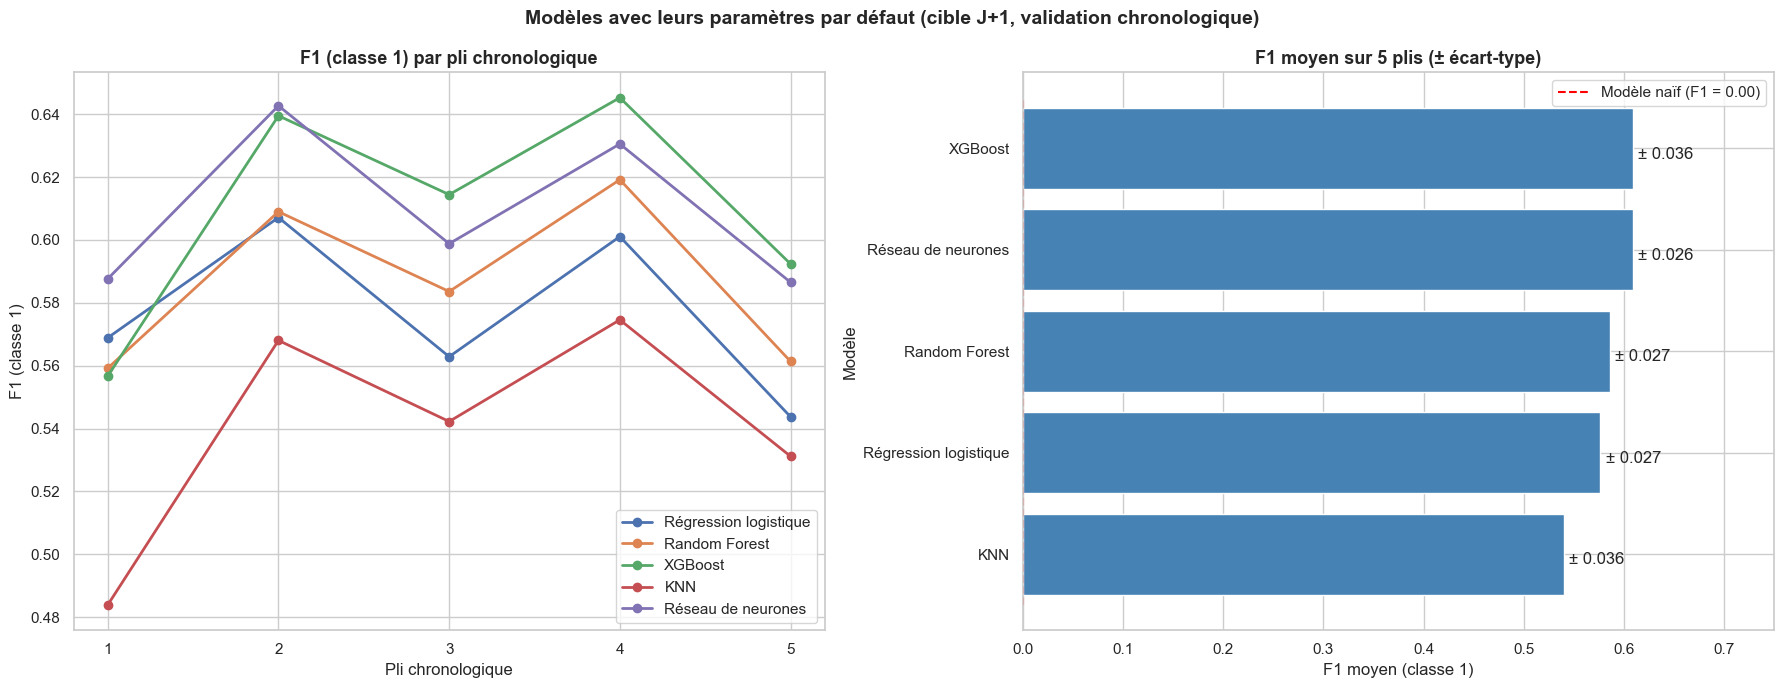

In [17]:
# CELL 17: Visualisation (paramètres par défaut)

numeros_plis = np.arange(1, len(plis) + 1)
f1_naif = table_naif['F1'].mean()

plt.figure(figsize=(18, 7))

# Panneau 1 : F1 de chaque pli pour les 5 modèles
plt.subplot(1, 2, 1)
for nom in modeles:
    r = table_resultats[table_resultats['Modèle'] == nom]
    plt.plot(numeros_plis, r['F1'], marker='o', linewidth=2, label=nom)
plt.title("F1 (classe 1) par pli chronologique", fontsize=13, fontweight='bold')
plt.xlabel("Pli chronologique")
plt.ylabel("F1 (classe 1)")
plt.xticks(numeros_plis)
plt.legend()

# Panneau 2 : F1 moyen en barres horizontales (meilleur modèle en haut), écart-type au bout de chaque barre,
# modèle naïf en ligne de référence
recap_modeles = table_recap[table_recap['Modèle'] != 'Naïf (toujours pas de pluie)'].sort_values('F1 moyen')
plt.subplot(1, 2, 2)
plt.barh(recap_modeles['Modèle'], recap_modeles['F1 moyen'], color='steelblue')
for i in range(len(recap_modeles)):
    plt.text(recap_modeles['F1 moyen'].values[i] + 0.005, i - 0.1, f"± {recap_modeles['Écart-type F1'].values[i]:.3f}")
plt.plot([f1_naif, f1_naif], [-0.5, len(recap_modeles) - 0.5], color='red', linestyle='--',
         label=f"Modèle naïf (F1 = {f1_naif:.2f})")
plt.title("F1 moyen sur 5 plis (± écart-type)", fontsize=13, fontweight='bold')
plt.xlabel("F1 moyen (classe 1)")
plt.ylabel("Modèle")
plt.xlim(0, 0.75)
plt.legend()

plt.suptitle("Modèles avec leurs paramètres par défaut (cible J+1, validation chronologique)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_01_modeles_par_defaut.png', dpi=150)
print("Figure sauvegardée: figures/etape3_01_modeles_par_defaut.png")
plt.show()

In [18]:
# CELL 18: SMOTENC sur la partie entraînement de chaque pli

from imblearn.over_sampling import SMOTENC

# Position de la colonne catégorielle RainToday (valeurs 0/1), la même dans les deux jeux
position_raintoday = list(X_train_scaled.columns).index('RainToday')
print(f"Position de la colonne RainToday: {position_raintoday}\n")

# SMOTENC ajusté et appliqué sur la partie entraînement de chaque pli uniquement, jamais sur la validation :
# une fois pour les données mises à l'échelle, une fois pour les données non mises à l'échelle.
# Les données rééchantillonnées sont ajoutées aux données du pli et réutilisées par toutes les étapes suivantes.
for k in range(len(plis)):
    d = donnees_plis[k]
    smote_s = SMOTENC(categorical_features=[position_raintoday], random_state=42)
    debut = time()
    Xs_tr_sm, ys_tr_sm = smote_s.fit_resample(d['Xs_tr'], d['y_tr'])
    duree_smote_s = time() - debut
    smote_a = SMOTENC(categorical_features=[position_raintoday], random_state=42)
    debut = time()
    Xa_tr_sm, ya_tr_sm = smote_a.fit_resample(d['Xa_tr'], d['y_tr'])
    duree_smote_a = time() - debut
    d['Xs_tr_sm'] = Xs_tr_sm
    d['ys_tr_sm'] = ys_tr_sm
    d['Xa_tr_sm'] = Xa_tr_sm
    d['ya_tr_sm'] = ya_tr_sm
    d['duree_smote_a'] = duree_smote_a
    if k == 0:
        print(f"Durée du premier SMOTENC (pli 1, données mises à l'échelle): {duree_smote_s:.2f} s")
    print(f"Pli {k + 1} | SMOTENC: {duree_smote_s:.2f} s (mises à l'échelle), {duree_smote_a:.2f} s (non mises à l'échelle) | "
          f"entraînement: {len(d['y_tr'])} -> {len(ys_tr_sm)} lignes, y = 1: {d['y_tr'].mean() * 100:.2f}% -> {ys_tr_sm.mean() * 100:.2f}%")

Position de la colonne RainToday: 9

Durée du premier SMOTENC (pli 1, données mises à l'échelle): 0.07 s
Pli 1 | SMOTENC: 0.07 s (mises à l'échelle), 0.07 s (non mises à l'échelle) | entraînement: 4417 -> 7092 lignes, y = 1: 19.72% -> 50.00%


Pli 2 | SMOTENC: 1.19 s (mises à l'échelle), 1.16 s (non mises à l'échelle) | entraînement: 25917 -> 40588 lignes, y = 1: 21.70% -> 50.00%


Pli 3 | SMOTENC: 3.80 s (mises à l'échelle), 3.94 s (non mises à l'échelle) | entraînement: 47276 -> 72462 lignes, y = 1: 23.36% -> 50.00%


Pli 4 | SMOTENC: 7.85 s (mises à l'échelle), 7.86 s (non mises à l'échelle) | entraînement: 68724 -> 105754 lignes, y = 1: 23.06% -> 50.00%


Pli 5 | SMOTENC: 14.50 s (mises à l'échelle), 14.25 s (non mises à l'échelle) | entraînement: 91360 -> 140998 lignes, y = 1: 22.83% -> 50.00%


In [19]:
# CELL 19: Gestion du déséquilibre : régression logistique (aucune / class_weight='balanced' / SMOTENC)

resultats_deseq = []
for k in range(len(plis)):
    d = donnees_plis[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # Pondération des classes
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000, class_weight='balanced'),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique', 'Option': "class_weight='balanced'",
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000),
                                                                d['Xs_tr_sm'], d['ys_tr_sm'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Régression logistique | aucune | F1 = 0.5689 | précision = 0.7163 | rappel = 0.4718 | exactitude = 0.8420 | AUC = 0.8441 | entraînement 0.03 s | prédiction 0.00 s
Pli 1 | Régression logistique | class_weight='balanced' | F1 = 0.5894 | précision = 0.4813 | rappel = 0.7599 | exactitude = 0.7660 | AUC = 0.8446 | entraînement 0.05 s | prédiction 0.00 s


Pli 1 | Régression logistique | SMOTENC | F1 = 0.5833 | précision = 0.4761 | rappel = 0.7529 | exactitude = 0.7622 | AUC = 0.8397 | entraînement 0.06 s | prédiction 0.00 s


Pli 2 | Régression logistique | aucune | F1 = 0.6071 | précision = 0.7411 | rappel = 0.5142 | exactitude = 0.8311 | AUC = 0.8575 | entraînement 0.13 s | prédiction 0.00 s


Pli 2 | Régression logistique | class_weight='balanced' | F1 = 0.6287 | précision = 0.5261 | rappel = 0.7811 | exactitude = 0.7658 | AUC = 0.8579 | entraînement 0.11 s | prédiction 0.00 s


Pli 2 | Régression logistique | SMOTENC | F1 = 0.6303 | précision = 0.5306 | rappel = 0.7763 | exactitude = 0.7689 | AUC = 0.8580 | entraînement 0.18 s | prédiction 0.00 s
Pli 3 | Régression logistique | aucune | F1 = 0.5629 | précision = 0.7168 | rappel = 0.4633 | exactitude = 0.8389 | AUC = 0.8544 | entraînement 0.17 s | prédiction 0.00 s


...

Pli 4 | Régression logistique | class_weight='balanced' | F1 = 0.6170 | précision = 0.5143 | rappel = 0.7708 | exactitude = 0.7880 | AUC = 0.8620 | entraînement 0.20 s | prédiction 0.00 s


Pli 4 | Régression logistique | SMOTENC | F1 = 0.6155 | précision = 0.5120 | rappel = 0.7714 | exactitude = 0.7865 | AUC = 0.8619 | entraînement 0.35 s | prédiction 0.00 s


Pli 5 | Régression logistique | aucune | F1 = 0.5437 | précision = 0.7146 | rappel = 0.4388 | exactitude = 0.8465 | AUC = 0.8518 | entraînement 0.54 s | prédiction 0.00 s


Pli 5 | Régression logistique | class_weight='balanced' | F1 = 0.5989 | précision = 0.5140 | rappel = 0.7174 | exactitude = 0.7997 | AUC = 0.8530 | entraînement 0.30 s | prédiction 0.00 s


Pli 5 | Régression logistique | SMOTENC | F1 = 0.5984 | précision = 0.5127 | rappel = 0.7187 | exactitude = 0.7990 | AUC = 0.8529 | entraînement 0.86 s | prédiction 0.00 s


In [20]:
# CELL 20: Gestion du déséquilibre : Random Forest (aucune / class_weight='balanced' / SMOTENC)

for k in range(len(plis)):
    d = donnees_plis[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(RandomForestClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # Pondération des classes
    rf_pondere = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(rf_pondere, d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest', 'Option': "class_weight='balanced'",
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(RandomForestClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr_sm'], d['ya_tr_sm'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Random Forest | aucune | F1 = 0.5592 | précision = 0.7104 | rappel = 0.4611 | exactitude = 0.8393 | AUC = 0.8448 | entraînement 0.17 s | prédiction 0.06 s


Pli 1 | Random Forest | class_weight='balanced' | F1 = 0.5935 | précision = 0.6113 | rappel = 0.5768 | exactitude = 0.8254 | AUC = 0.8450 | entraînement 0.21 s | prédiction 0.06 s


Pli 1 | Random Forest | SMOTENC | F1 = 0.5987 | précision = 0.6149 | rappel = 0.5833 | exactitude = 0.8272 | AUC = 0.8371 | entraînement 0.29 s | prédiction 0.08 s


Pli 2 | Random Forest | aucune | F1 = 0.6090 | précision = 0.7607 | rappel = 0.5077 | exactitude = 0.8345 | AUC = 0.8623 | entraînement 0.59 s | prédiction 0.10 s


Pli 2 | Random Forest | class_weight='balanced' | F1 = 0.6561 | précision = 0.6706 | rappel = 0.6422 | exactitude = 0.8291 | AUC = 0.8662 | entraînement 0.74 s | prédiction 0.08 s


...

Pli 4 | Random Forest | class_weight='balanced' | F1 = 0.6546 | précision = 0.6590 | rappel = 0.6502 | exactitude = 0.8480 | AUC = 0.8817 | entraînement 1.76 s | prédiction 0.13 s


Pli 4 | Random Forest | SMOTENC | F1 = 0.6397 | précision = 0.6932 | rappel = 0.5939 | exactitude = 0.8518 | AUC = 0.8794 | entraînement 3.38 s | prédiction 0.10 s


Pli 5 | Random Forest | aucune | F1 = 0.5614 | précision = 0.7588 | rappel = 0.4455 | exactitude = 0.8549 | AUC = 0.8711 | entraînement 2.12 s | prédiction 0.12 s


Pli 5 | Random Forest | class_weight='balanced' | F1 = 0.6139 | précision = 0.6638 | rappel = 0.5710 | exactitude = 0.8503 | AUC = 0.8735 | entraînement 2.18 s | prédiction 0.10 s


Pli 5 | Random Forest | SMOTENC | F1 = 0.5885 | précision = 0.7051 | rappel = 0.5050 | exactitude = 0.8528 | AUC = 0.8688 | entraînement 5.35 s | prédiction 0.09 s


In [21]:
# CELL 21: Gestion du déséquilibre : XGBoost (aucune / SMOTENC)

for k in range(len(plis)):
    d = donnees_plis[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(XGBClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'XGBoost', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(XGBClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr_sm'], d['ya_tr_sm'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'XGBoost', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | XGBoost | aucune | F1 = 0.5567 | précision = 0.6524 | rappel = 0.4855 | exactitude = 0.8291 | AUC = 0.8377 | entraînement 0.19 s | prédiction 0.01 s


Pli 1 | XGBoost | SMOTENC | F1 = 0.5628 | précision = 0.6348 | rappel = 0.5055 | exactitude = 0.8264 | AUC = 0.8335 | entraînement 0.23 s | prédiction 0.01 s


Pli 2 | XGBoost | aucune | F1 = 0.6395 | précision = 0.7324 | rappel = 0.5675 | exactitude = 0.8376 | AUC = 0.8668 | entraînement 0.28 s | prédiction 0.01 s


Pli 2 | XGBoost | SMOTENC | F1 = 0.6351 | précision = 0.7168 | rappel = 0.5701 | exactitude = 0.8337 | AUC = 0.8667 | entraînement 0.41 s | prédiction 0.01 s


Pli 3 | XGBoost | aucune | F1 = 0.6144 | précision = 0.7341 | rappel = 0.5283 | exactitude = 0.8515 | AUC = 0.8726 | entraînement 0.35 s | prédiction 0.01 s


Pli 3 | XGBoost | SMOTENC | F1 = 0.6088 | précision = 0.7156 | rappel = 0.5298 | exactitude = 0.8476 | AUC = 0.8738 | entraînement 0.51 s | prédiction 0.02 s


Pli 4 | XGBoost | aucune | F1 = 0.6453 | précision = 0.7315 | rappel = 0.5772 | exactitude = 0.8594 | AUC = 0.8875 | entraînement 0.41 s | prédiction 0.01 s


Pli 4 | XGBoost | SMOTENC | F1 = 0.6493 | précision = 0.7237 | rappel = 0.5888 | exactitude = 0.8591 | AUC = 0.8864 | entraînement 0.61 s | prédiction 0.01 s


Pli 5 | XGBoost | aucune | F1 = 0.5924 | précision = 0.7428 | rappel = 0.4926 | exactitude = 0.8587 | AUC = 0.8808 | entraînement 0.46 s | prédiction 0.02 s


Pli 5 | XGBoost | SMOTENC | F1 = 0.5985 | précision = 0.7352 | rappel = 0.5046 | exactitude = 0.8589 | AUC = 0.8791 | entraînement 0.97 s | prédiction 0.01 s


In [22]:
# CELL 22: Gestion du déséquilibre : KNN (aucune / SMOTENC)

for k in range(len(plis)):
    d = donnees_plis[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(KNeighborsClassifier(n_jobs=-1),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'KNN', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(KNeighborsClassifier(n_jobs=-1),
                                                                d['Xs_tr_sm'], d['ys_tr_sm'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'KNN', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | KNN | aucune | F1 = 0.4839 | précision = 0.6398 | rappel = 0.3891 | exactitude = 0.8166 | AUC = 0.7716 | entraînement 0.00 s | prédiction 0.11 s


Pli 1 | KNN | SMOTENC | F1 = 0.5127 | précision = 0.3988 | rappel = 0.7176 | exactitude = 0.6985 | AUC = 0.7625 | entraînement 0.01 s | prédiction 0.18 s


Pli 2 | KNN | aucune | F1 = 0.5680 | précision = 0.6816 | rappel = 0.4869 | exactitude = 0.8120 | AUC = 0.8068 | entraînement 0.01 s | prédiction 0.55 s


Pli 2 | KNN | SMOTENC | F1 = 0.5901 | précision = 0.4849 | rappel = 0.7538 | exactitude = 0.7342 | AUC = 0.7997 | entraînement 0.01 s | prédiction 0.75 s


Pli 3 | KNN | aucune | F1 = 0.5422 | précision = 0.6594 | rappel = 0.4604 | exactitude = 0.8260 | AUC = 0.8045 | entraînement 0.02 s | prédiction 0.93 s


Pli 3 | KNN | SMOTENC | F1 = 0.5663 | précision = 0.4656 | rappel = 0.7224 | exactitude = 0.7522 | AUC = 0.8033 | entraînement 0.02 s | prédiction 1.57 s


Pli 4 | KNN | aucune | F1 = 0.5746 | précision = 0.6703 | rappel = 0.5028 | exactitude = 0.8351 | AUC = 0.8246 | entraînement 0.02 s | prédiction 1.41 s


Pli 4 | KNN | SMOTENC | F1 = 0.5851 | précision = 0.4775 | rappel = 0.7553 | exactitude = 0.7627 | AUC = 0.8192 | entraînement 0.03 s | prédiction 2.04 s


Pli 5 | KNN | aucune | F1 = 0.5312 | précision = 0.6639 | rappel = 0.4427 | exactitude = 0.8371 | AUC = 0.8068 | entraînement 0.03 s | prédiction 1.68 s


Pli 5 | KNN | SMOTENC | F1 = 0.5583 | précision = 0.4604 | rappel = 0.7092 | exactitude = 0.7661 | AUC = 0.8086 | entraînement 0.03 s | prédiction 2.68 s


In [23]:
# CELL 23: Gestion du déséquilibre : réseau de neurones (aucune / SMOTENC)

for k in range(len(plis)):
    d = donnees_plis[k]
    # Aucune correction
    reseau, duree_fit = entrainer_reseau(d['Xs_tr'].values, d['y_tr'].values, reseau_par_defaut)
    pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
    ligne = {'Pli': k + 1, 'Modèle': 'Réseau de neurones', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC : fit_resample ajoute les exemples synthétiques à la fin et validation_split prend les 10 % finaux :
    # les lignes sont mélangées pour que cette validation interne ne contienne pas uniquement des exemples synthétiques
    X_fit = d['Xs_tr_sm'].sample(frac=1, random_state=42)
    y_fit = d['ys_tr_sm'].loc[X_fit.index]
    reseau, duree_fit = entrainer_reseau(X_fit.values, y_fit.values, reseau_par_defaut)
    pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
    ligne = {'Pli': k + 1, 'Modèle': 'Réseau de neurones', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq.append(mesurer(ligne, d['y_va'], pred, proba_1))

table_deseq = pd.DataFrame(resultats_deseq)

Pli 1 | Réseau de neurones | aucune | F1 = 0.5876 | précision = 0.6685 | rappel = 0.5242 | exactitude = 0.8374 | AUC = 0.8498 | entraînement 2.87 s | prédiction 0.69 s


Pli 1 | Réseau de neurones | SMOTENC | F1 = 0.5589 | précision = 0.5024 | rappel = 0.6296 | exactitude = 0.7803 | AUC = 0.8115 | entraînement 10.57 s | prédiction 0.68 s


Pli 2 | Réseau de neurones | aucune | F1 = 0.6427 | précision = 0.7307 | rappel = 0.5736 | exactitude = 0.8381 | AUC = 0.8725 | entraînement 17.61 s | prédiction 0.89 s


Pli 2 | Réseau de neurones | SMOTENC | F1 = 0.6262 | précision = 0.5571 | rappel = 0.7149 | exactitude = 0.7834 | AUC = 0.8448 | entraînement 43.14 s | prédiction 0.77 s


Pli 3 | Réseau de neurones | aucune | F1 = 0.5988 | précision = 0.7184 | rappel = 0.5133 | exactitude = 0.8460 | AUC = 0.8739 | entraînement 24.75 s | prédiction 0.81 s


Pli 3 | Réseau de neurones | SMOTENC | F1 = 0.6089 | précision = 0.5043 | rappel = 0.7682 | exactitude = 0.7790 | AUC = 0.8570 | entraînement 72.96 s | prédiction 0.74 s


Pli 4 | Réseau de neurones | aucune | F1 = 0.6305 | précision = 0.7305 | rappel = 0.5546 | exactitude = 0.8560 | AUC = 0.8826 | entraînement 25.32 s | prédiction 0.79 s


Pli 4 | Réseau de neurones | SMOTENC | F1 = 0.6328 | précision = 0.5384 | rappel = 0.7675 | exactitude = 0.8027 | AUC = 0.8700 | entraînement 105.43 s | prédiction 0.84 s


Pli 5 | Réseau de neurones | aucune | F1 = 0.5865 | précision = 0.7477 | rappel = 0.4825 | exactitude = 0.8582 | AUC = 0.8783 | entraînement 42.33 s | prédiction 0.89 s


Pli 5 | Réseau de neurones | SMOTENC | F1 = 0.6048 | précision = 0.5337 | rappel = 0.6977 | exactitude = 0.8099 | AUC = 0.8615 | entraînement 160.87 s | prédiction 0.81 s


In [24]:
# CELL 24: Récapitulatif des stratégies de gestion du déséquilibre

# Options comparées pour chaque modèle, de la plus simple à la plus complexe
options_modele = {
    'Régression logistique': ['aucune', "class_weight='balanced'", 'SMOTENC'],
    'Random Forest': ['aucune', "class_weight='balanced'", 'SMOTENC'],
    'XGBoost': ['aucune', 'SMOTENC'],
    'KNN': ['aucune', 'SMOTENC'],
    'Réseau de neurones': ['aucune', 'SMOTENC']
}

lignes_deseq = []
for nom in modeles:
    for option in options_modele[nom]:
        r = table_deseq[(table_deseq['Modèle'] == nom) & (table_deseq['Option'] == option)]
        lignes_deseq.append({
            'Modèle': nom,
            'Option': option,
            'F1 moyen': r['F1'].mean(),
            'Écart-type F1': r['F1'].std(),
            'Précision moyenne': r['Précision'].mean(),
            'Rappel moyen': r['Rappel'].mean(),
            'AUC moyenne': r['AUC'].mean(),
            'Temps entraînement moyen (s)': r['Temps entraînement (s)'].mean()
        })
table_recap_deseq = pd.DataFrame(lignes_deseq)

In [25]:
# CELL 25: Affichage du récapitulatif des stratégies

# F1 moyen en pleine précision, 4 décimales pour les autres colonnes
table_affichage_deseq = table_recap_deseq.copy()
f1_texte = []
for v in table_recap_deseq['F1 moyen'].values:
    f1_texte.append(str(v))
table_affichage_deseq['F1 moyen'] = f1_texte
for col in ['Écart-type F1', 'Précision moyenne', 'Rappel moyen', 'AUC moyenne', 'Temps entraînement moyen (s)']:
    valeurs_arrondies = []
    for v in table_recap_deseq[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_deseq[col] = valeurs_arrondies
print("Stratégies de gestion du déséquilibre, validation chronologique sur 5 plis:")
print(table_affichage_deseq)

Stratégies de gestion du déséquilibre, validation chronologique sur 5 plis:
                   Modèle                   Option            F1 moyen  Écart-type F1  Précision moyenne  Rappel moyen  AUC moyenne  Temps entraînement moyen (s)
0   Régression logistique                   aucune  0.5767435236542883         0.0267             0.7194        0.4821       0.8539                        0.2365
1   Régression logistique  class_weight='balanced'  0.6088145247352227         0.0153             0.5122        0.7514       0.8545                        0.1810
2   Régression logistique                  SMOTENC  0.6072742575303618         0.0177             0.5109        0.7495       0.8535                        0.3485
3           Random Forest                   aucune  0.5864700117470617         0.0272             0.7489        0.4827       0.8652                        1.1243
4           Random Forest  class_weight='balanced'  0.6294550410705986         0.0268             0.6536        0.

In [26]:
# CELL 26: Règle de décision : option de déséquilibre retenue par modèle

# Règle de décision : pour chaque modèle, on retient l'option qui a le F1 moyen le plus élevé sur les 5 plis
# (valeurs non arrondies) ; en cas d'égalité, on retient l'option la plus simple (aucune).
# Les options de chaque modèle sont rangées de la plus simple à la plus complexe (aucune en premier),
# donc en cas d'égalité la première option au F1 maximal est la plus simple
strategie_retenue = {}
print("\nOption retenue par modèle:")
for nom in modeles:
    r = table_recap_deseq[table_recap_deseq['Modèle'] == nom]
    f1_max = r['F1 moyen'].max()
    option = r[r['F1 moyen'] == f1_max]['Option'].values[0]
    strategie_retenue[nom] = option
    f1_aucune = r[r['Option'] == 'aucune']['F1 moyen'].values[0]
    print(f"  {nom}: {option} (F1 moyen = {f1_max:.4f} | sans correction = {f1_aucune:.4f} | "
          f"écart = {f1_max - f1_aucune:+.4f})")
print(f"\nstrategie_retenue = {strategie_retenue}")


Option retenue par modèle:
  Régression logistique: class_weight='balanced' (F1 moyen = 0.6088 | sans correction = 0.5767 | écart = +0.0321)
  Random Forest: class_weight='balanced' (F1 moyen = 0.6295 | sans correction = 0.5865 | écart = +0.0430)
  XGBoost: SMOTENC (F1 moyen = 0.6109 | sans correction = 0.6097 | écart = +0.0012)
  KNN: SMOTENC (F1 moyen = 0.5625 | sans correction = 0.5400 | écart = +0.0225)
  Réseau de neurones: aucune (F1 moyen = 0.6092 | sans correction = 0.6092 | écart = +0.0000)

strategie_retenue = {'Régression logistique': "class_weight='balanced'", 'Random Forest': "class_weight='balanced'", 'XGBoost': 'SMOTENC', 'KNN': 'SMOTENC', 'Réseau de neurones': 'aucune'}


In [27]:
# CELL 27: Fonction de tracé des barres d'une option de déséquilibre

largeur = 0.27
positions = np.arange(len(modeles))


def barres_option(table, option, decalage, couleur):
    # Barres d'une option (F1 moyen sur 5 plis, tableau récapitulatif des stratégies) pour les modèles où elle
    # a été testée, écart-type au-dessus
    x_option = []
    f1_option = []
    ecart_option = []
    for i in range(len(modeles)):
        r = table[(table['Modèle'] == modeles[i]) & (table['Option'] == option)]
        if len(r) > 0:
            x_option.append(positions[i] + decalage)
            f1_option.append(r['F1 moyen'].values[0])
            ecart_option.append(r['Écart-type F1'].values[0])
    plt.bar(x_option, f1_option, width=largeur, color=couleur, label=option)
    for i in range(len(x_option)):
        plt.text(x_option[i] - 0.12, f1_option[i] + 0.01, f"± {ecart_option[i]:.3f}", fontsize=9)

Figure sauvegardée: figures/etape3_02_desequilibre.png


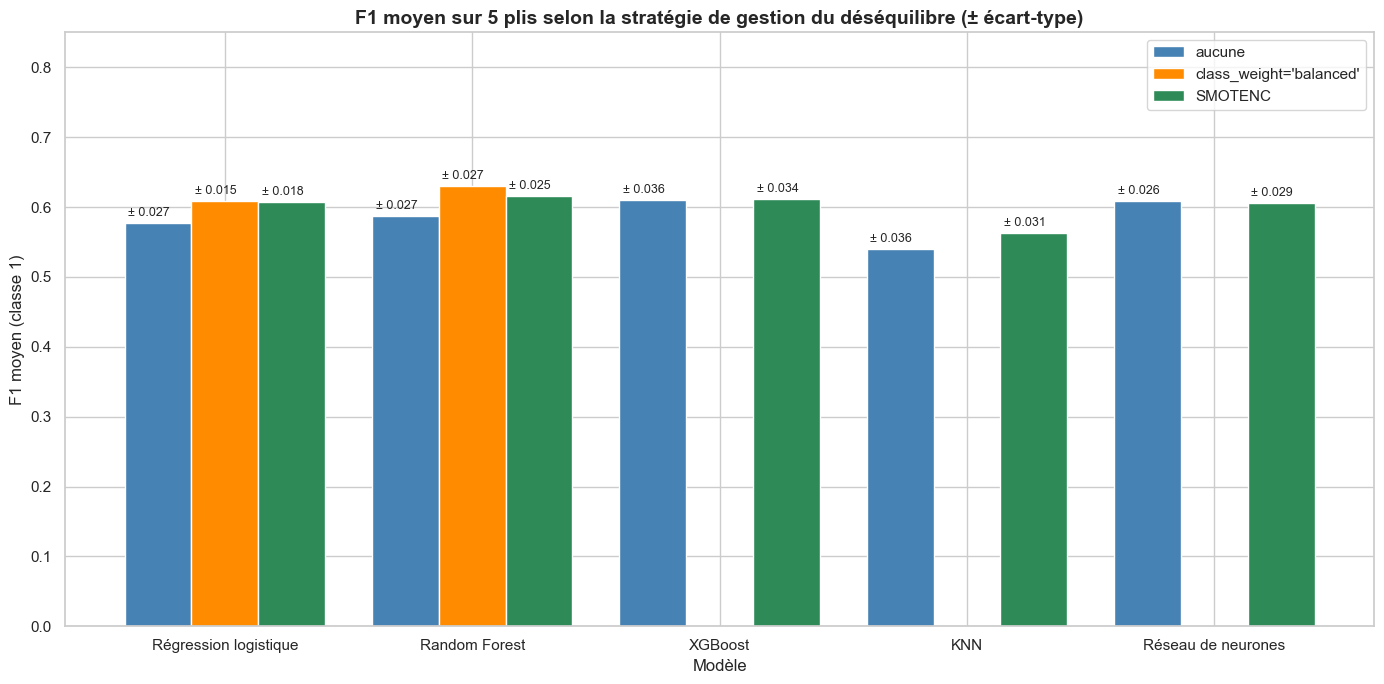

In [28]:
# CELL 28: Visualisation des stratégies de gestion du déséquilibre

# Une barre par option, décalée de la largeur d'une barre ; pas de barre class_weight='balanced'
# pour XGBoost, KNN et le réseau de neurones (option non testée)
plt.figure(figsize=(14, 7))
barres_option(table_recap_deseq, 'aucune', -largeur, 'steelblue')
barres_option(table_recap_deseq, "class_weight='balanced'", 0, 'darkorange')
barres_option(table_recap_deseq, 'SMOTENC', largeur, 'seagreen')
plt.title("F1 moyen sur 5 plis selon la stratégie de gestion du déséquilibre (± écart-type)",
          fontsize=14, fontweight='bold')
plt.xlabel("Modèle")
plt.ylabel("F1 moyen (classe 1)")
plt.xticks(positions, modeles)
plt.ylim(0, 0.85)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape3_02_desequilibre.png', dpi=150)
print("Figure sauvegardée: figures/etape3_02_desequilibre.png")
plt.show()

In [29]:
# CELL 29: Grilles d'hyperparamètres des 3 meilleurs modèles

# Random Forest avec class_weight='balanced', XGBoost avec SMOTENC, réseau de neurones sans correction
# (options retenues à l'étape précédente) ; régression logistique et KNN ne sont pas optimisés
grille_rf = {'n_estimators': [100, 200, 300], 'max_depth': [10, 20, 30]}
# Grille étendue : la meilleure combinaison de la première grille se trouvait sur son bord (300 arbres, profondeur 9).
grille_xgb = {'n_estimators': [100, 300, 500], 'learning_rate': [0.05, 0.1, 0.3], 'max_depth': [3, 6, 9, 12]}
grille_reseau = {'couches': [(64, 32), (128, 64)], 'dropout': [0, 0.2]}

# Combinaisons dans l'ordre de la grille : texte affiché et paramètres
combinaisons_rf = []
for n_estimators in grille_rf['n_estimators']:
    for max_depth in grille_rf['max_depth']:
        combinaisons_rf.append({'texte': f"n_estimators={n_estimators}, max_depth={max_depth}",
                                'parametres': {'n_estimators': n_estimators, 'max_depth': max_depth}})
couples_xgb = []
for n_estimators in grille_xgb['n_estimators']:
    for learning_rate in grille_xgb['learning_rate']:
        couples_xgb.append([n_estimators, learning_rate])
combinaisons_xgb = []
for couple in couples_xgb:
    for max_depth in grille_xgb['max_depth']:
        combinaisons_xgb.append({'texte': f"n_estimators={couple[0]}, learning_rate={couple[1]}, max_depth={max_depth}",
                                 'parametres': {'n_estimators': couple[0], 'learning_rate': couple[1], 'max_depth': max_depth}})
combinaisons_reseau = []
for couches in grille_reseau['couches']:
    for taux in grille_reseau['dropout']:
        combinaisons_reseau.append({'texte': f"couches={couches}, dropout={taux}",
                                    'parametres': {'couches': couches, 'dropout': taux}})

In [30]:
# CELL 30: Données SMOTENC des plis réutilisées pour XGBoost

# Données non mises à l'échelle rééchantillonnées par SMOTENC en CELL 18 (partie entraînement de chaque pli)
for k in range(len(plis)):
    d = donnees_plis[k]
    print(f"Pli {k + 1} | SMOTENC ({d['duree_smote_a']:.2f} s): entraînement {len(d['y_tr'])} -> {len(d['ya_tr_sm'])} lignes, "
          f"y = 1: {d['y_tr'].mean() * 100:.2f}% -> {d['ya_tr_sm'].mean() * 100:.2f}%")

Pli 1 | SMOTENC (0.07 s): entraînement 4417 -> 7092 lignes, y = 1: 19.72% -> 50.00%
Pli 2 | SMOTENC (1.16 s): entraînement 25917 -> 40588 lignes, y = 1: 21.70% -> 50.00%
Pli 3 | SMOTENC (3.94 s): entraînement 47276 -> 72462 lignes, y = 1: 23.36% -> 50.00%
Pli 4 | SMOTENC (7.86 s): entraînement 68724 -> 105754 lignes, y = 1: 23.06% -> 50.00%
Pli 5 | SMOTENC (14.25 s): entraînement 91360 -> 140998 lignes, y = 1: 22.83% -> 50.00%


In [31]:
# CELL 31: Fonction d'enregistrement des résultats d'une grille

def enregistrer_grille(nom, combinaisons, scores, durees):
    # Une ligne par combinaison : F1 moyen et écart-type sur les 5 plis (colonne de scores), temps moyen (colonne de durees)
    lignes = []
    for c in combinaisons:
        lignes.append({
            'Modèle': nom,
            'Combinaison': c['texte'],
            'Paramètres': c['parametres'],
            'F1 moyen': scores[c['texte']].mean(),
            'Écart-type F1': scores[c['texte']].std(),
            'Temps entraînement moyen (s)': durees[c['texte']].mean()
        })
        print(f"{nom} | {c['texte']} | F1 moyen = {scores[c['texte']].mean():.4f} | "
              f"écart-type = {scores[c['texte']].std():.4f} | entraînement {durees[c['texte']].mean():.2f} s")
    return lignes

In [32]:
# CELL 32: Recherche des hyperparamètres : Random Forest (class_weight='balanced', données non mises à l'échelle)

# F1 et durée de chaque pli : une colonne par combinaison
f1_par_combinaison = {}
durees_par_combinaison = {}
for c in combinaisons_rf:
    f1_par_combinaison[c['texte']] = []
    durees_par_combinaison[c['texte']] = []
    for k in range(len(plis)):
        d = donnees_plis[k]
        modele = RandomForestClassifier(n_estimators=c['parametres']['n_estimators'], max_depth=c['parametres']['max_depth'],
                                        class_weight='balanced', random_state=42, n_jobs=-1)
        debut = time()
        modele.fit(d['Xa_tr'], d['y_tr'])
        durees_par_combinaison[c['texte']].append(time() - debut)
        f1_par_combinaison[c['texte']].append(f1_score(d['y_va'], modele.predict(d['Xa_va'])))
scores_rf = pd.DataFrame(f1_par_combinaison)
durees_rf = pd.DataFrame(durees_par_combinaison)
lignes_rf = enregistrer_grille('Random Forest', combinaisons_rf, scores_rf, durees_rf)

Random Forest | n_estimators=100, max_depth=10 | F1 moyen = 0.6251 | écart-type = 0.0202 | entraînement 0.87 s
Random Forest | n_estimators=100, max_depth=20 | F1 moyen = 0.6310 | écart-type = 0.0273 | entraînement 1.21 s
Random Forest | n_estimators=100, max_depth=30 | F1 moyen = 0.6297 | écart-type = 0.0266 | entraînement 1.18 s
Random Forest | n_estimators=200, max_depth=10 | F1 moyen = 0.6258 | écart-type = 0.0206 | entraînement 1.58 s
Random Forest | n_estimators=200, max_depth=20 | F1 moyen = 0.6331 | écart-type = 0.0270 | entraînement 2.70 s
Random Forest | n_estimators=200, max_depth=30 | F1 moyen = 0.6304 | écart-type = 0.0257 | entraînement 2.59 s
Random Forest | n_estimators=300, max_depth=10 | F1 moyen = 0.6265 | écart-type = 0.0202 | entraînement 2.59 s
Random Forest | n_estimators=300, max_depth=20 | F1 moyen = 0.6330 | écart-type = 0.0273 | entraînement 3.25 s
Random Forest | n_estimators=300, max_depth=30 | F1 moyen = 0.6310 | écart-type = 0.0269 | entraînement 3.18 s


In [33]:
# CELL 33: Recherche des hyperparamètres : XGBoost (SMOTENC, données non mises à l'échelle)

# F1 et durée de chaque pli : une colonne par combinaison ; données SMOTENC de CELL 18
f1_par_combinaison = {}
durees_par_combinaison = {}
for c in combinaisons_xgb:
    f1_par_combinaison[c['texte']] = []
    durees_par_combinaison[c['texte']] = []
    for k in range(len(plis)):
        d = donnees_plis[k]
        modele = XGBClassifier(n_estimators=c['parametres']['n_estimators'], learning_rate=c['parametres']['learning_rate'],
                               max_depth=c['parametres']['max_depth'], random_state=42, n_jobs=-1)
        debut = time()
        modele.fit(d['Xa_tr_sm'], d['ya_tr_sm'])
        durees_par_combinaison[c['texte']].append(time() - debut)
        f1_par_combinaison[c['texte']].append(f1_score(d['y_va'], modele.predict(d['Xa_va'])))
scores_xgb = pd.DataFrame(f1_par_combinaison)
durees_xgb = pd.DataFrame(durees_par_combinaison)
print()
lignes_xgb = enregistrer_grille('XGBoost', combinaisons_xgb, scores_xgb, durees_xgb)


XGBoost | n_estimators=100, learning_rate=0.05, max_depth=3 | F1 moyen = 0.6040 | écart-type = 0.0250 | entraînement 0.32 s
XGBoost | n_estimators=100, learning_rate=0.05, max_depth=6 | F1 moyen = 0.6141 | écart-type = 0.0254 | entraînement 0.57 s
XGBoost | n_estimators=100, learning_rate=0.05, max_depth=9 | F1 moyen = 0.6132 | écart-type = 0.0290 | entraînement 1.43 s
XGBoost | n_estimators=100, learning_rate=0.05, max_depth=12 | F1 moyen = 0.6130 | écart-type = 0.0281 | entraînement 3.18 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=3 | F1 moyen = 0.6106 | écart-type = 0.0263 | entraînement 0.35 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=6 | F1 moyen = 0.6165 | écart-type = 0.0297 | entraînement 0.58 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=9 | F1 moyen = 0.6187 | écart-type = 0.0292 | entraînement 1.16 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=12 | F1 moyen = 0.6148 | écart-type = 0.0278 | entraînement 2.53 s
XGBoost |

In [34]:
# CELL 34: Recherche des hyperparamètres : réseau de neurones (sans correction, données mises à l'échelle)

# F1 et durée de chaque pli : une colonne par combinaison (même réseau qu'en CELL 14, tailles de couches
# et taux de Dropout de la combinaison)
f1_par_combinaison = {}
durees_par_combinaison = {}
for c in combinaisons_reseau:
    f1_par_combinaison[c['texte']] = []
    durees_par_combinaison[c['texte']] = []
    for k in range(len(plis)):
        d = donnees_plis[k]
        reseau, duree_fit = entrainer_reseau(d['Xs_tr'].values, d['y_tr'].values, c['parametres'])
        pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
        durees_par_combinaison[c['texte']].append(duree_fit)
        f1_par_combinaison[c['texte']].append(f1_score(d['y_va'], pred))
scores_reseau = pd.DataFrame(f1_par_combinaison)
durees_reseau = pd.DataFrame(durees_par_combinaison)
print()
lignes_reseau = enregistrer_grille('Réseau de neurones', combinaisons_reseau, scores_reseau, durees_reseau)

table_grille = pd.DataFrame(lignes_rf + lignes_xgb + lignes_reseau)


Réseau de neurones | couches=(64, 32), dropout=0 | F1 moyen = 0.6092 | écart-type = 0.0258 | entraînement 20.94 s
Réseau de neurones | couches=(64, 32), dropout=0.2 | F1 moyen = 0.5882 | écart-type = 0.0360 | entraînement 33.29 s
Réseau de neurones | couches=(128, 64), dropout=0 | F1 moyen = 0.6108 | écart-type = 0.0226 | entraînement 16.78 s
Réseau de neurones | couches=(128, 64), dropout=0.2 | F1 moyen = 0.5987 | écart-type = 0.0313 | entraînement 25.25 s


In [35]:
# CELL 35: Paramètres par défaut, paramètres des modèles non optimisés et F1 de l'étape précédente

# Paramètres par défaut (ceux de CELL 10 à CELL 14) : valeurs par défaut de scikit-learn, de XGBoost
# et réseau de CELL 9
parametres_defaut = {
    'Régression logistique': {'max_iter': 1000},
    'Random Forest': {'n_estimators': 100, 'max_depth': None},
    'XGBoost': {'n_estimators': 100, 'learning_rate': 0.3, 'max_depth': 6},
    'KNN': {'n_neighbors': 5},
    'Réseau de neurones': {'couches': (64, 32), 'dropout': 0}
}

# Régression logistique et KNN ne sont pas optimisés : paramètres par défaut
parametres_retenus = {
    'Régression logistique': parametres_defaut['Régression logistique'],
    'KNN': parametres_defaut['KNN']
}

# Tableaux de l'étape J+1 utilisés par les fonctions des grilles (CELL 36 et CELL 38)
etape_J1 = {'table_grille': table_grille, 'table_recap_deseq': table_recap_deseq,
            'strategie': strategie_retenue, 'parametres_retenus': parametres_retenus}


def f1_etape_precedente(etape, nom):
    # F1 moyen de l'étape précédente : paramètres par défaut avec l'option de déséquilibre retenue
    masque = (etape['table_recap_deseq']['Modèle'] == nom) & (etape['table_recap_deseq']['Option'] == etape['strategie'][nom])
    return etape['table_recap_deseq'][masque]['F1 moyen'].values[0]

In [36]:
# CELL 36: Fonctions du récapitulatif et de la règle de décision d'une grille

# Règle de décision : pour chaque modèle, on retient la combinaison qui a le F1 moyen le plus élevé sur les
# 5 plis (valeurs non arrondies) ; si aucune combinaison ne dépasse le F1 moyen des paramètres par défaut
# avec l'option de l'étape précédente (valeurs de CELL 24), on garde les paramètres par défaut


def afficher_grille(etape, nom):
    # Combinaisons triées par F1 moyen décroissant (pleine précision pour le F1 moyen, 4 décimales ailleurs)
    r = etape['table_grille'][etape['table_grille']['Modèle'] == nom].sort_values('F1 moyen', ascending=False).reset_index()
    r = r.drop(columns=['index'])
    table_affichage_grille = r[['Combinaison', 'F1 moyen', 'Écart-type F1', 'Temps entraînement moyen (s)']].copy()
    f1_texte = []
    ecarts_arrondis = []
    temps_arrondis = []
    for i in range(len(r)):
        f1_texte.append(str(r['F1 moyen'].values[i]))
        ecarts_arrondis.append(round(r['Écart-type F1'].values[i], 4))
        temps_arrondis.append(round(r['Temps entraînement moyen (s)'].values[i], 4))
    table_affichage_grille['F1 moyen'] = f1_texte
    table_affichage_grille['Écart-type F1'] = ecarts_arrondis
    table_affichage_grille['Temps entraînement moyen (s)'] = temps_arrondis
    print(f"{nom} ({etape['strategie'][nom]}), combinaisons triées par F1 moyen décroissant:")
    print(table_affichage_grille)
    return r


def retenir_combinaison(etape, nom, r):
    # Meilleure combinaison retenue si son F1 moyen dépasse celui de l'étape précédente, sinon paramètres par défaut
    f1_etape2 = f1_etape_precedente(etape, nom)
    f1_meilleur = r['F1 moyen'].values[0]
    if f1_meilleur > f1_etape2:
        etape['parametres_retenus'][nom] = r['Paramètres'].values[0]
        print(f"\n  Combinaison retenue: {r['Combinaison'].values[0]}")
    else:
        etape['parametres_retenus'][nom] = parametres_defaut[nom]
        print(f"\n  Aucune combinaison ne dépasse les paramètres par défaut: paramètres par défaut conservés")
    print(f"  F1 moyen de la meilleure combinaison = {f1_meilleur}")
    print(f"  F1 moyen de l'étape précédente       = {f1_etape2}")
    print(f"  Différence                           = {f1_meilleur - f1_etape2:+.4f}\n")

In [37]:
# CELL 37: Récapitulatif et règle de décision des 3 grilles

r = afficher_grille(etape_J1, 'Random Forest')
retenir_combinaison(etape_J1, 'Random Forest', r)
r = afficher_grille(etape_J1, 'XGBoost')
retenir_combinaison(etape_J1, 'XGBoost', r)
r = afficher_grille(etape_J1, 'Réseau de neurones')
retenir_combinaison(etape_J1, 'Réseau de neurones', r)

print("parametres_retenus:")
for nom in modeles:
    print(f"  {nom}: {parametres_retenus[nom]}")

Random Forest (class_weight='balanced'), combinaisons triées par F1 moyen décroissant:
                      Combinaison            F1 moyen  Écart-type F1  Temps entraînement moyen (s)
0  n_estimators=200, max_depth=20  0.6331325881138113         0.0270                        2.6955
1  n_estimators=300, max_depth=20  0.6329840202348429         0.0273                        3.2487
2  n_estimators=100, max_depth=20  0.6309932410015302         0.0273                        1.2084
3  n_estimators=300, max_depth=30   0.630971972303511         0.0269                        3.1754
4  n_estimators=200, max_depth=30  0.6303779838471264         0.0257                        2.5925
5  n_estimators=100, max_depth=30  0.6297352951945923         0.0266                        1.1803
6  n_estimators=300, max_depth=10  0.6264981285225114         0.0202                        2.5947
7  n_estimators=200, max_depth=10  0.6258471416412641         0.0206                        1.5751
8  n_estimators=100, m

In [38]:
# CELL 38: Fonction de tracé du panneau d'une grille

def panneau_grille(etape, position, nom, titre_axe):
    # F1 moyen de chaque combinaison : points reliés, ordre de la grille de haut en bas, axe du F1 resserré ;
    # combinaison retenue marquée d'une étoile ; F1 moyen de l'étape précédente en ligne verticale de référence
    r = etape['table_grille'][etape['table_grille']['Modèle'] == nom]
    etiquettes = []
    positions_y = []
    for i in range(len(r)):
        valeurs = []
        for cle in r['Paramètres'].values[i]:
            valeurs.append(str(r['Paramètres'].values[i][cle]))
        etiquettes.append(' / '.join(valeurs))
        positions_y.append(len(r) - 1 - i)
    f1_etape2 = f1_etape_precedente(etape, nom)
    plt.subplot(1, 3, position)
    plt.plot(r['F1 moyen'].values, positions_y, marker='o', linewidth=1, color='steelblue', label="Combinaisons de la grille")
    for i in range(len(r)):
        if r['Paramètres'].values[i] == etape['parametres_retenus'][nom]:
            plt.scatter([r['F1 moyen'].values[i]], [positions_y[i]], color='orange', s=250, marker='*',
                        label="Combinaison retenue")
    plt.plot([f1_etape2, f1_etape2], [-0.5, len(r) - 0.5], color='red', linestyle='--',
             label=f"Paramètres par défaut, {etape['strategie'][nom]} (F1 = {f1_etape2:.4f})")
    plt.xlim(min(r['F1 moyen'].min(), f1_etape2) - 0.005, max(r['F1 moyen'].max(), f1_etape2) + 0.005)
    plt.yticks(positions_y, etiquettes)
    plt.title(nom, fontsize=13, fontweight='bold')
    plt.xlabel("F1 moyen sur 5 plis (classe 1)")
    plt.ylabel(titre_axe)
    plt.legend()

Figure sauvegardée: figures/etape3_03_hyperparametres.png


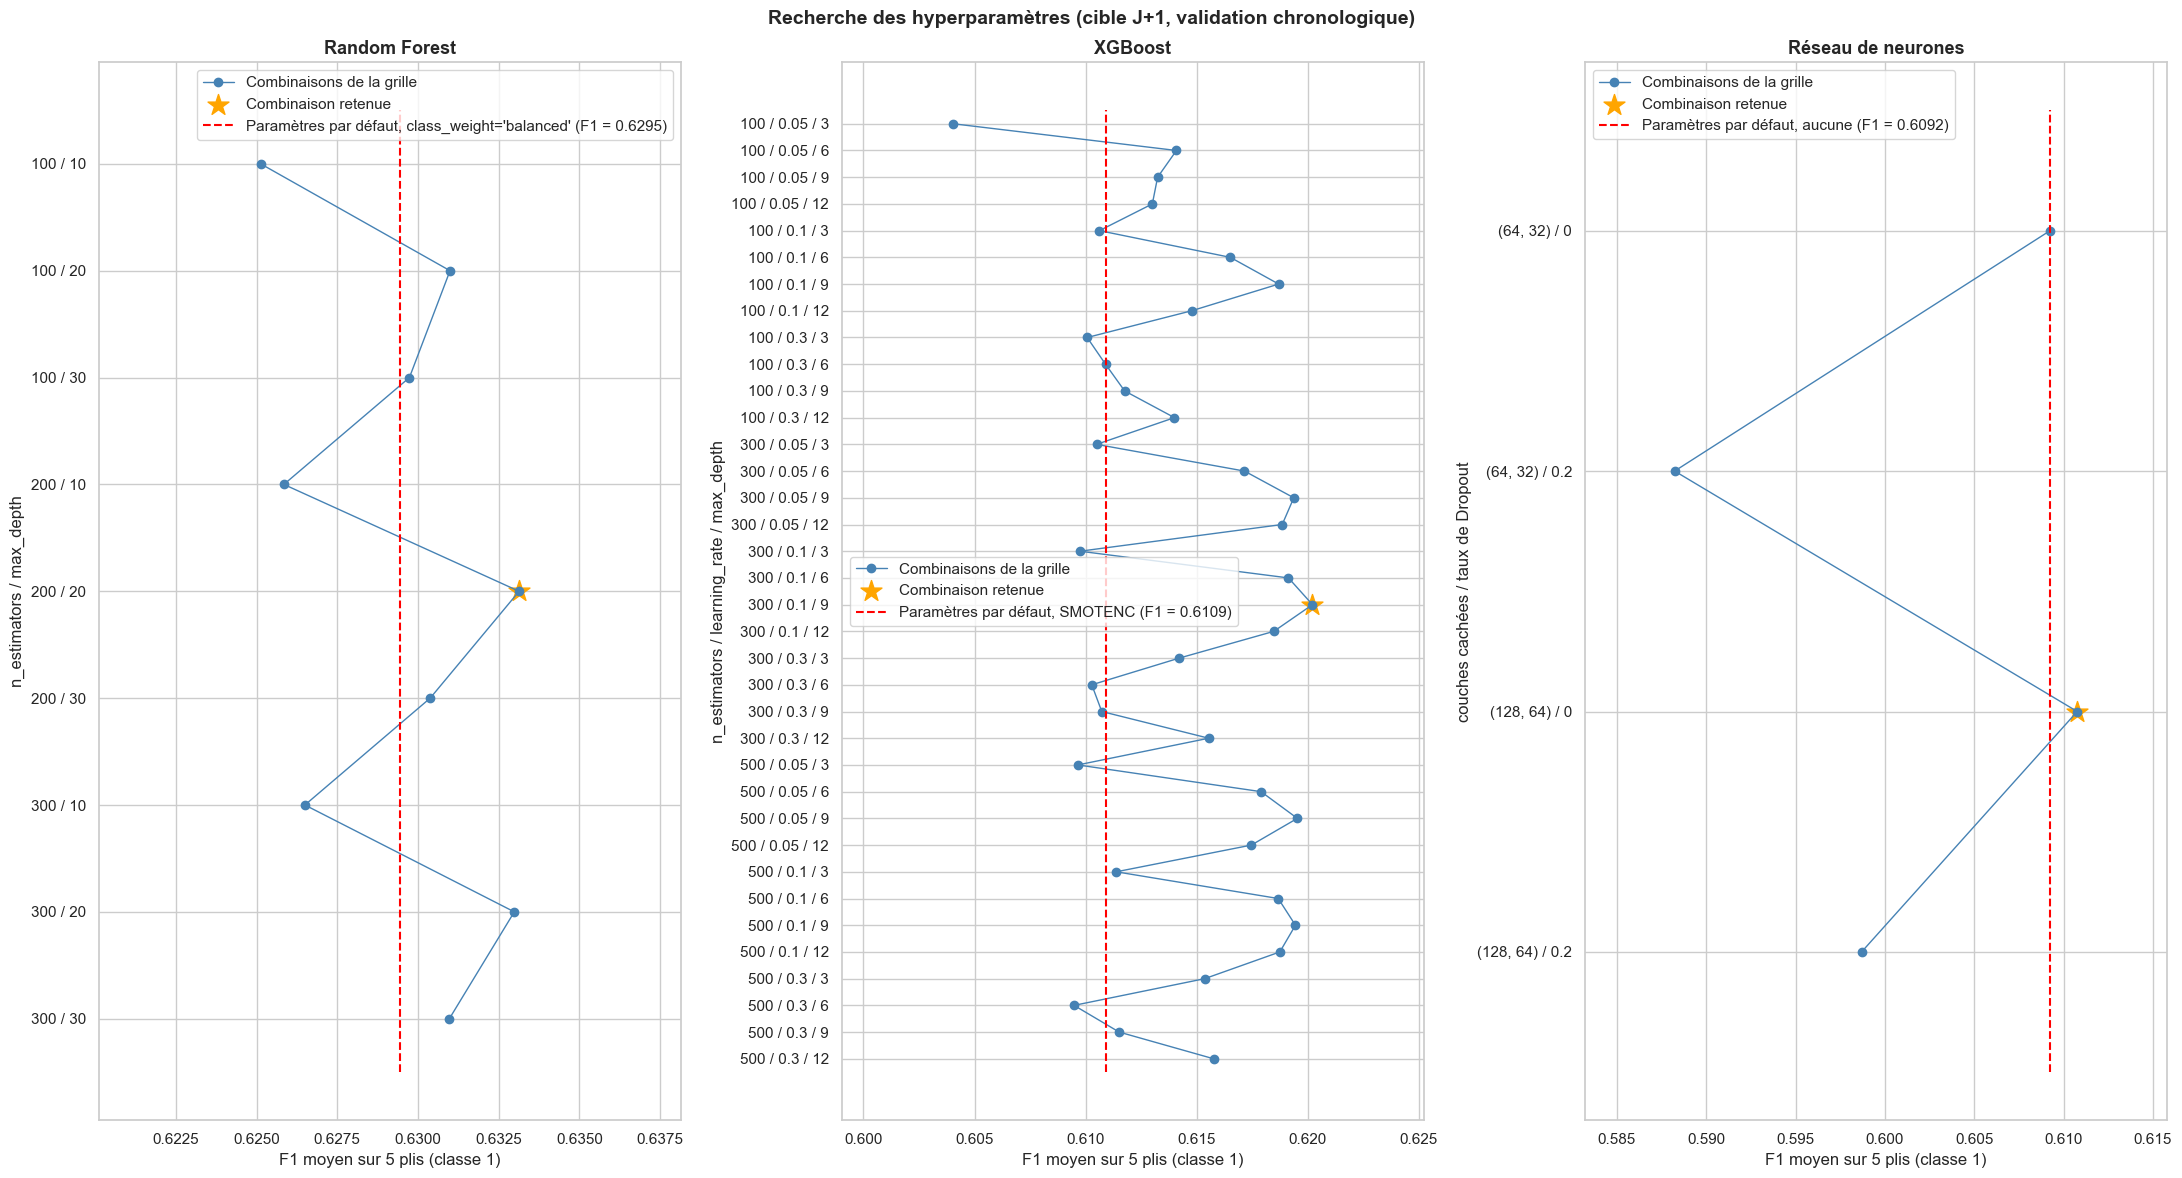

In [39]:
# CELL 39: Visualisation de la recherche des hyperparamètres

plt.figure(figsize=(22, 12))
panneau_grille(etape_J1, 1, 'Random Forest', 'n_estimators / max_depth')
panneau_grille(etape_J1, 2, 'XGBoost', 'n_estimators / learning_rate / max_depth')
panneau_grille(etape_J1, 3, 'Réseau de neurones', 'couches cachées / taux de Dropout')
plt.suptitle("Recherche des hyperparamètres (cible J+1, validation chronologique)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_03_hyperparametres.png', dpi=150)
print("Figure sauvegardée: figures/etape3_03_hyperparametres.png")
plt.show()

In [40]:
# CELL 40: Fonctions de choix des données et de la pondération selon l'option de déséquilibre

def donnees_selon_option(d, option, mise_a_echelle):
    # Données d'entraînement (mises à l'échelle ou non), rééchantillonnées par SMOTENC si c'est l'option retenue
    if mise_a_echelle:
        X_tr, X_sm, y_sm = d['Xs_tr'], d['Xs_tr_sm'], d['ys_tr_sm']
    else:
        X_tr, X_sm, y_sm = d['Xa_tr'], d['Xa_tr_sm'], d['ya_tr_sm']
    if option == 'SMOTENC':
        return X_sm, y_sm
    return X_tr, d['y_tr']


def poids_selon_option(option):
    # Pondération des classes seulement pour l'option class_weight='balanced'
    if option == "class_weight='balanced'":
        return 'balanced'
    return None

In [41]:
# CELL 41: Probabilités de validation : régression logistique (paramètres et option retenus)

# Pour chaque modèle (paramètres retenus en CELL 37, option de déséquilibre retenue en CELL 26)
# et chaque pli : probabilité de la classe 1 sur la partie validation, conservée pour le récapitulatif et la figure
probas_plis = {}
p = parametres_retenus['Régression logistique']
option = strategie_retenue['Régression logistique']
probas_plis['Régression logistique'] = []
for k in range(len(plis)):
    X_fit, y_fit = donnees_selon_option(donnees_plis[k], option, True)
    modele = LogisticRegression(max_iter=p['max_iter'], class_weight=poids_selon_option(option))
    modele.fit(X_fit, y_fit)
    probas_plis['Régression logistique'].append(modele.predict_proba(donnees_plis[k]['Xs_va'])[:, 1])

In [42]:
# CELL 42: Probabilités de validation : Random Forest (paramètres et option retenus)

p = parametres_retenus['Random Forest']
option = strategie_retenue['Random Forest']
probas_plis['Random Forest'] = []
for k in range(len(plis)):
    X_fit, y_fit = donnees_selon_option(donnees_plis[k], option, False)
    modele = RandomForestClassifier(n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                                    class_weight=poids_selon_option(option), random_state=42, n_jobs=-1)
    modele.fit(X_fit, y_fit)
    probas_plis['Random Forest'].append(modele.predict_proba(donnees_plis[k]['Xa_va'])[:, 1])

In [43]:
# CELL 43: Probabilités de validation : XGBoost (paramètres et option retenus)

p = parametres_retenus['XGBoost']
option = strategie_retenue['XGBoost']
probas_plis['XGBoost'] = []
for k in range(len(plis)):
    X_fit, y_fit = donnees_selon_option(donnees_plis[k], option, False)
    modele = XGBClassifier(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                           max_depth=p['max_depth'], random_state=42, n_jobs=-1)
    modele.fit(X_fit, y_fit)
    probas_plis['XGBoost'].append(modele.predict_proba(donnees_plis[k]['Xa_va'])[:, 1])

In [44]:
# CELL 44: Probabilités de validation : KNN (paramètres et option retenus)

p = parametres_retenus['KNN']
option = strategie_retenue['KNN']
probas_plis['KNN'] = []
for k in range(len(plis)):
    X_fit, y_fit = donnees_selon_option(donnees_plis[k], option, True)
    modele = KNeighborsClassifier(n_neighbors=p['n_neighbors'], n_jobs=-1)
    modele.fit(X_fit, y_fit)
    probas_plis['KNN'].append(modele.predict_proba(donnees_plis[k]['Xs_va'])[:, 1])

In [45]:
# CELL 45: Probabilités de validation : réseau de neurones (paramètres et option retenus)

p = parametres_retenus['Réseau de neurones']
option = strategie_retenue['Réseau de neurones']
probas_plis['Réseau de neurones'] = []
for k in range(len(plis)):
    X_fit, y_fit = donnees_selon_option(donnees_plis[k], option, True)
    if option == 'SMOTENC':
        # Même mélange qu'en CELL 23 : la validation interne ne doit pas contenir que des exemples synthétiques
        X_fit = X_fit.sample(frac=1, random_state=42)
        y_fit = y_fit.loc[X_fit.index]
    reseau, duree_fit = entrainer_reseau(X_fit.values, y_fit.values, p)
    pred, proba_1, duree_pred = predire_reseau(reseau, donnees_plis[k]['Xs_va'].values)
    probas_plis['Réseau de neurones'].append(proba_1)
    print(f"Pli {k + 1}: probabilités de la classe 1 calculées pour les 5 modèles")

Pli 1: probabilités de la classe 1 calculées pour les 5 modèles


Pli 2: probabilités de la classe 1 calculées pour les 5 modèles


Pli 3: probabilités de la classe 1 calculées pour les 5 modèles


Pli 4: probabilités de la classe 1 calculées pour les 5 modèles


Pli 5: probabilités de la classe 1 calculées pour les 5 modèles


In [46]:
# CELL 46: Fonctions des scores à un seuil de probabilité

def scores_au_seuil(proba_1, y_va, seuil):
    # F1, précision et rappel de la classe 1 pour la prédiction (probabilité >= seuil)
    pred = (proba_1 >= seuil).astype(int)
    # Aucune prédiction positive : précision fixée à 0 par définition (même règle que le modèle naïf, CELL 7)
    if pred.sum() == 0:
        precision = 0.0
    else:
        precision = precision_score(y_va, pred)
    return f1_score(y_va, pred), precision, recall_score(y_va, pred)


def scores_moyens(probas, y_plis, seuil):
    # F1, précision et rappel moyens sur les plis de validation au seuil donné
    # (probas : probabilités de la classe 1 d'un modèle sur chaque pli, y_plis : cibles de chaque pli)
    f1_plis = []
    precision_plis = []
    rappel_plis = []
    for k in range(len(probas)):
        f1, precision, rappel = scores_au_seuil(probas[k], y_plis[k], seuil)
        f1_plis.append(f1)
        precision_plis.append(precision)
        rappel_plis.append(rappel)
    return np.mean(f1_plis), np.mean(precision_plis), np.mean(rappel_plis)

In [47]:
# CELL 47: Optimisation du seuil de probabilité (validation croisée chronologique)

# F1, précision et rappel moyens sur les 5 plis pour chaque seuil ; seuil retenu : celui qui maximise le F1 moyen
seuils = np.arange(0, 1, 0.001)
courbes_seuils = {}
resultats_seuils = []
for nom in modeles:
    f1_moyens = []
    precisions_moyennes = []
    rappels_moyens = []
    for seuil in seuils:
        f1, precision, rappel = scores_moyens(probas_plis[nom], y_va_plis, seuil)
        f1_moyens.append(f1)
        precisions_moyennes.append(precision)
        rappels_moyens.append(rappel)
    courbes_seuils[nom] = {'F1': f1_moyens, 'Précision': precisions_moyennes, 'Rappel': rappels_moyens}
    i_max = np.argmax(f1_moyens)
    # Scores moyens au seuil par défaut 0,5
    f1_05, precision_05, rappel_05 = scores_moyens(probas_plis[nom], y_va_plis, 0.5)
    resultats_seuils.append({
        'Modèle': nom,
        'Seuil retenu': round(seuils[i_max], 3),
        'F1 moyen (seuil retenu)': f1_moyens[i_max],
        'F1 moyen (seuil 0,5)': f1_05,
        'Précision moyenne (seuil retenu)': precisions_moyennes[i_max],
        'Rappel moyen (seuil retenu)': rappels_moyens[i_max],
        'Précision moyenne (seuil 0,5)': precision_05,
        'Rappel moyen (seuil 0,5)': rappel_05
    })
    print(f"{nom} | seuil retenu = {seuils[i_max]:.3f} | F1 moyen = {f1_moyens[i_max]:.4f} (seuil 0,5: {f1_05:.4f})")

Régression logistique | seuil retenu = 0.594 | F1 moyen = 0.6217 (seuil 0,5: 0.6088)


Random Forest | seuil retenu = 0.438 | F1 moyen = 0.6381 (seuil 0,5: 0.6334)


XGBoost | seuil retenu = 0.302 | F1 moyen = 0.6450 (seuil 0,5: 0.6202)


KNN | seuil retenu = 0.401 | F1 moyen = 0.5625 (seuil 0,5: 0.5625)


Réseau de neurones | seuil retenu = 0.306 | F1 moyen = 0.6442 (seuil 0,5: 0.6108)


In [48]:
# CELL 48: Récapitulatif des seuils

table_seuils = pd.DataFrame(resultats_seuils)
table_seuils['Différence F1'] = table_seuils['F1 moyen (seuil retenu)'] - table_seuils['F1 moyen (seuil 0,5)']
table_seuils = table_seuils[['Modèle', 'Seuil retenu', 'F1 moyen (seuil retenu)', 'F1 moyen (seuil 0,5)', 'Différence F1',
                             'Précision moyenne (seuil retenu)', 'Rappel moyen (seuil retenu)',
                             'Précision moyenne (seuil 0,5)', 'Rappel moyen (seuil 0,5)']]

# Affichage : F1 moyen au seuil retenu en pleine précision, 4 décimales pour les autres colonnes
table_affichage_seuils = table_seuils.copy()
f1_texte = []
for v in table_seuils['F1 moyen (seuil retenu)'].values:
    f1_texte.append(str(v))
table_affichage_seuils['F1 moyen (seuil retenu)'] = f1_texte
for col in ['F1 moyen (seuil 0,5)', 'Différence F1', 'Précision moyenne (seuil retenu)', 'Rappel moyen (seuil retenu)',
            'Précision moyenne (seuil 0,5)', 'Rappel moyen (seuil 0,5)']:
    valeurs_arrondies = []
    for v in table_seuils[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_seuils[col] = valeurs_arrondies
print("Seuil de probabilité retenu par modèle (F1 moyen maximal sur les 5 plis de validation):")
print(table_affichage_seuils)

# Seuils retenus
seuil_retenu = {}
for i in range(len(table_seuils)):
    seuil_retenu[table_seuils['Modèle'].values[i]] = table_seuils['Seuil retenu'].values[i]
print(f"\nseuil_retenu = {seuil_retenu}")

Seuil de probabilité retenu par modèle (F1 moyen maximal sur les 5 plis de validation):
                  Modèle  Seuil retenu F1 moyen (seuil retenu)  F1 moyen (seuil 0,5)  Différence F1  Précision moyenne (seuil retenu)  Rappel moyen (seuil retenu)  Précision moyenne (seuil 0,5)  \
0  Régression logistique         0.594      0.6216882458298927                0.6088         0.0129                            0.5762                       0.6758                         0.5122   
1          Random Forest         0.438      0.6380597375409707                0.6334         0.0047                            0.5945                       0.6890                         0.6476   
2                XGBoost         0.302      0.6450024484049643                0.6202         0.0248                            0.6241                       0.6682                         0.7183   
3                    KNN         0.401      0.5624979708679176                0.5625         0.0000                         

Figure sauvegardée: figures/etape3_04_seuils.png


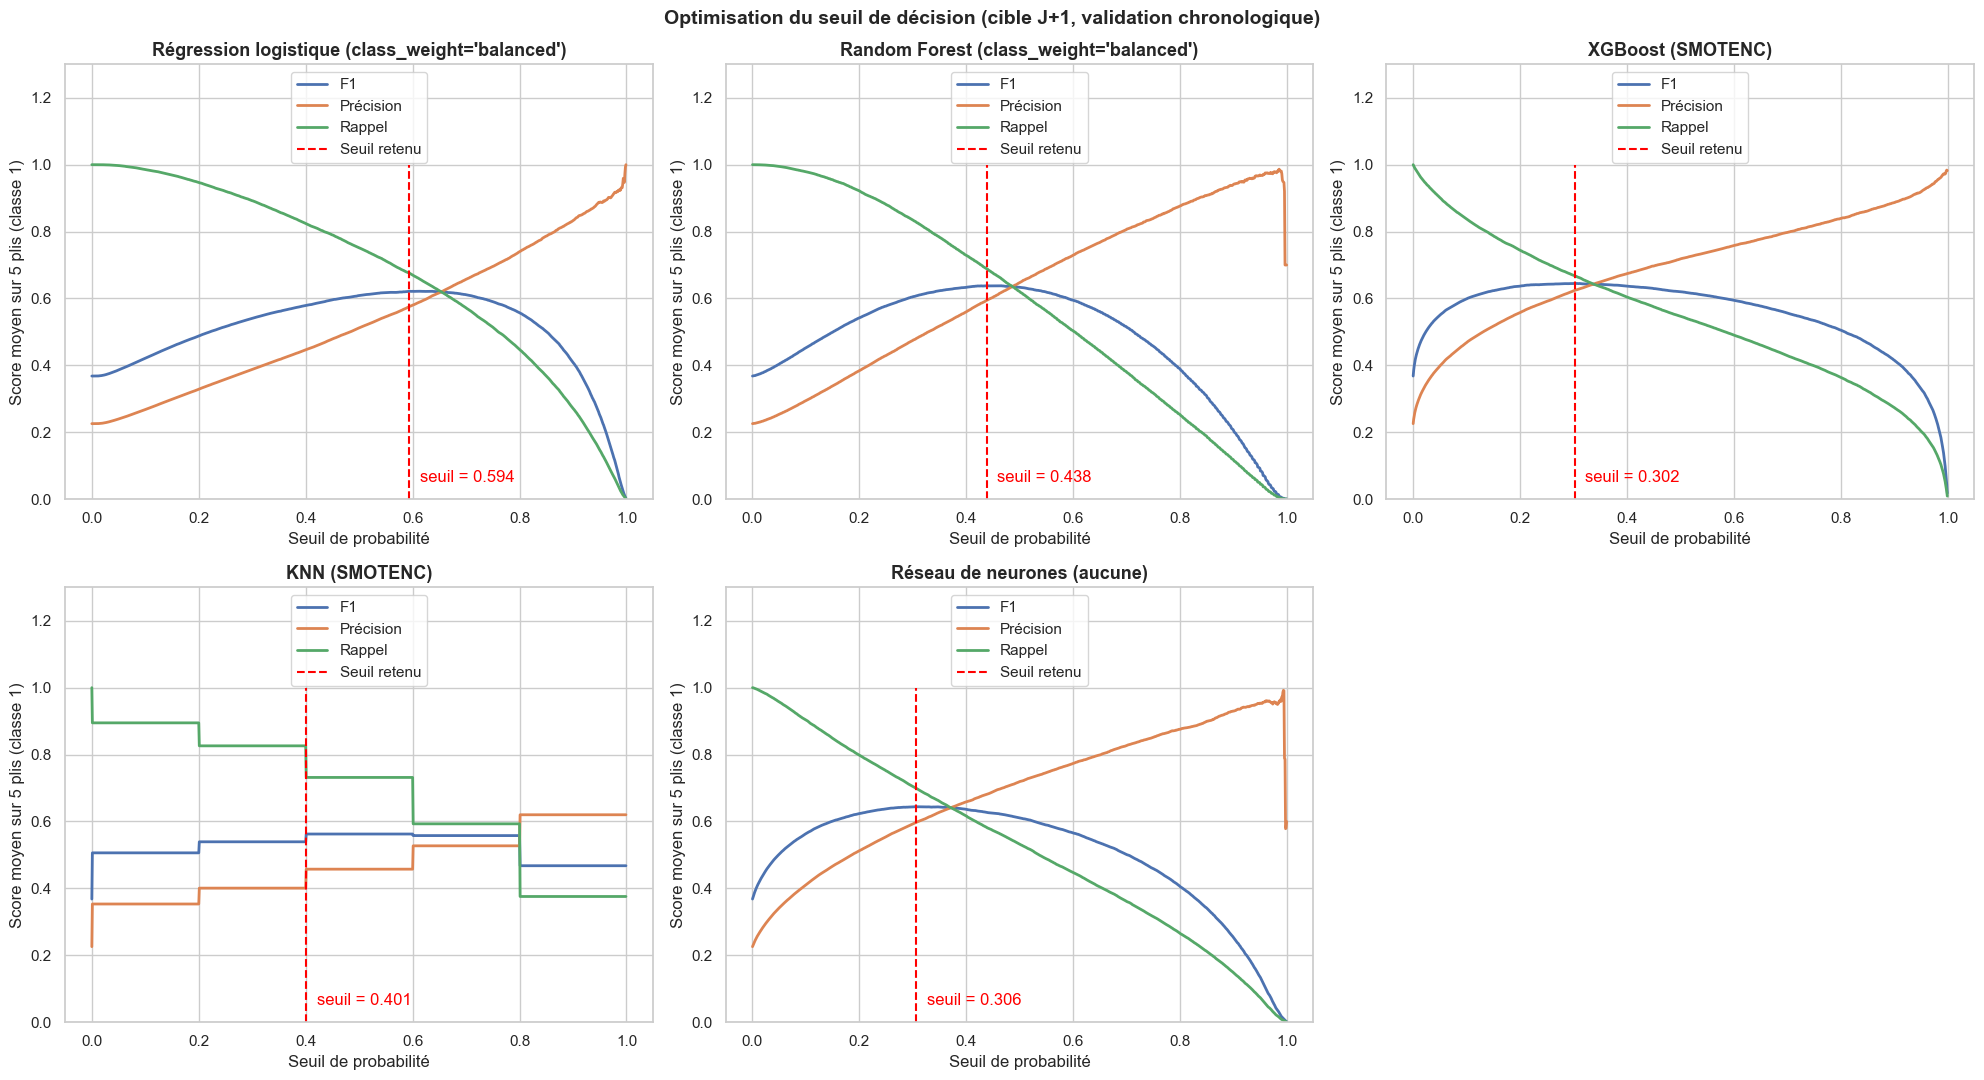

In [49]:
# CELL 49: Visualisation des seuils

# Un panneau par modèle : F1, précision et rappel moyens (5 plis) selon le seuil, seuil retenu en ligne verticale
plt.figure(figsize=(20, 11))
for i in range(len(modeles)):
    nom = modeles[i]
    s = seuil_retenu[nom]
    plt.subplot(2, 3, i + 1)
    plt.plot(seuils, courbes_seuils[nom]['F1'], linewidth=2, label="F1")
    plt.plot(seuils, courbes_seuils[nom]['Précision'], linewidth=2, label="Précision")
    plt.plot(seuils, courbes_seuils[nom]['Rappel'], linewidth=2, label="Rappel")
    plt.plot([s, s], [0, 1], color='red', linestyle='--', label="Seuil retenu")
    plt.text(s + 0.02, 0.05, f"seuil = {s:.3f}", color='red')
    plt.title(f"{nom} ({strategie_retenue[nom]})", fontsize=13, fontweight='bold')
    plt.xlabel("Seuil de probabilité")
    plt.ylabel("Score moyen sur 5 plis (classe 1)")
    # Marge au-dessus de 1 pour la légende, afin qu'elle ne couvre ni les courbes ni la valeur du seuil
    plt.ylim(0, 1.3)
    plt.legend(loc='upper center')

plt.suptitle("Optimisation du seuil de décision (cible J+1, validation chronologique)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_04_seuils.png', dpi=150)
print("Figure sauvegardée: figures/etape3_04_seuils.png")
plt.show()

In [50]:
# CELL 50: SMOTENC sur l'ensemble d'entraînement complet

# Location_encoded : celle des fichiers, calculée sur tout l'ensemble d'entraînement (correct ici)
# SMOTENC ajusté et appliqué sur l'ensemble d'entraînement complet uniquement (jamais sur le test),
# une fois pour les données mises à l'échelle, une fois pour les données non mises à l'échelle
smote_s = SMOTENC(categorical_features=[position_raintoday], random_state=42)
debut = time()
Xs_train_sm, ys_train_sm = smote_s.fit_resample(X_train_scaled, y_train)
duree_smote_s = time() - debut
smote_a = SMOTENC(categorical_features=[position_raintoday], random_state=42)
debut = time()
Xa_train_sm, ya_train_sm = smote_a.fit_resample(X_train_arbres, y_train)
duree_smote_a = time() - debut
print(f"SMOTENC sur l'entraînement complet: {duree_smote_s:.2f} s (mises à l'échelle), {duree_smote_a:.2f} s "
      f"(non mises à l'échelle) | {len(y_train)} -> {len(ys_train_sm)} lignes, y = 1: {y_train.mean() * 100:.2f}% -> "
      f"{ys_train_sm.mean() * 100:.2f}%\n")

# Mêmes clés que les données d'un pli, pour réutiliser donnees_selon_option (CELL 40)
donnees_completes = {'Xs_tr': X_train_scaled, 'Xa_tr': X_train_arbres, 'y_tr': y_train,
                     'Xs_tr_sm': Xs_train_sm, 'ys_tr_sm': ys_train_sm, 'Xa_tr_sm': Xa_train_sm, 'ya_tr_sm': ya_train_sm}

SMOTENC sur l'entraînement complet: 24.73 s (mises à l'échelle), 23.88 s (non mises à l'échelle) | 113748 -> 176440 lignes, y = 1: 22.44% -> 50.00%



In [51]:
# CELL 51: Entraînement final : régression logistique (ensemble d'entraînement complet)

modeles_finaux = {}
temps_entrainement_final = {}
p = parametres_retenus['Régression logistique']
option = strategie_retenue['Régression logistique']
X_fit, y_fit = donnees_selon_option(donnees_completes, option, True)
modele = LogisticRegression(max_iter=p['max_iter'], class_weight=poids_selon_option(option))
debut = time()
modele.fit(X_fit, y_fit)
duree_fit = time() - debut
modeles_finaux['Régression logistique'] = modele
temps_entrainement_final['Régression logistique'] = duree_fit
print(f"Régression logistique | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {duree_fit:.2f} s")

Régression logistique | paramètres: {'max_iter': 1000} | option: class_weight='balanced' | 113748 lignes d'entraînement | entraînement 0.60 s


In [52]:
# CELL 52: Entraînement final : Random Forest (ensemble d'entraînement complet)

p = parametres_retenus['Random Forest']
option = strategie_retenue['Random Forest']
X_fit, y_fit = donnees_selon_option(donnees_completes, option, False)
modele = RandomForestClassifier(n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                                class_weight=poids_selon_option(option), random_state=42, n_jobs=-1)
debut = time()
modele.fit(X_fit, y_fit)
duree_fit = time() - debut
modeles_finaux['Random Forest'] = modele
temps_entrainement_final['Random Forest'] = duree_fit
print(f"Random Forest | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {duree_fit:.2f} s")

Random Forest | paramètres: {'n_estimators': 200, 'max_depth': 20} | option: class_weight='balanced' | 113748 lignes d'entraînement | entraînement 5.95 s


In [53]:
# CELL 53: Entraînement final : XGBoost (ensemble d'entraînement complet)

p = parametres_retenus['XGBoost']
option = strategie_retenue['XGBoost']
X_fit, y_fit = donnees_selon_option(donnees_completes, option, False)
modele = XGBClassifier(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                       max_depth=p['max_depth'], random_state=42, n_jobs=-1)
debut = time()
modele.fit(X_fit, y_fit)
duree_fit = time() - debut
modeles_finaux['XGBoost'] = modele
temps_entrainement_final['XGBoost'] = duree_fit
print(f"XGBoost | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {duree_fit:.2f} s")

XGBoost | paramètres: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 9} | option: SMOTENC | 176440 lignes d'entraînement | entraînement 4.79 s


In [54]:
# CELL 54: Entraînement final : KNN (ensemble d'entraînement complet)

p = parametres_retenus['KNN']
option = strategie_retenue['KNN']
X_fit, y_fit = donnees_selon_option(donnees_completes, option, True)
modele = KNeighborsClassifier(n_neighbors=p['n_neighbors'], n_jobs=-1)
debut = time()
modele.fit(X_fit, y_fit)
duree_fit = time() - debut
modeles_finaux['KNN'] = modele
temps_entrainement_final['KNN'] = duree_fit
print(f"KNN | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {duree_fit:.2f} s")

KNN | paramètres: {'n_neighbors': 5} | option: SMOTENC | 176440 lignes d'entraînement | entraînement 0.05 s


In [55]:
# CELL 55: Entraînement final : réseau de neurones (ensemble d'entraînement complet)

p = parametres_retenus['Réseau de neurones']
option = strategie_retenue['Réseau de neurones']
X_fit, y_fit = donnees_selon_option(donnees_completes, option, True)
if option == 'SMOTENC':
    # Même mélange qu'en CELL 23 : la validation interne ne doit pas contenir que des exemples synthétiques
    X_fit = X_fit.sample(frac=1, random_state=42)
    y_fit = y_fit.loc[X_fit.index]
reseau, duree_fit = entrainer_reseau(X_fit.values, y_fit.values, p)
modeles_finaux['Réseau de neurones'] = reseau
temps_entrainement_final['Réseau de neurones'] = duree_fit
print(f"Réseau de neurones | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {duree_fit:.2f} s")

Réseau de neurones | paramètres: {'couches': (128, 64), 'dropout': 0} | option: aucune | 113748 lignes d'entraînement | entraînement 52.02 s


In [56]:
# CELL 56: Probabilités de la classe 1 sur l'ensemble de test

# Une seule évaluation sur le test, avec les modèles, options et seuils choisis sur les plis de validation
# (2e colonne de predict pour le réseau de neurones)
probas_test = {}
durees_prediction_test = {}
for nom in modeles:
    debut = time()
    if nom == 'Réseau de neurones':
        probas_test[nom] = modeles_finaux[nom].predict(X_test_scaled.values, verbose=0)[:, 1]
    elif nom == 'Random Forest' or nom == 'XGBoost':
        probas_test[nom] = modeles_finaux[nom].predict_proba(X_test_arbres)[:, 1]
    else:
        probas_test[nom] = modeles_finaux[nom].predict_proba(X_test_scaled)[:, 1]
    durees_prediction_test[nom] = time() - debut

In [57]:
# CELL 57: Évaluation unique sur l'ensemble de test (seuil retenu de chaque modèle)

from sklearn.metrics import classification_report, confusion_matrix

lignes_test = []
matrices_test = {}
courbes_roc_test = {}
for nom in modeles:
    seuil = seuil_retenu[nom]
    pred = (probas_test[nom] >= seuil).astype(int)
    pred_05 = (probas_test[nom] >= 0.5).astype(int)
    fpr, tpr, seuils_roc = roc_curve(y_test, probas_test[nom])
    courbes_roc_test[nom] = (fpr, tpr, auc(fpr, tpr))
    matrices_test[nom] = confusion_matrix(y_test, pred)
    lignes_test.append({
        'Modèle': nom,
        'Seuil': seuil,
        'F1': f1_score(y_test, pred),
        'Précision': precision_score(y_test, pred),
        'Rappel': recall_score(y_test, pred),
        'Exactitude': accuracy_score(y_test, pred),
        'AUC': auc(fpr, tpr),
        'F1 (seuil 0,5)': f1_score(y_test, pred_05),
        'Temps entraînement (s)': temps_entrainement_final[nom],
        'Temps prédiction (s)': durees_prediction_test[nom]
    })
    print(f"===== {nom} (seuil = {seuil:.3f}) =====")
    print(classification_report(y_test, pred))
    print("Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):")
    print(matrices_test[nom])
    print()

===== Régression logistique (seuil = 0.594) =====
              precision    recall  f1-score   support

           0       0.90      0.85      0.87     22096
           1       0.56      0.68      0.62      6349

    accuracy                           0.81     28445
   macro avg       0.73      0.76      0.74     28445
weighted avg       0.83      0.81      0.82     28445

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[18739  3357]
 [ 2035  4314]]

===== Random Forest (seuil = 0.438) =====
              precision    recall  f1-score   support

           0       0.91      0.85      0.88     22096
           1       0.58      0.71      0.64      6349

    accuracy                           0.82     28445
   macro avg       0.75      0.78      0.76     28445
weighted avg       0.84      0.82      0.83     28445

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[18883  3213]
 [ 1830  4519]]

===== XGBoost (s

===== Réseau de neurones (seuil = 0.306) =====
              precision    recall  f1-score   support

           0       0.91      0.88      0.89     22096
           1       0.62      0.68      0.65      6349

    accuracy                           0.84     28445
   macro avg       0.76      0.78      0.77     28445
weighted avg       0.84      0.84      0.84     28445

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[19467  2629]
 [ 2023  4326]]



In [58]:
# CELL 58: Récapitulatif de l'évaluation sur l'ensemble de test

# Modèle naïf (toujours 0) : exactitude = part de la classe 0 dans le test ; aucune prédiction positive,
# donc précision et F1 valent 0 par définition ; ni probabilité (pas d'AUC), ni entraînement
lignes_test.append({'Modèle': 'Naïf (toujours pas de pluie)', 'Seuil': None, 'F1': 0.0, 'Précision': 0.0, 'Rappel': 0.0,
                    'Exactitude': (y_test == 0).mean(), 'AUC': None, 'F1 (seuil 0,5)': 0.0,
                    'Temps entraînement (s)': None, 'Temps prédiction (s)': None})
table_test = pd.DataFrame(lignes_test).sort_values('F1', ascending=False).reset_index().drop(columns=['index'])

# Affichage : F1 en pleine précision, 4 décimales pour les autres colonnes
table_affichage_test = table_test.copy()
f1_texte = []
for v in table_test['F1'].values:
    f1_texte.append(str(v))
table_affichage_test['F1'] = f1_texte
for col in ['Seuil', 'Précision', 'Rappel', 'Exactitude', 'AUC', 'F1 (seuil 0,5)', 'Temps entraînement (s)',
            'Temps prédiction (s)']:
    valeurs_arrondies = []
    for v in table_test[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_test[col] = valeurs_arrondies
print("Évaluation sur l'ensemble de test (cible J+1), triée par F1 décroissant:")
print(table_affichage_test)

Évaluation sur l'ensemble de test (cible J+1), triée par F1 décroissant:
                         Modèle  Seuil                  F1  Précision  Rappel  Exactitude     AUC  F1 (seuil 0,5)  Temps entraînement (s)  Temps prédiction (s)
0                       XGBoost  0.302  0.6595914807007341     0.6124  0.7146      0.8354  0.8823          0.6355                  4.7924                0.0295
1            Réseau de neurones  0.306  0.6503307276007216     0.6220  0.6814      0.8365  0.8777          0.5994                 52.0174                1.3986
2                 Random Forest  0.438  0.6418578225978269     0.5845  0.7118      0.8227  0.8745          0.6438                  5.9549                0.1871
3         Régression logistique  0.594  0.6154065620542083     0.5624  0.6795      0.8104  0.8504          0.5994                  0.5985                0.0089
4                           KNN  0.401  0.5687696398356297     0.4614  0.7412      0.7491  0.8089          0.5688              

Figure sauvegardée: figures/etape3_05_matrices_confusion_test.png


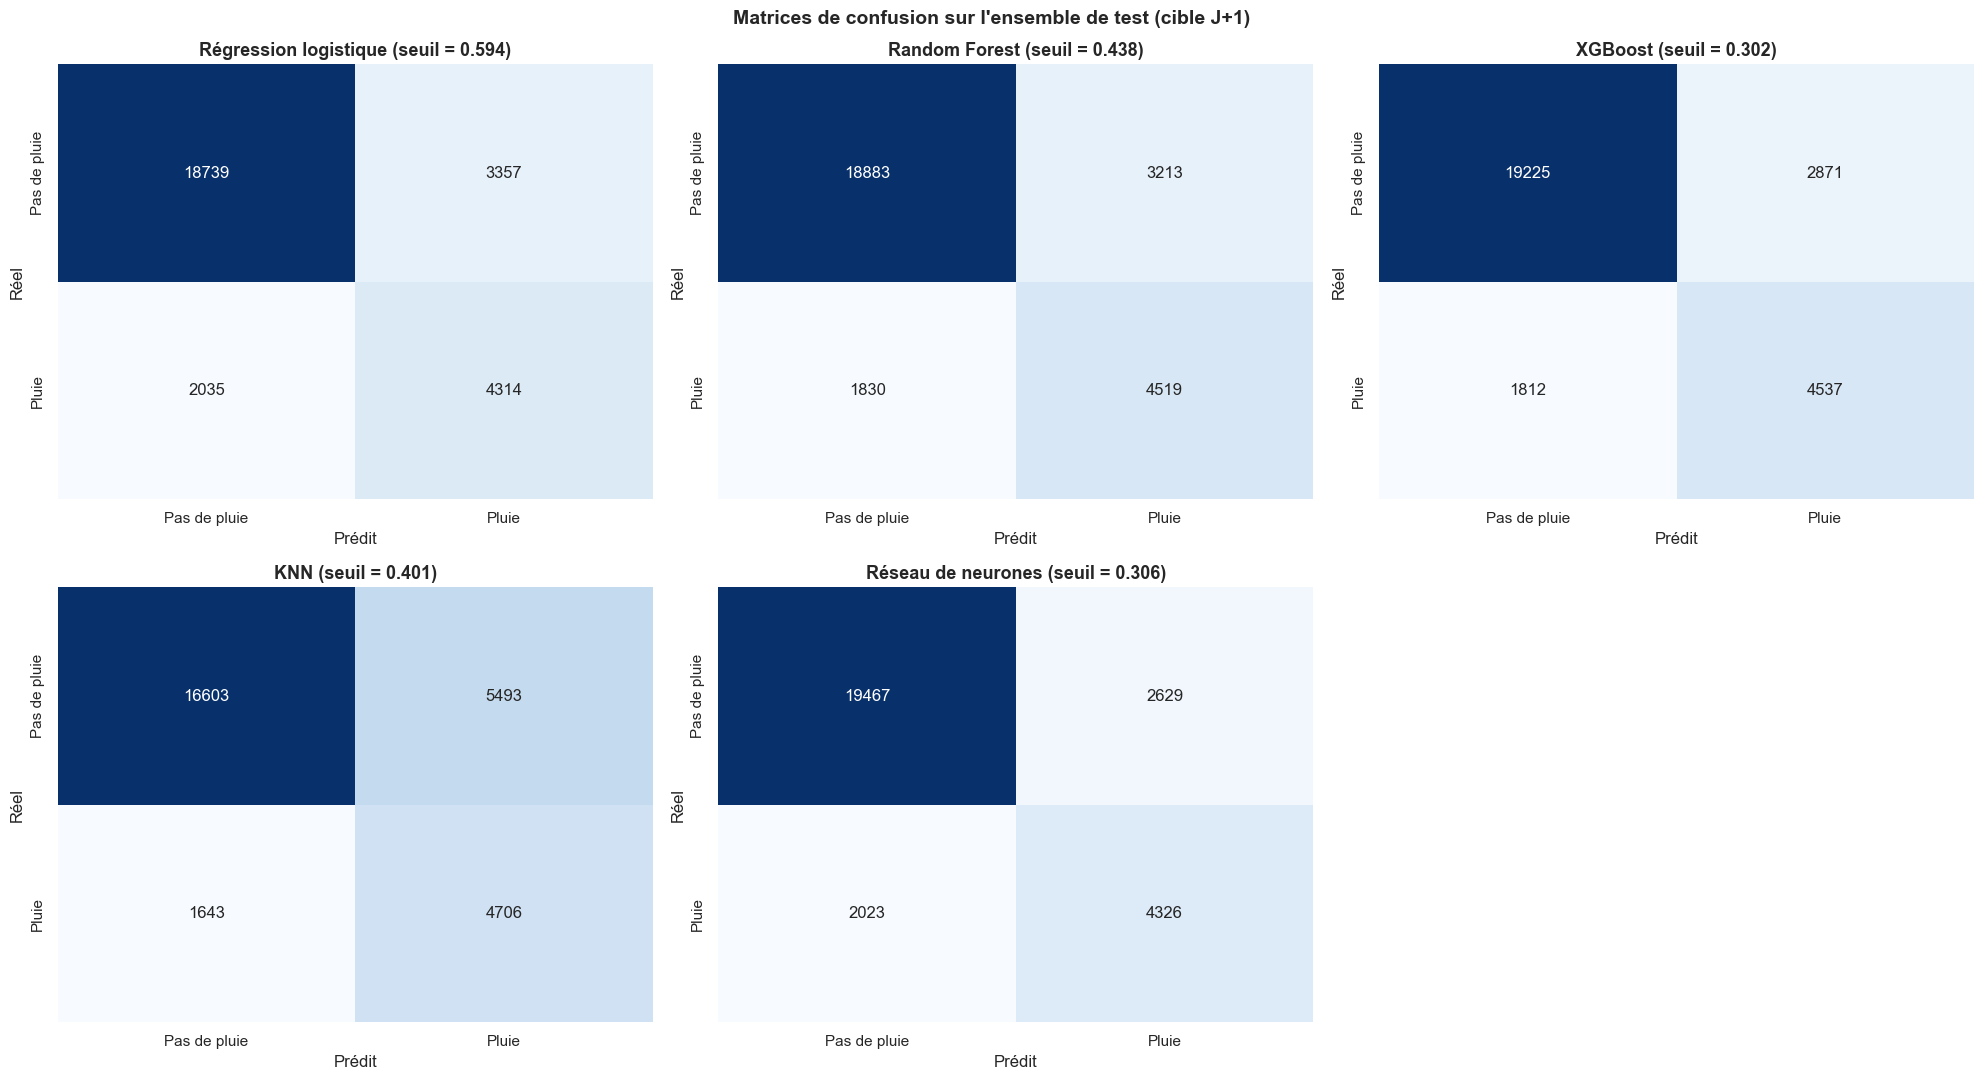

In [59]:
# CELL 59: Matrices de confusion (test)

plt.figure(figsize=(20, 11))
for i in range(len(modeles)):
    nom = modeles[i]
    plt.subplot(2, 3, i + 1)
    sns.heatmap(matrices_test[nom], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xticks([0.5, 1.5], ['Pas de pluie', 'Pluie'])
    plt.yticks([0.5, 1.5], ['Pas de pluie', 'Pluie'])
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title(f"{nom} (seuil = {seuil_retenu[nom]:.3f})", fontsize=13, fontweight='bold')

plt.suptitle("Matrices de confusion sur l'ensemble de test (cible J+1)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_05_matrices_confusion_test.png', dpi=150)
print("Figure sauvegardée: figures/etape3_05_matrices_confusion_test.png")
plt.show()

Figure sauvegardée: figures/etape3_06_courbes_roc_test.png


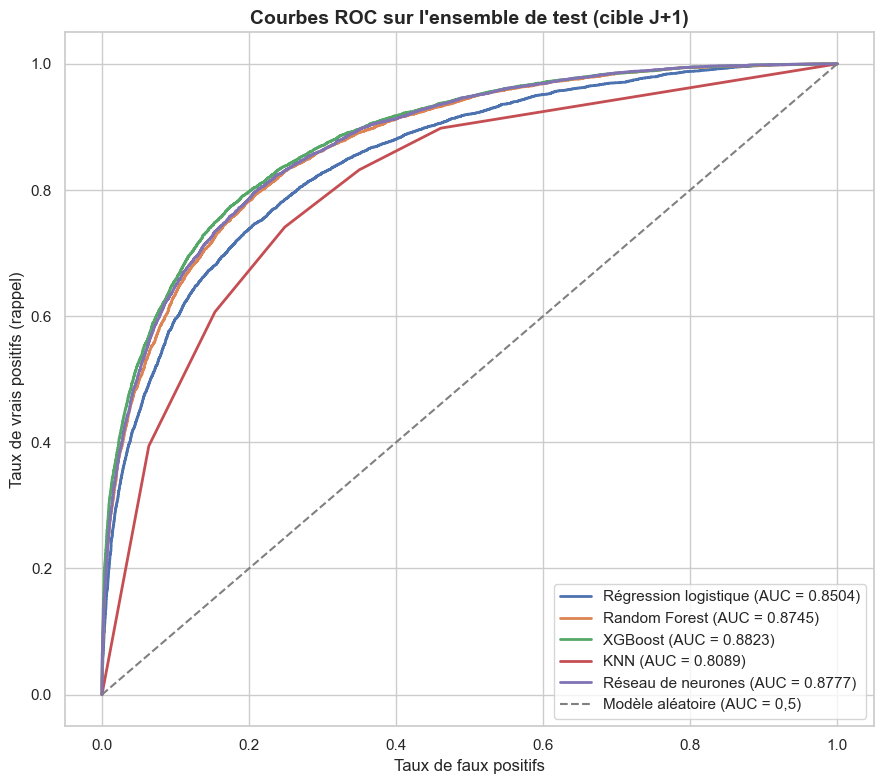

In [60]:
# CELL 60: Courbes ROC (test)

plt.figure(figsize=(9, 8))
for nom in modeles:
    fpr, tpr, auc_test = courbes_roc_test[nom]
    plt.plot(fpr, tpr, linewidth=2, label=f"{nom} (AUC = {auc_test:.4f})")
# Diagonale : modèle aléatoire (AUC = 0,5)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Modèle aléatoire (AUC = 0,5)")
plt.title("Courbes ROC sur l'ensemble de test (cible J+1)", fontsize=14, fontweight='bold')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape3_06_courbes_roc_test.png', dpi=150)
print("Figure sauvegardée: figures/etape3_06_courbes_roc_test.png")
plt.show()

In [61]:
# CELL 61: Sauvegarde des modèles finaux

ignorer_avertissements()

dossier_modeles = '../models/'
fichiers = {
    'Régression logistique': 'modele_regression_logistique.joblib',
    'KNN': 'modele_knn.joblib',
    'Random Forest': 'modele_random_forest.joblib',
    'XGBoost': 'modele_xgboost.json',
    'Réseau de neurones': 'modele_reseau_neurones.keras'
}

# Modèles scikit-learn avec joblib, XGBoost avec save_model (fichier .json), réseau de neurones avec save (.keras)
joblib.dump(modeles_finaux['Régression logistique'], dossier_modeles + fichiers['Régression logistique'])
joblib.dump(modeles_finaux['KNN'], dossier_modeles + fichiers['KNN'])
joblib.dump(modeles_finaux['Random Forest'], dossier_modeles + fichiers['Random Forest'])
modeles_finaux['XGBoost'].save_model(dossier_modeles + fichiers['XGBoost'])
modeles_finaux['Réseau de neurones'].save(dossier_modeles + fichiers['Réseau de neurones'])

# Paramètres, options de déséquilibre et seuils retenus, ensemble dans un seul fichier
fichier_parametres = 'modeles_parametres.joblib'
joblib.dump({'parametres_retenus': parametres_retenus, 'strategie_retenue': strategie_retenue,
             'seuil_retenu': seuil_retenu}, dossier_modeles + fichier_parametres)

# Taille de chaque fichier sauvegardé (en mégaoctets)
noms_fichiers = []
for nom in modeles:
    noms_fichiers.append(fichiers[nom])
noms_fichiers.append(fichier_parametres)
print("Fichiers sauvegardés dans models/:")
for nom_fichier in noms_fichiers:
    with open(dossier_modeles + nom_fichier, 'rb') as f:
        taille = len(f.read()) / (1024 * 1024)
    print(f"  {nom_fichier}: {taille:.2f} Mo")

Fichiers sauvegardés dans models/:
  modele_regression_logistique.joblib: 0.00 Mo
  modele_random_forest.joblib: 353.21 Mo
  modele_xgboost.json: 6.98 Mo
  modele_knn.joblib: 33.65 Mo
  modele_reseau_neurones.keras: 0.16 Mo
  modeles_parametres.joblib: 0.00 Mo


In [62]:
# CELL 62: Comparaison indicative : découpage aléatoire vs découpage temporel (modèle de démonstration)

from sklearn.model_selection import train_test_split

# Mesure indicative : les statistiques de préparation proviennent du découpage temporel ; seule la méthode de découpage change.

# Données préparées de XGBoost (non mises à l'échelle) : entraînement et test réunis, puis découpage aléatoire stratifié 80 / 20
X_complet = pd.concat([X_train_arbres, X_test_arbres])
y_complet = pd.concat([y_train, y_test])
X_tr_alea, X_te_alea, y_tr_alea, y_te_alea = train_test_split(X_complet, y_complet, test_size=0.2,
                                                              random_state=42, stratify=y_complet)

# Option de déséquilibre retenue (SMOTENC) sur la partie entraînement aléatoire uniquement
if strategie_retenue['XGBoost'] == 'SMOTENC':
    smote = SMOTENC(categorical_features=[position_raintoday], random_state=42)
    X_tr_alea, y_tr_alea = smote.fit_resample(X_tr_alea, y_tr_alea)

# XGBoost avec les paramètres et le seuil retenus
p = parametres_retenus['XGBoost']
modele_alea = XGBClassifier(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                            max_depth=p['max_depth'], random_state=42, n_jobs=-1)
modele_alea.fit(X_tr_alea, y_tr_alea)
pred_alea = (modele_alea.predict_proba(X_te_alea)[:, 1] >= seuil_retenu['XGBoost']).astype(int)

r = table_test[table_test['Modèle'] == 'XGBoost']
print(f"XGBoost ({strategie_retenue['XGBoost']}, seuil = {seuil_retenu['XGBoost']:.3f}):")
print(f"  Découpage aléatoire stratifié : F1 = {f1_score(y_te_alea, pred_alea):.4f} | "
      f"précision = {precision_score(y_te_alea, pred_alea):.4f} | rappel = {recall_score(y_te_alea, pred_alea):.4f}"
      f" ({len(y_te_alea)} lignes de test)")
print(f"  Découpage temporel (CELL 58)  : F1 = {r['F1'].values[0]:.4f} | précision = {r['Précision'].values[0]:.4f} | "
      f"rappel = {r['Rappel'].values[0]:.4f} ({len(y_test)} lignes de test)")
print(f"  Différence de F1 (aléatoire - temporel) = {f1_score(y_te_alea, pred_alea) - r['F1'].values[0]:+.4f}")

XGBoost (SMOTENC, seuil = 0.302):
  Découpage aléatoire stratifié : F1 = 0.6831 | précision = 0.6412 | rappel = 0.7308 (28439 lignes de test)
  Découpage temporel (CELL 58)  : F1 = 0.6596 | précision = 0.6124 | rappel = 0.7146 (28445 lignes de test)
  Différence de F1 (aléatoire - temporel) = +0.0235


In [63]:
# CELL 63: Performances sur l'ensemble d'entraînement (détection du surapprentissage)

# Un grand écart positif entraînement - test signale un surapprentissage (le modèle a appris les lignes
# d'entraînement plutôt que la règle générale) ; un petit écart indique un modèle qui généralise.
# Les scores d'entraînement sont calculés sur les lignes d'entraînement d'origine (pas sur les lignes SMOTENC),
# avec le seuil retenu de chaque modèle.
lignes_surapprentissage = []
for nom in modeles:
    if nom == 'Réseau de neurones':
        proba_tr = modeles_finaux[nom].predict(X_train_scaled.values, verbose=0)[:, 1]
    elif nom == 'Random Forest' or nom == 'XGBoost':
        proba_tr = modeles_finaux[nom].predict_proba(X_train_arbres)[:, 1]
    else:
        proba_tr = modeles_finaux[nom].predict_proba(X_train_scaled)[:, 1]
    pred_tr = (proba_tr >= seuil_retenu[nom]).astype(int)
    fpr, tpr, seuils_roc = roc_curve(y_train, proba_tr)
    r = table_test[table_test['Modèle'] == nom]
    lignes_surapprentissage.append({
        'Modèle': nom,
        'F1 entraînement': f1_score(y_train, pred_tr), 'F1 test': r['F1'].values[0],
        'Écart F1': f1_score(y_train, pred_tr) - r['F1'].values[0],
        'Exactitude entraînement': accuracy_score(y_train, pred_tr), 'Exactitude test': r['Exactitude'].values[0],
        'Écart exactitude': accuracy_score(y_train, pred_tr) - r['Exactitude'].values[0],
        'AUC entraînement': auc(fpr, tpr), 'AUC test': r['AUC'].values[0], 'Écart AUC': auc(fpr, tpr) - r['AUC'].values[0]
    })
    print(f"{nom} | entraînement: F1 = {f1_score(y_train, pred_tr):.4f} | précision = {precision_score(y_train, pred_tr):.4f} | "
          f"rappel = {recall_score(y_train, pred_tr):.4f} | exactitude = {accuracy_score(y_train, pred_tr):.4f} | "
          f"AUC = {auc(fpr, tpr):.4f}")

Régression logistique | entraînement: F1 = 0.6251 | précision = 0.5764 | rappel = 0.6829 | exactitude = 0.8162 | AUC = 0.8581


Random Forest | entraînement: F1 = 0.9624 | précision = 0.9276 | rappel = 1.0000 | exactitude = 0.9825 | AUC = 1.0000


XGBoost | entraînement: F1 = 0.8666 | précision = 0.8185 | rappel = 0.9208 | exactitude = 0.9364 | AUC = 0.9837


KNN | entraînement: F1 = 0.7552 | précision = 0.6183 | rappel = 0.9699 | exactitude = 0.8589 | AUC = 0.9787


Réseau de neurones | entraînement: F1 = 0.6795 | précision = 0.6599 | rappel = 0.7003 | exactitude = 0.8518 | AUC = 0.8973


In [64]:
# CELL 64: Comparaison des performances entraînement / test

table_surapprentissage = pd.DataFrame(lignes_surapprentissage)
table_affichage_surapp = table_surapprentissage.copy()
for col in ['F1 entraînement', 'F1 test', 'Écart F1', 'Exactitude entraînement', 'Exactitude test', 'Écart exactitude',
            'AUC entraînement', 'AUC test', 'Écart AUC']:
    valeurs_arrondies = []
    for v in table_surapprentissage[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_surapp[col] = valeurs_arrondies
print("\nPerformances entraînement / test (seuil retenu de chaque modèle):")
print(table_affichage_surapp)


Performances entraînement / test (seuil retenu de chaque modèle):
                  Modèle  F1 entraînement  F1 test  Écart F1  Exactitude entraînement  Exactitude test  Écart exactitude  AUC entraînement  AUC test  Écart AUC
0  Régression logistique           0.6251   0.6154    0.0097                   0.8162           0.8104            0.0057            0.8581    0.8504     0.0077
1          Random Forest           0.9624   0.6419    0.3206                   0.9825           0.8227            0.1598            1.0000    0.8745     0.1254
2                XGBoost           0.8666   0.6596    0.2071                   0.9364           0.8354            0.1010            0.9837    0.8823     0.1015
3                    KNN           0.7552   0.5688    0.1864                   0.8589           0.7491            0.1098            0.9787    0.8089     0.1698
4     Réseau de neurones           0.6795   0.6503    0.0292                   0.8518           0.8365            0.0153            0

In [65]:
# CELL 65: Interprétation de la régression logistique (odds ratios)

# Odds ratio = exp(coefficient). Les variables sont mises à l'échelle : un odds ratio supérieur à 1 augmente
# la probabilité de pluie le lendemain quand la variable augmente, un odds ratio inférieur à 1 la diminue.
coefficients = modeles_finaux['Régression logistique'].coef_[0]
table_odds = pd.DataFrame({
    'Variable': X_train_scaled.columns,
    'Coefficient': coefficients,
    'Odds ratio': np.exp(coefficients)
}).sort_values('Odds ratio', ascending=False).reset_index().drop(columns=['index'])

table_affichage_odds = table_odds.copy()
coefficients_arrondis = []
odds_arrondis = []
for i in range(len(table_odds)):
    coefficients_arrondis.append(round(table_odds['Coefficient'].values[i], 4))
    odds_arrondis.append(round(table_odds['Odds ratio'].values[i], 4))
table_affichage_odds['Coefficient'] = coefficients_arrondis
table_affichage_odds['Odds ratio'] = odds_arrondis
print("Régression logistique finale, odds ratios triés par ordre décroissant:")
print(table_affichage_odds)

Régression logistique finale, odds ratios triés par ordre décroissant:
            Variable  Coefficient  Odds ratio
0        Humidity3pm       0.9565      2.6025
1      WindGustSpeed       0.8132      2.2550
2        Humidity9am       0.5219      1.6852
3          RainToday       0.5189      1.6801
4     WindDir9am_cos       0.3543      1.4252
5      Humidity_diff       0.3190      1.3758
6     WindDir3pm_cos       0.2930      1.3404
7            MinTemp       0.2839      1.3283
8         Season_sin       0.0240      1.0243
9     WindDir9am_sin       0.0196      1.0198
10          Rainfall       0.0077      1.0078
11         Temp_diff       0.0003      1.0003
12   WindGustDir_sin      -0.0246      0.9757
13  Location_encoded      -0.0507      0.9506
14      WindSpeed9am      -0.0810      0.9222
15        Season_cos      -0.1228      0.8845
16           Temp3pm      -0.1617      0.8507
17         Month_sin      -0.1635      0.8492
18   WindGustDir_cos      -0.1836      0.8323
19       

Figure sauvegardée: figures/etape3_07_odds_ratios.png


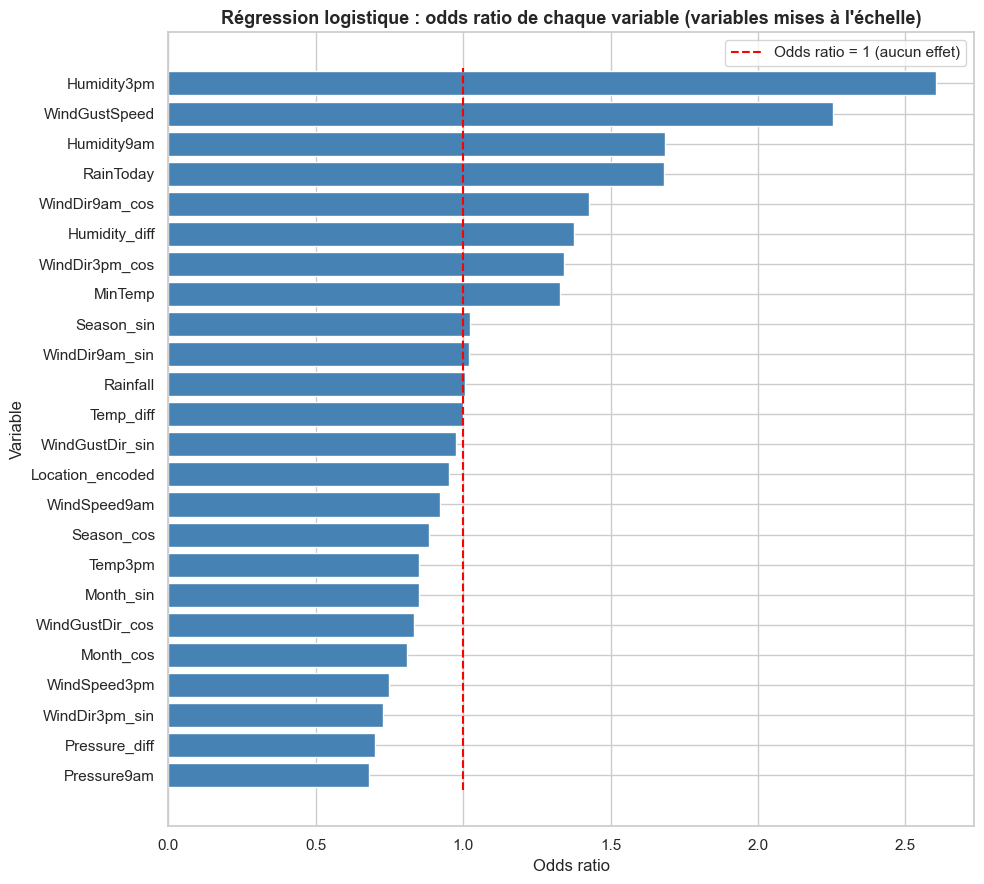

In [66]:
# CELL 66: Graphique des odds ratios

# Diagramme en barres horizontales, plus grand odds ratio en haut, ligne de référence à 1
table_graphique = table_odds.sort_values('Odds ratio', ascending=True)
plt.figure(figsize=(10, 9))
plt.barh(table_graphique['Variable'], table_graphique['Odds ratio'], color='steelblue')
plt.plot([1, 1], [-0.5, len(table_graphique) - 0.5], color='red', linestyle='--', label="Odds ratio = 1 (aucun effet)")
plt.title("Régression logistique : odds ratio de chaque variable (variables mises à l'échelle)",
          fontsize=13, fontweight='bold')
plt.xlabel("Odds ratio")
plt.ylabel("Variable")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape3_07_odds_ratios.png', dpi=150)
print("Figure sauvegardée: figures/etape3_07_odds_ratios.png")
plt.show()

In [67]:
# CELL 67: Importance des variables (Random Forest et XGBoost)

def table_importance(modele, colonnes, nom):
    # Importance des variables du modèle final, triée par ordre décroissant, affichée à 4 décimales
    table = pd.DataFrame({
        'Variable': colonnes,
        'Importance': modele.feature_importances_
    }).sort_values('Importance', ascending=False).reset_index().drop(columns=['index'])
    table_affichage_imp = table.copy()
    importances_arrondies = []
    for v in table['Importance'].values:
        importances_arrondies.append(round(v, 4))
    table_affichage_imp['Importance'] = importances_arrondies
    print(f"{nom} final, importance des variables triée par ordre décroissant:")
    print(table_affichage_imp)
    print()
    return table


tables_importance = {}
tables_importance['Random Forest'] = table_importance(modeles_finaux['Random Forest'], X_train_arbres.columns, 'Random Forest')
tables_importance['XGBoost'] = table_importance(modeles_finaux['XGBoost'], X_train_arbres.columns, 'XGBoost')

Random Forest final, importance des variables triée par ordre décroissant:
            Variable  Importance
0        Humidity3pm      0.1588
1          Temp_diff      0.0815
2        Pressure9am      0.0683
3        Humidity9am      0.0682
4      Humidity_diff      0.0609
5      WindGustSpeed      0.0597
6           Rainfall      0.0531
7            Temp3pm      0.0493
8      Pressure_diff      0.0468
9            MinTemp      0.0450
10  Location_encoded      0.0374
11      WindSpeed3pm      0.0316
12         RainToday      0.0313
13      WindSpeed9am      0.0285
14    WindDir3pm_cos      0.0246
15    WindDir9am_cos      0.0235
16   WindGustDir_cos      0.0209
17   WindGustDir_sin      0.0204
18    WindDir3pm_sin      0.0204
19    WindDir9am_sin      0.0200
20         Month_cos      0.0176
21         Month_sin      0.0169
22        Season_sin      0.0078
23        Season_cos      0.0075

XGBoost final, importance des variables triée par ordre décroissant:
            Variable  Importan

Figure sauvegardée: figures/etape3_08_importance_variables.png


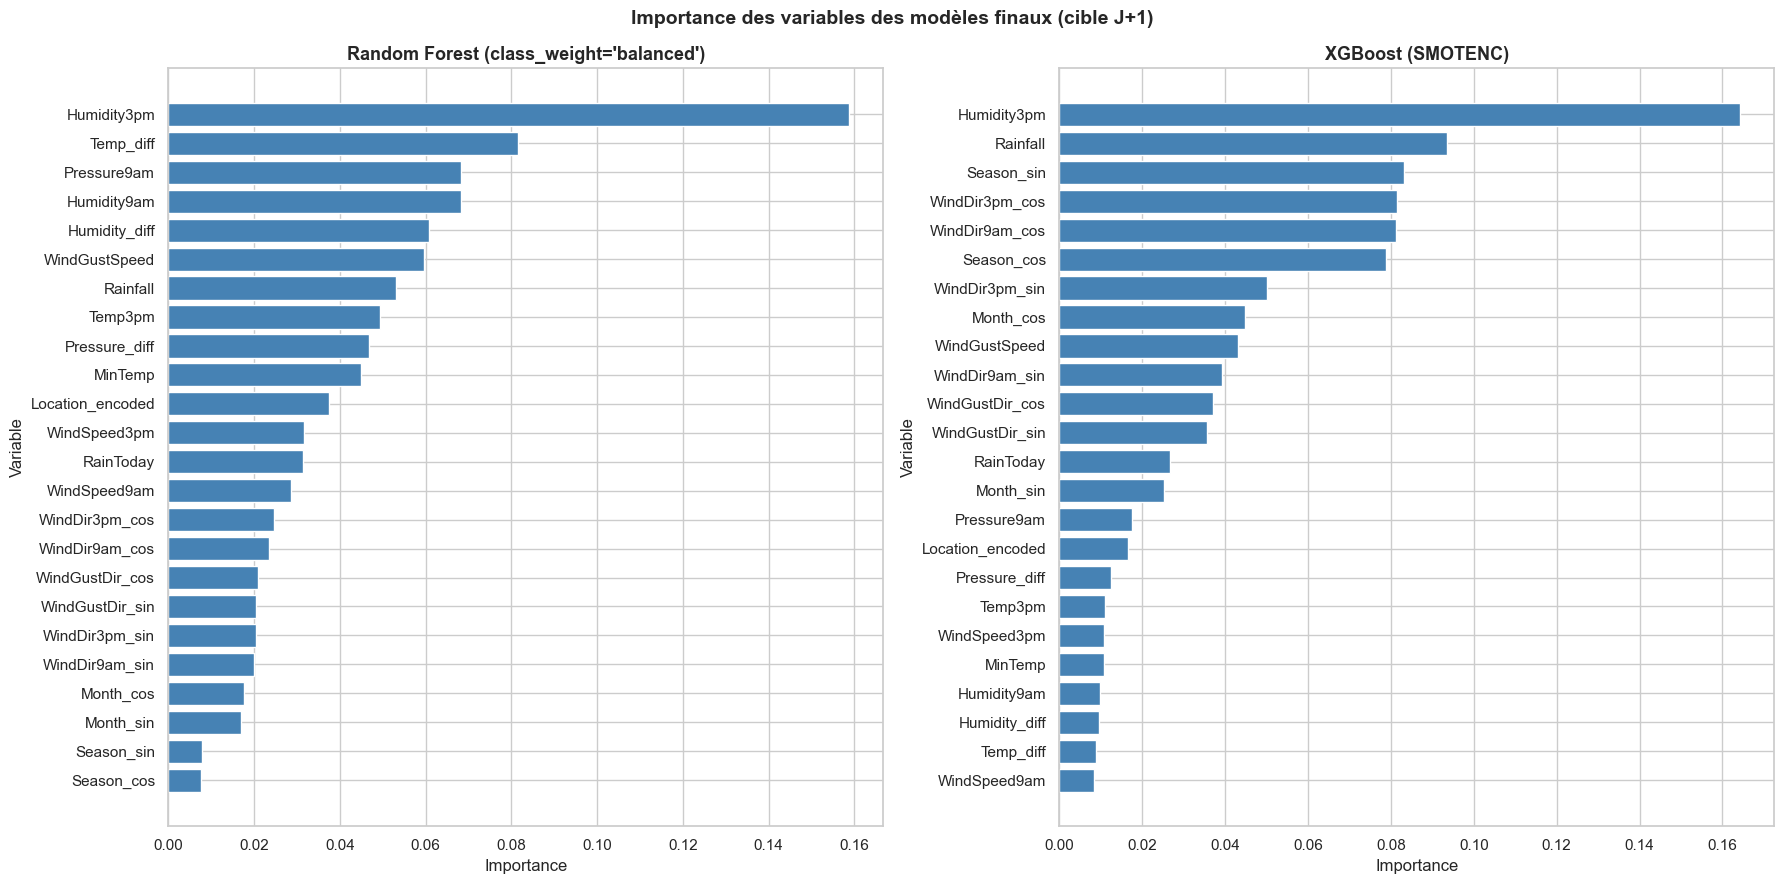

In [68]:
# CELL 68: Graphique de l'importance des variables

# Un panneau par modèle, variable la plus importante en haut
plt.figure(figsize=(18, 9))

plt.subplot(1, 2, 1)
table_graphique = tables_importance['Random Forest'].sort_values('Importance', ascending=True)
plt.barh(table_graphique['Variable'], table_graphique['Importance'], color='steelblue')
plt.title(f"Random Forest ({strategie_retenue['Random Forest']})", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.subplot(1, 2, 2)
table_graphique = tables_importance['XGBoost'].sort_values('Importance', ascending=True)
plt.barh(table_graphique['Variable'], table_graphique['Importance'], color='steelblue')
plt.title(f"XGBoost ({strategie_retenue['XGBoost']})", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.suptitle("Importance des variables des modèles finaux (cible J+1)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_08_importance_variables.png', dpi=150)
print("Figure sauvegardée: figures/etape3_08_importance_variables.png")
plt.show()

In [69]:
# CELL 69: Valeurs SHAP du modèle XGBoost final sur l'ensemble de test

import shap

# TreeExplainer : valeurs SHAP exactes pour un modèle à base d'arbres, calculées sur les données de test non mises
# à l'échelle (celles sur lesquelles XGBoost prédit, CELL 56) ; elles s'expriment dans l'unité de la sortie brute
# du modèle (log-odds de la classe 1)
explainer = shap.TreeExplainer(modeles_finaux['XGBoost'])
valeurs_shap = explainer.shap_values(X_test_arbres)
print(f"Valeurs SHAP: {valeurs_shap.shape[0]} lignes × {valeurs_shap.shape[1]} variables")
print(f"Valeur de base (sortie brute moyenne du modèle): {explainer.expected_value:.4f}")

# Contrôle : valeur de base + somme des valeurs SHAP d'une ligne = sortie brute du modèle pour cette ligne ;
# sortie brute = log(p / (1 - p)), p étant la probabilité de la classe 1 (CELL 56)
sortie_brute = np.log(probas_test['XGBoost'] / (1 - probas_test['XGBoost']))
ecart_shap = np.abs(explainer.expected_value + valeurs_shap.sum(axis=1) - sortie_brute).max()
print(f"Écart maximal entre valeur de base + somme des valeurs SHAP et sortie brute du modèle: {ecart_shap:.2e}")

Valeurs SHAP: 28445 lignes × 24 variables
Valeur de base (sortie brute moyenne du modèle): 0.0090
Écart maximal entre valeur de base + somme des valeurs SHAP et sortie brute du modèle: 1.01e-04


In [70]:
# CELL 70: Valeur SHAP absolue moyenne de chaque variable et rang dans l'importance intégrée de XGBoost

def table_shap_xgboost(valeurs, colonnes, table_imp):
    # Valeur SHAP absolue moyenne de chaque variable sur le test, triée par ordre décroissant, avec le rang SHAP
    # et le rang de la variable dans l'importance intégrée (feature_importances_, table triée de table_importance)
    rang_importance = {}
    for i in range(len(table_imp)):
        rang_importance[table_imp['Variable'].values[i]] = i + 1
    table = pd.DataFrame({'Variable': colonnes, 'SHAP absolu moyen': np.abs(valeurs).mean(axis=0)})
    table = table.sort_values('SHAP absolu moyen', ascending=False).reset_index().drop(columns=['index'])
    table['Rang SHAP'] = np.arange(1, len(table) + 1)
    rangs = []
    for variable in table['Variable']:
        rangs.append(rang_importance[variable])
    table['Rang importance XGBoost'] = rangs
    return table


table_shap = table_shap_xgboost(valeurs_shap, X_test_arbres.columns, tables_importance['XGBoost'])
table_affichage_shap = table_shap.copy()
valeurs_arrondies = []
for v in table_shap['SHAP absolu moyen'].values:
    valeurs_arrondies.append(round(v, 4))
table_affichage_shap['SHAP absolu moyen'] = valeurs_arrondies
print("XGBoost final, 15 premières variables par valeur SHAP absolue moyenne sur le test,")
print("avec leur rang dans l'importance intégrée de XGBoost (CELL 67):")
print(table_affichage_shap.head(15))

XGBoost final, 15 premières variables par valeur SHAP absolue moyenne sur le test,
avec leur rang dans l'importance intégrée de XGBoost (CELL 67):
            Variable  SHAP absolu moyen  Rang SHAP  Rang importance XGBoost
0        Humidity3pm             1.1080          1                        1
1      WindGustSpeed             0.5051          2                        9
2        Pressure9am             0.4037          3                       15
3            Temp3pm             0.3416          4                       18
4      Pressure_diff             0.2867          5                       17
5           Rainfall             0.2842          6                        2
6   Location_encoded             0.2298          7                       16
7     WindDir3pm_cos             0.2235          8                        4
8            MinTemp             0.2082          9                       20
9          RainToday             0.1938         10                       13
10    WindDir9am_

Figure sauvegardée: figures/etape3_19_shap_xgboost.png


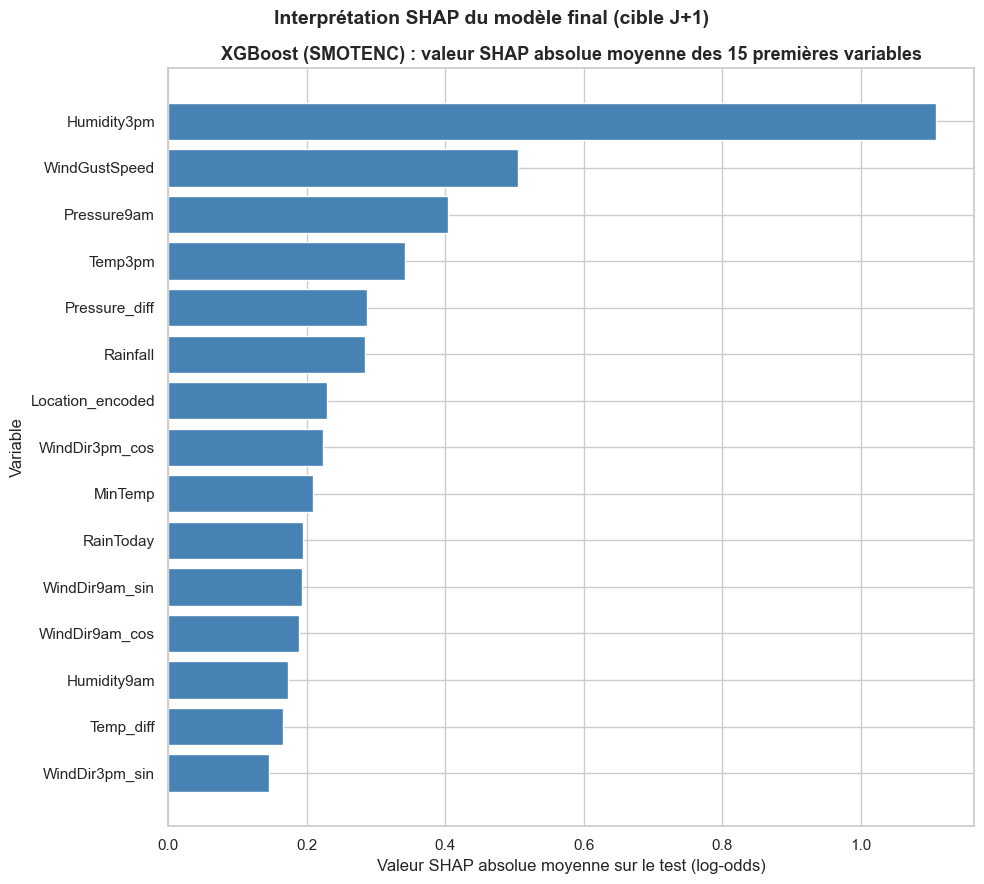

In [71]:
# CELL 71: Graphique de la valeur SHAP absolue moyenne (15 premières variables)

# Barres horizontales, variable à la plus forte valeur SHAP absolue moyenne en haut
table_graphique = table_shap.head(15).sort_values('SHAP absolu moyen', ascending=True)
plt.figure(figsize=(10, 9))
plt.barh(table_graphique['Variable'], table_graphique['SHAP absolu moyen'], color='steelblue')
plt.title(f"XGBoost ({strategie_retenue['XGBoost']}) : valeur SHAP absolue moyenne des 15 premières variables",
          fontsize=13, fontweight='bold')
plt.xlabel("Valeur SHAP absolue moyenne sur le test (log-odds)")
plt.ylabel("Variable")
plt.suptitle("Interprétation SHAP du modèle final (cible J+1)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_19_shap_xgboost.png', dpi=150)
print("Figure sauvegardée: figures/etape3_19_shap_xgboost.png")
plt.show()

Figure sauvegardée: figures/etape3_20_shap_dependance.png


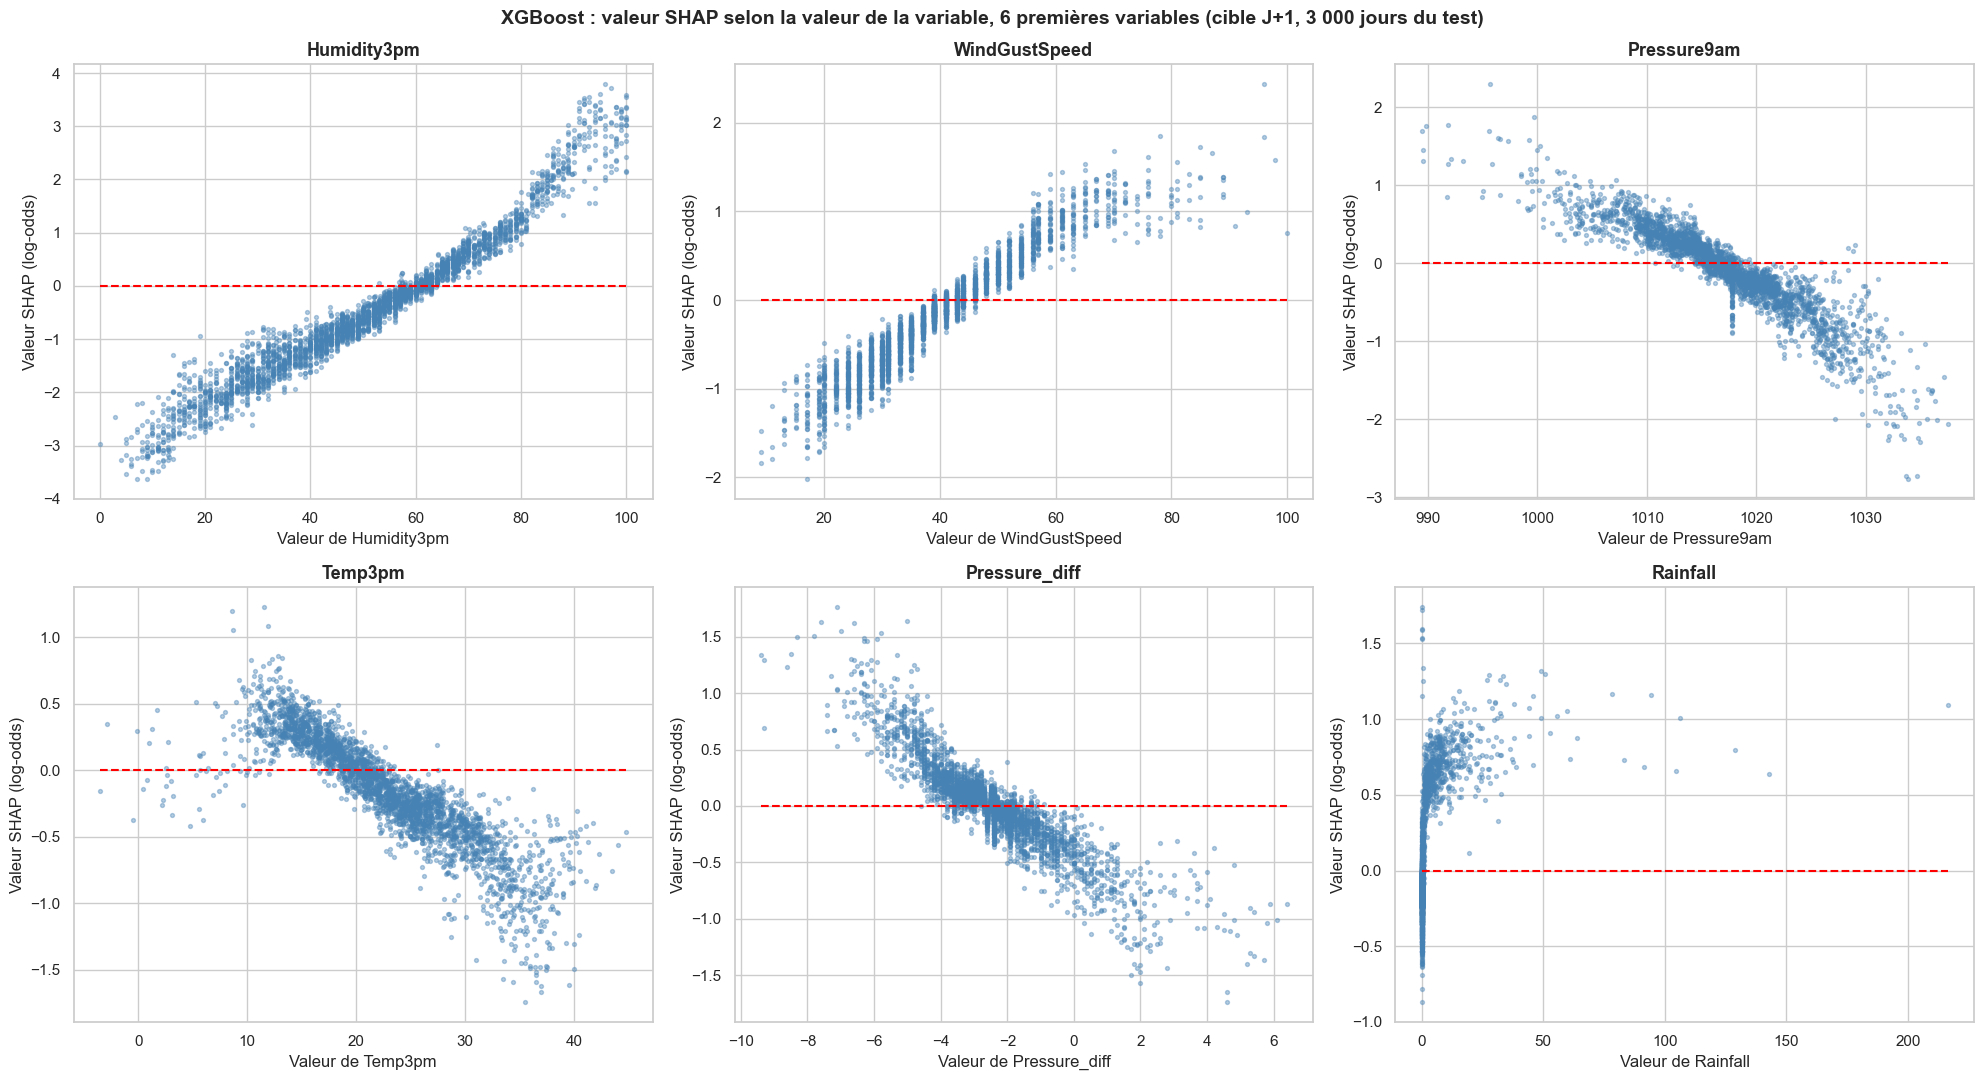

In [72]:
# CELL 72: Graphique de dépendance SHAP des 6 variables à la plus forte valeur SHAP absolue moyenne

def panneaux_dependance(table, X, valeurs):
    # Un panneau par variable : valeur de la variable (données non mises à l'échelle) et sa valeur SHAP, sur un
    # échantillon aléatoire de 3 000 lignes du test (lisibilité) ; ligne de référence à 0 (aucun effet)
    echantillon = X.sample(n=3000, random_state=42)
    for i in range(6):
        variable = table['Variable'].values[i]
        valeurs_variable = valeurs[echantillon.index, list(X.columns).index(variable)]
        plt.subplot(2, 3, i + 1)
        plt.scatter(echantillon[variable], valeurs_variable, s=8, alpha=0.4, color='steelblue')
        plt.plot([echantillon[variable].min(), echantillon[variable].max()], [0, 0], color='red', linestyle='--')
        plt.title(variable, fontsize=13, fontweight='bold')
        plt.xlabel(f"Valeur de {variable}")
        plt.ylabel("Valeur SHAP (log-odds)")


plt.figure(figsize=(20, 11))
panneaux_dependance(table_shap, X_test_arbres, valeurs_shap)
plt.suptitle("XGBoost : valeur SHAP selon la valeur de la variable, 6 premières variables "
             "(cible J+1, 3 000 jours du test)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_20_shap_dependance.png', dpi=150)
print("Figure sauvegardée: figures/etape3_20_shap_dependance.png")
plt.show()

In [73]:
# CELL 73: Scores par station sur l'ensemble de test

# Scores de chaque station sur le test, à partir des probabilités de CELL 56 et du seuil retenu de chaque modèle
# (fonction scores_au_seuil de CELL 46 : précision fixée à 0 si aucune prédiction positive)
stations = np.sort(meta_test['Location'].unique())
lignes_stations = []
for nom in modeles:
    for station in stations:
        masque = (meta_test['Location'] == station).values
        y_station = y_test[masque]
        f1, precision, rappel = scores_au_seuil(probas_test[nom][masque], y_station, seuil_retenu[nom])
        lignes_stations.append({
            'Modèle': nom,
            'Station': station,
            'Jours de test': len(y_station),
            'Jours de pluie': int(y_station.sum()),
            'F1': f1,
            'Précision': precision,
            'Rappel': rappel
        })
table_stations = pd.DataFrame(lignes_stations)

In [74]:
# CELL 74: Analyse par station : meilleur modèle et résumé par modèle

# Modèle au meilleur F1 sur le test (CELL 58, ligne 0 du tableau trié)
meilleur_modele = table_test['Modèle'].values[0]
table_meilleur = table_stations[table_stations['Modèle'] == meilleur_modele].sort_values('F1', ascending=False)
table_meilleur = table_meilleur.reset_index().drop(columns=['index'])
table_affichage_stations = table_meilleur.copy()
for col in ['F1', 'Précision', 'Rappel']:
    valeurs_arrondies = []
    for v in table_meilleur[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_stations[col] = valeurs_arrondies
print(f"{meilleur_modele} (meilleur F1 sur le test), scores par station triés par F1 décroissant:")
print(table_affichage_stations)

# Résumé par modèle : F1 moyen, minimal et maximal des stations, nombre de stations avec F1 < 0,5
print(f"\nRésumé du F1 par station ({len(stations)} stations):")
for nom in modeles:
    r = table_stations[table_stations['Modèle'] == nom]
    print(f"  {nom}: F1 moyen = {r['F1'].mean():.4f} | minimum = {r['F1'].min():.4f} | maximum = {r['F1'].max():.4f} | "
          f"stations avec F1 < 0,5: {(r['F1'] < 0.5).sum()}")

XGBoost (meilleur F1 sur le test), scores par station triés par F1 décroissant:
     Modèle           Station  Jours de test  Jours de pluie      F1  Précision  Rappel
0   XGBoost           Walpole            574             202  0.7730     0.7078  0.8515
1   XGBoost       Witchcliffe            584             168  0.7629     0.7035  0.8333
2   XGBoost       MountGinini            593             165  0.7464     0.7191  0.7758
3   XGBoost          Dartmoor            592             171  0.7459     0.6935  0.8070
4   XGBoost            Darwin            593             189  0.7416     0.6769  0.8201
5   XGBoost      MountGambier            584             175  0.7358     0.6730  0.8114
6   XGBoost        PearceRAAF            585             106  0.7319     0.6667  0.8113
7   XGBoost         Nuriootpa            591             125  0.7300     0.6957  0.7680
8   XGBoost          Portland            591             210  0.7297     0.6776  0.7905
9   XGBoost        WaggaWagga           

Figure sauvegardée: figures/etape3_09_analyse_par_station.png


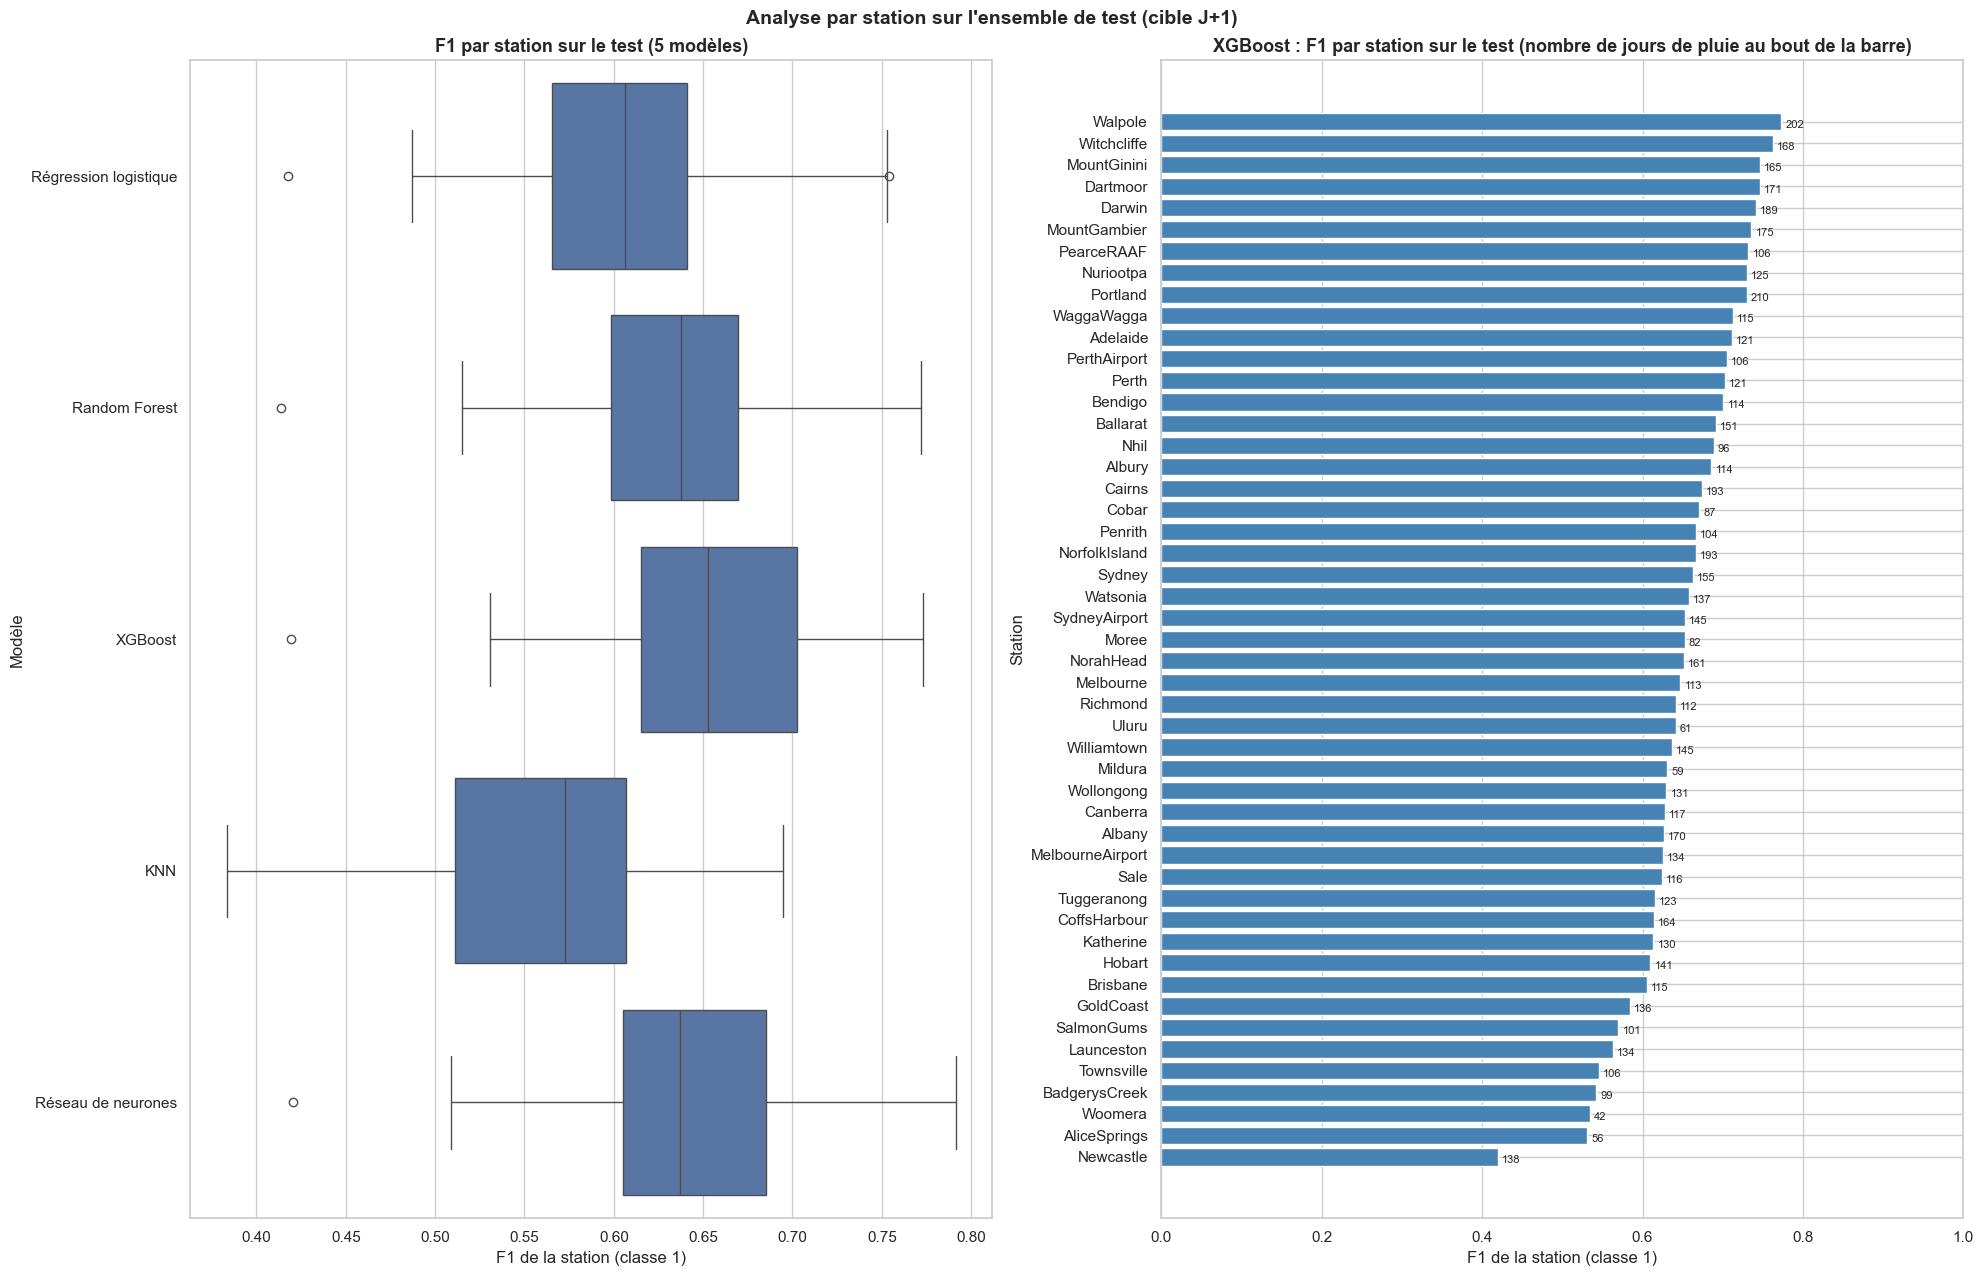

In [75]:
# CELL 75: Visualisation par station

ignorer_avertissements()

plt.figure(figsize=(20, 13))

# Panneau 1 : distribution du F1 par station pour les 5 modèles (boîtes horizontales, noms de modèles lisibles)
plt.subplot(1, 2, 1)
sns.boxplot(x='F1', y='Modèle', data=table_stations)
plt.title("F1 par station sur le test (5 modèles)", fontsize=13, fontweight='bold')
plt.xlabel("F1 de la station (classe 1)")
plt.ylabel("Modèle")

# Panneau 2 : F1 par station du meilleur modèle, nombre de jours de pluie du test au bout de chaque barre
table_graphique = table_meilleur.sort_values('F1', ascending=True)
plt.subplot(1, 2, 2)
plt.barh(table_graphique['Station'], table_graphique['F1'], color='steelblue')
for i in range(len(table_graphique)):
    plt.text(table_graphique['F1'].values[i] + 0.005, i - 0.3, str(table_graphique['Jours de pluie'].values[i]), fontsize=8)
plt.title(f"{meilleur_modele} : F1 par station sur le test (nombre de jours de pluie au bout de la barre)",
          fontsize=13, fontweight='bold')
plt.xlabel("F1 de la station (classe 1)")
plt.ylabel("Station")
plt.xlim(0, 1)

plt.suptitle("Analyse par station sur l'ensemble de test (cible J+1)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_09_analyse_par_station.png', dpi=150)
print("Figure sauvegardée: figures/etape3_09_analyse_par_station.png")
plt.show()

In [76]:
# CELL 76: J+2 : chargement des données (cible RainInTwoDays, pluie dans deux jours)

# Jeux J+2 produits par 02_preprocessing : lignes où RainInTwoDays est connue, colonne Location_encoded_J2
# (taux de pluie à J+2 par station) à la place de Location_encoded. Mêmes étapes que pour J+1 (CELL 1 à CELL 75).
X_train_scaled_J2 = pd.read_csv(dossier + 'X_train_J2_scaled.csv')
X_test_scaled_J2 = pd.read_csv(dossier + 'X_test_J2_scaled.csv')
X_train_arbres_J2 = pd.read_csv(dossier + 'X_train_J2_arbres.csv')
X_test_arbres_J2 = pd.read_csv(dossier + 'X_test_J2_arbres.csv')
y_train_J2 = pd.read_csv(dossier + 'y_train_J2.csv')['RainInTwoDays']
y_test_J2 = pd.read_csv(dossier + 'y_test_J2.csv')['RainInTwoDays']
meta_train_J2 = pd.read_csv(dossier + 'meta_train_J2.csv')
meta_test_J2 = pd.read_csv(dossier + 'meta_test_J2.csv')
meta_train_J2['Date'] = pd.to_datetime(meta_train_J2['Date'])
meta_test_J2['Date'] = pd.to_datetime(meta_test_J2['Date'])

print(f"X_train_scaled_J2: {X_train_scaled_J2.shape} | X_test_scaled_J2: {X_test_scaled_J2.shape}")
print(f"X_train_arbres_J2: {X_train_arbres_J2.shape} | X_test_arbres_J2: {X_test_arbres_J2.shape}")
print(f"y_train_J2: {y_train_J2.shape} | y_test_J2: {y_test_J2.shape}")
print(f"meta_train_J2: {meta_train_J2.shape} | meta_test_J2: {meta_test_J2.shape}")
print(f"\nColonnes ({X_train_scaled_J2.shape[1]}): {list(X_train_scaled_J2.columns)}")
print(f"Mêmes colonnes dans les jeux mis à l'échelle et non mis à l'échelle: "
      f"{list(X_train_scaled_J2.columns) == list(X_train_arbres_J2.columns)}")
print(f"\nTaux de pluie dans deux jours (y = 1): entraînement {y_train_J2.mean() * 100:.2f}% | test {y_test_J2.mean() * 100:.2f}%")

X_train_scaled_J2: (112353, 24) | X_test_scaled_J2: (28078, 24)
X_train_arbres_J2: (112353, 24) | X_test_arbres_J2: (28078, 24)
y_train_J2: (112353,) | y_test_J2: (28078,)
meta_train_J2: (112353, 2) | meta_test_J2: (28078, 2)

Colonnes (24): ['MinTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Temp3pm', 'RainToday', 'Temp_diff', 'Humidity_diff', 'Pressure_diff', 'Month_sin', 'Month_cos', 'Season_sin', 'Season_cos', 'WindGustDir_sin', 'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos', 'Location_encoded_J2']
Mêmes colonnes dans les jeux mis à l'échelle et non mis à l'échelle: True

Taux de pluie dans deux jours (y = 1): entraînement 22.18% | test 22.10%


In [77]:
# CELL 77: J+2 : définition des plis chronologiques

# Même découpage que J+1 (CELL 3), sur les dates de meta_train_J2 : 6 blocs consécutifs de dates,
# pli k (k = 1 à 5) : entraînement = blocs 1 à k, validation = bloc k+1 (fenêtre croissante)
dates_uniques_J2 = np.sort(meta_train_J2['Date'].unique())
blocs_J2 = np.array_split(dates_uniques_J2, 6)
plis_J2 = []
for k in range(1, 6):
    masque_tr = meta_train_J2['Date'].isin(np.concatenate(blocs_J2[:k]))
    masque_va = meta_train_J2['Date'].isin(blocs_J2[k])
    plis_J2.append((masque_tr, masque_va))

    dates_entrainement = meta_train_J2.loc[masque_tr, 'Date']
    dates_validation = meta_train_J2.loc[masque_va, 'Date']
    print(f"Pli {k}:")
    print(f"  Entraînement: du {str(dates_entrainement.min())[:10]} au {str(dates_entrainement.max())[:10]}"
          f" ({masque_tr.sum()} lignes)")
    print(f"  Validation:   du {str(dates_validation.min())[:10]} au {str(dates_validation.max())[:10]}"
          f" ({masque_va.sum()} lignes, RainInTwoDays = Yes: {y_train_J2[masque_va].mean() * 100:.2f}%)")

Pli 1:
  Entraînement: du 2007-11-01 au 2009-02-15 (4351 lignes)
  Validation:   du 2009-02-16 au 2010-06-03 (21266 lignes, RainInTwoDays = Yes: 21.97%)
Pli 2:
  Entraînement: du 2007-11-01 au 2010-06-03 (25617 lignes)
  Validation:   du 2010-06-04 au 2011-10-21 (21081 lignes, RainInTwoDays = Yes: 25.18%)
Pli 3:
  Entraînement: du 2007-11-01 au 2011-10-21 (46698 lignes)
  Validation:   du 2011-10-22 au 2013-04-09 (21210 lignes, RainInTwoDays = Yes: 22.00%)
Pli 4:
  Entraînement: du 2007-11-01 au 2013-04-09 (67908 lignes)
  Validation:   du 2013-04-10 au 2014-07-25 (22322 lignes, RainInTwoDays = Yes: 21.91%)
Pli 5:
  Entraînement: du 2007-11-01 au 2014-07-25 (90230 lignes)
  Validation:   du 2014-07-26 au 2015-11-09 (22123 lignes, RainInTwoDays = Yes: 20.49%)


In [78]:
# CELL 78: J+2 : préparation des données de chaque pli

# Location_encoded_J2 recalculée sur la partie entraînement du pli à partir de y_train_J2 (cible J+2), puis mise
# à l'échelle pour les données mises à l'échelle (fonctions de CELL 4)
donnees_plis_J2 = []
y_va_plis_J2 = []
for k in range(len(plis_J2)):
    Xs_tr, Xs_va = encoder_location_pli(X_train_scaled_J2, meta_train_J2, y_train_J2, plis_J2[k])
    Xs_tr, Xs_va = standardiser_location(Xs_tr, Xs_va)
    Xa_tr, Xa_va = encoder_location_pli(X_train_arbres_J2, meta_train_J2, y_train_J2, plis_J2[k])
    donnees_plis_J2.append({'Xs_tr': Xs_tr, 'Xs_va': Xs_va, 'Xa_tr': Xa_tr, 'Xa_va': Xa_va,
                            'y_tr': y_train_J2[plis_J2[k][0]], 'y_va': y_train_J2[plis_J2[k][1]]})
    y_va_plis_J2.append(y_train_J2[plis_J2[k][1]])

d = donnees_plis_J2[4]
print("Pli 5, Location_encoded_J2 recalculée sur la partie entraînement du pli:")
print(f"  Non mise à l'échelle : min = {d['Xa_tr']['Location_encoded_J2'].min():.4f} | "
      f"max = {d['Xa_tr']['Location_encoded_J2'].max():.4f}")
print(f"  Mise à l'échelle     : moyenne (entraînement) = {d['Xs_tr']['Location_encoded_J2'].mean():.4f} | "
      f"écart-type (entraînement) = {d['Xs_tr']['Location_encoded_J2'].std():.4f}")
print(f"  Valeurs manquantes   : {int(d['Xs_va']['Location_encoded_J2'].isnull().sum())} (validation, mise à l'échelle), "
      f"{int(d['Xa_va']['Location_encoded_J2'].isnull().sum())} (validation, non mise à l'échelle)")

Pli 5, Location_encoded_J2 recalculée sur la partie entraînement du pli:
  Non mise à l'échelle : min = 0.0696 | max = 0.3755
  Mise à l'échelle     : moyenne (entraînement) = 0.0000 | écart-type (entraînement) = 1.0000
  Valeurs manquantes   : 0 (validation, mise à l'échelle), 0 (validation, non mise à l'échelle)


In [79]:
# CELL 79: J+2 : modèle naïf de référence (toujours "pas de pluie")

# Le modèle naïf ne prédit jamais la pluie : aucune prédiction positive, donc précision et F1
# valent 0 par définition ; rappel et exactitude sont calculés normalement
lignes_naif_J2 = []
for k in range(len(plis_J2)):
    pred_naif = np.zeros(len(y_va_plis_J2[k])).astype(int)
    lignes_naif_J2.append({'Pli': k + 1, 'Exactitude': accuracy_score(y_va_plis_J2[k], pred_naif), 'Précision': 0.0,
                           'Rappel': recall_score(y_va_plis_J2[k], pred_naif), 'F1': 0.0})
table_naif_J2 = pd.DataFrame(lignes_naif_J2)
print("J+2, modèle naïf (toujours 0), partie validation de chaque pli:")
print(table_naif_J2)
print(f"\nMoyennes: exactitude = {table_naif_J2['Exactitude'].mean():.4f} | précision = {table_naif_J2['Précision'].mean():.4f} | "
      f"rappel = {table_naif_J2['Rappel'].mean():.4f} | F1 = {table_naif_J2['F1'].mean():.4f}")

J+2, modèle naïf (toujours 0), partie validation de chaque pli:
   Pli  Exactitude  Précision  Rappel   F1
0    1    0.780260        0.0     0.0  0.0
1    2    0.748162        0.0     0.0  0.0
2    3    0.780009        0.0     0.0  0.0
3    4    0.780934        0.0     0.0  0.0
4    5    0.795055        0.0     0.0  0.0

Moyennes: exactitude = 0.7769 | précision = 0.0000 | rappel = 0.0000 | F1 = 0.0000


In [80]:
# CELL 80: J+2 : paramètres par défaut : régression logistique (données mises à l'échelle)

# Mêmes modèles et mêmes métriques que J+1 (CELL 10 à CELL 14), aucune correction du déséquilibre
resultats_J2 = []
for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Régression logistique | F1 = 0.1377 | précision = 0.4858 | rappel = 0.0802 | exactitude = 0.7792 | AUC = 0.6706 | entraînement 0.05 s | prédiction 0.00 s


Pli 2 | Régression logistique | F1 = 0.2231 | précision = 0.5678 | rappel = 0.1388 | exactitude = 0.7565 | AUC = 0.6975 | entraînement 0.14 s | prédiction 0.00 s


Pli 3 | Régression logistique | F1 = 0.1770 | précision = 0.5288 | rappel = 0.1063 | exactitude = 0.7826 | AUC = 0.7153 | entraînement 0.14 s | prédiction 0.00 s


Pli 4 | Régression logistique | F1 = 0.2204 | précision = 0.5275 | rappel = 0.1393 | exactitude = 0.7841 | AUC = 0.7176 | entraînement 0.32 s | prédiction 0.00 s


Pli 5 | Régression logistique | F1 = 0.1568 | précision = 0.5238 | rappel = 0.0922 | exactitude = 0.7968 | AUC = 0.7083 | entraînement 0.55 s | prédiction 0.00 s


In [81]:
# CELL 81: J+2 : paramètres par défaut : Random Forest (données non mises à l'échelle)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(RandomForestClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Random Forest | F1 = 0.1282 | précision = 0.5287 | rappel = 0.0730 | exactitude = 0.7820 | AUC = 0.6809 | entraînement 0.19 s | prédiction 0.05 s


Pli 2 | Random Forest | F1 = 0.2293 | précision = 0.5730 | rappel = 0.1433 | exactitude = 0.7574 | AUC = 0.7036 | entraînement 0.48 s | prédiction 0.08 s


Pli 3 | Random Forest | F1 = 0.2410 | précision = 0.6153 | rappel = 0.1498 | exactitude = 0.7924 | AUC = 0.7318 | entraînement 1.11 s | prédiction 0.10 s


Pli 4 | Random Forest | F1 = 0.2527 | précision = 0.5967 | rappel = 0.1603 | exactitude = 0.7923 | AUC = 0.7426 | entraînement 1.63 s | prédiction 0.12 s


Pli 5 | Random Forest | F1 = 0.1891 | précision = 0.5641 | rappel = 0.1136 | exactitude = 0.8003 | AUC = 0.7285 | entraînement 2.37 s | prédiction 0.15 s


In [82]:
# CELL 82: J+2 : paramètres par défaut : XGBoost (données non mises à l'échelle)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(XGBClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'XGBoost',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | XGBoost | F1 = 0.1946 | précision = 0.4196 | rappel = 0.1267 | exactitude = 0.7696 | AUC = 0.6401 | entraînement 0.20 s | prédiction 0.01 s


Pli 2 | XGBoost | F1 = 0.3178 | précision = 0.4904 | rappel = 0.2351 | exactitude = 0.7458 | AUC = 0.6995 | entraînement 0.30 s | prédiction 0.02 s


Pli 3 | XGBoost | F1 = 0.3150 | précision = 0.5283 | rappel = 0.2244 | exactitude = 0.7853 | AUC = 0.7387 | entraînement 0.40 s | prédiction 0.01 s


Pli 4 | XGBoost | F1 = 0.3412 | précision = 0.5454 | rappel = 0.2483 | exactitude = 0.7900 | AUC = 0.7491 | entraînement 0.46 s | prédiction 0.01 s


Pli 5 | XGBoost | F1 = 0.2562 | précision = 0.5192 | rappel = 0.1700 | exactitude = 0.7976 | AUC = 0.7377 | entraînement 0.51 s | prédiction 0.01 s


In [83]:
# CELL 83: J+2 : paramètres par défaut : KNN (données mises à l'échelle)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(KNeighborsClassifier(n_jobs=-1),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'KNN',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | KNN | F1 = 0.2381 | précision = 0.3799 | rappel = 0.1733 | exactitude = 0.7562 | AUC = 0.6189 | entraînement 0.00 s | prédiction 0.11 s


Pli 2 | KNN | F1 = 0.3108 | précision = 0.4246 | rappel = 0.2451 | exactitude = 0.7262 | AUC = 0.6420 | entraînement 0.01 s | prédiction 0.48 s


Pli 3 | KNN | F1 = 0.3215 | précision = 0.4228 | rappel = 0.2593 | exactitude = 0.7592 | AUC = 0.6652 | entraînement 0.02 s | prédiction 0.92 s


Pli 4 | KNN | F1 = 0.3212 | précision = 0.4218 | rappel = 0.2593 | exactitude = 0.7599 | AUC = 0.6657 | entraînement 0.02 s | prédiction 1.50 s


Pli 5 | KNN | F1 = 0.2939 | précision = 0.4046 | rappel = 0.2307 | exactitude = 0.7728 | AUC = 0.6682 | entraînement 0.03 s | prédiction 1.74 s


In [84]:
# CELL 84: J+2 : paramètres par défaut : réseau de neurones (données mises à l'échelle)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    reseau, duree_fit = entrainer_reseau(d['Xs_tr'].values, d['y_tr'].values, reseau_par_defaut)
    pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
    ligne = {'Pli': k + 1, 'Modèle': 'Réseau de neurones',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

table_resultats_J2 = pd.DataFrame(resultats_J2)

Pli 1 | Réseau de neurones | F1 = 0.1662 | précision = 0.5156 | rappel = 0.0991 | exactitude = 0.7816 | AUC = 0.6782 | entraînement 2.97 s | prédiction 0.83 s


Pli 2 | Réseau de neurones | F1 = 0.1940 | précision = 0.5814 | rappel = 0.1164 | exactitude = 0.7564 | AUC = 0.7258 | entraînement 7.92 s | prédiction 0.75 s


Pli 3 | Réseau de neurones | F1 = 0.2418 | précision = 0.5502 | rappel = 0.1550 | exactitude = 0.7862 | AUC = 0.7445 | entraînement 12.98 s | prédiction 0.71 s


Pli 4 | Réseau de neurones | F1 = 0.3181 | précision = 0.5416 | rappel = 0.2252 | exactitude = 0.7885 | AUC = 0.7350 | entraînement 10.80 s | prédiction 0.85 s


Pli 5 | Réseau de neurones | F1 = 0.2461 | précision = 0.5083 | rappel = 0.1623 | exactitude = 0.7961 | AUC = 0.7360 | entraînement 36.74 s | prédiction 1.32 s


In [85]:
# CELL 85: J+2 : récapitulatif des 5 modèles (paramètres par défaut) et du modèle naïf

# Moyennes sur les 5 plis pour chaque modèle (écart-type de l'échantillon des 5 F1)
lignes_recap_J2 = []
for nom in modeles:
    r = table_resultats_J2[table_resultats_J2['Modèle'] == nom]
    lignes_recap_J2.append({'Modèle': nom, 'F1 moyen': r['F1'].mean(), 'Écart-type F1': r['F1'].std(),
                            'Précision moyenne': r['Précision'].mean(), 'Rappel moyen': r['Rappel'].mean(),
                            'Exactitude moyenne': r['Exactitude'].mean(), 'AUC moyenne': r['AUC'].mean(),
                            'Temps entraînement moyen (s)': r['Temps entraînement (s)'].mean(),
                            'Temps prédiction moyen (s)': r['Temps prédiction (s)'].mean()})
# Ligne du modèle naïf (pas de probabilité, donc pas d'AUC, et pas d'entraînement)
lignes_recap_J2.append({'Modèle': 'Naïf (toujours pas de pluie)', 'F1 moyen': table_naif_J2['F1'].mean(),
                        'Écart-type F1': table_naif_J2['F1'].std(), 'Précision moyenne': table_naif_J2['Précision'].mean(),
                        'Rappel moyen': table_naif_J2['Rappel'].mean(), 'Exactitude moyenne': table_naif_J2['Exactitude'].mean(),
                        'AUC moyenne': None, 'Temps entraînement moyen (s)': None, 'Temps prédiction moyen (s)': None})
table_recap_J2 = pd.DataFrame(lignes_recap_J2).sort_values('F1 moyen', ascending=False).reset_index().drop(columns=['index'])

# Affichage : F1 moyen en pleine précision, 4 décimales pour les autres colonnes
table_affichage = table_recap_J2.copy()
f1_texte = []
for v in table_recap_J2['F1 moyen'].values:
    f1_texte.append(str(v))
table_affichage['F1 moyen'] = f1_texte
for col in ['Écart-type F1', 'Précision moyenne', 'Rappel moyen', 'Exactitude moyenne', 'AUC moyenne',
            'Temps entraînement moyen (s)', 'Temps prédiction moyen (s)']:
    valeurs_arrondies = []
    for v in table_recap_J2[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage[col] = valeurs_arrondies
print("J+2, récapitulatif des 5 modèles (paramètres par défaut) et du modèle naïf, validation chronologique sur 5 plis:")
print(table_affichage)

J+2, récapitulatif des 5 modèles (paramètres par défaut) et du modèle naïf, validation chronologique sur 5 plis:
                         Modèle             F1 moyen  Écart-type F1  Précision moyenne  Rappel moyen  Exactitude moyenne  AUC moyenne  Temps entraînement moyen (s)  Temps prédiction moyen (s)
0                           KNN  0.29706486590131415         0.0348             0.4108        0.2335              0.7548       0.6520                        0.0165                      0.9491
1                       XGBoost  0.28495645306486844         0.0594             0.5006        0.2009              0.7777       0.7130                        0.3742                      0.0135
2            Réseau de neurones  0.23322786353485844         0.0580             0.5394        0.1516              0.7818       0.7239                       14.2815                      0.8908
3                 Random Forest  0.20807013101881583         0.0506             0.5756        0.1280              0.784

Figure sauvegardée: figures/etape3_10_modeles_par_defaut_J2.png


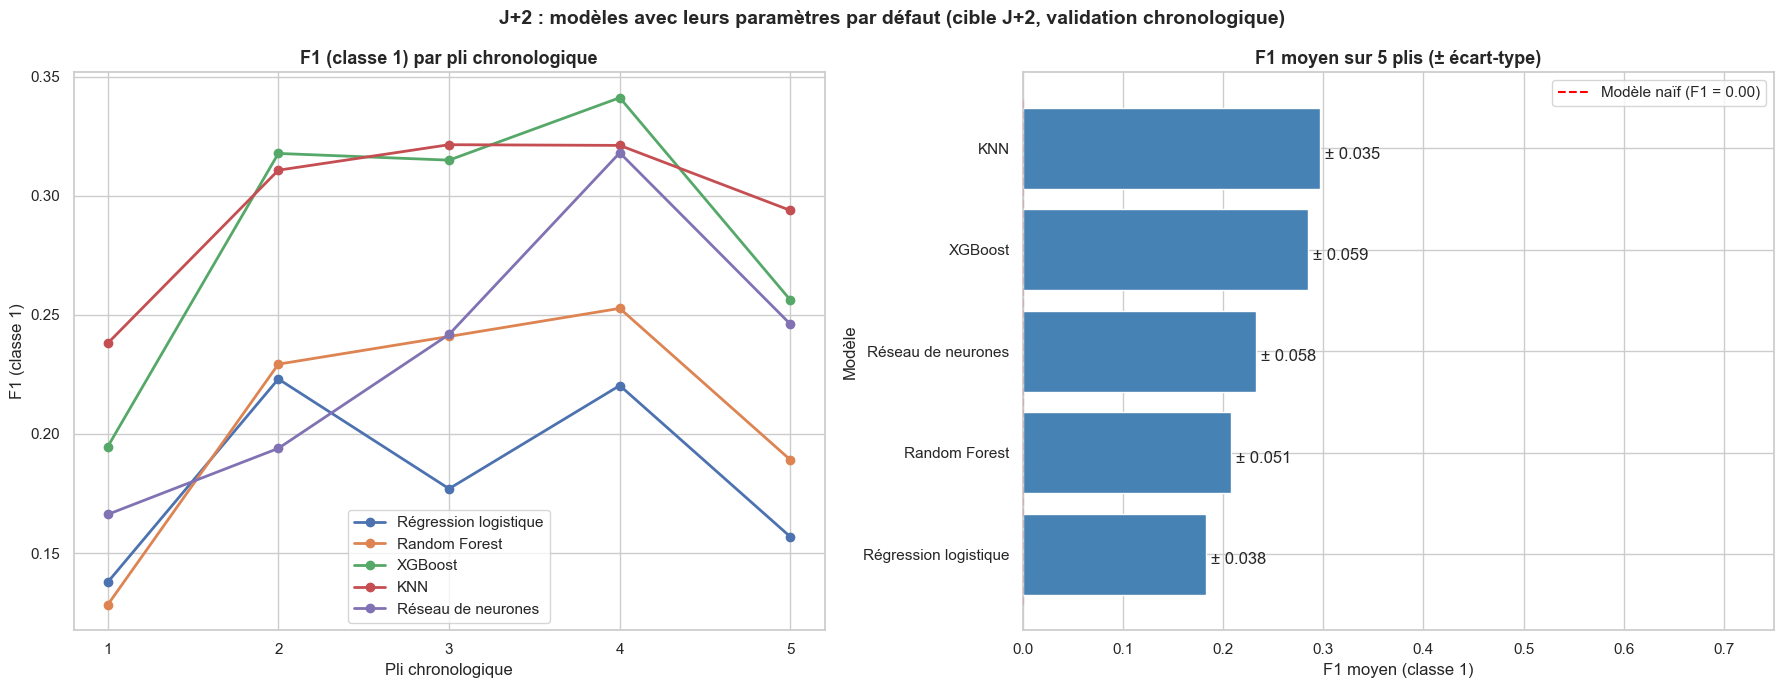

In [86]:
# CELL 86: J+2 : visualisation (paramètres par défaut)

f1_naif_J2 = table_naif_J2['F1'].mean()
plt.figure(figsize=(18, 7))

# Panneau 1 : F1 de chaque pli pour les 5 modèles
plt.subplot(1, 2, 1)
for nom in modeles:
    r = table_resultats_J2[table_resultats_J2['Modèle'] == nom]
    plt.plot(numeros_plis, r['F1'], marker='o', linewidth=2, label=nom)
plt.title("F1 (classe 1) par pli chronologique", fontsize=13, fontweight='bold')
plt.xlabel("Pli chronologique")
plt.ylabel("F1 (classe 1)")
plt.xticks(numeros_plis)
plt.legend()

# Panneau 2 : F1 moyen en barres horizontales (meilleur modèle en haut), écart-type au bout de chaque barre
recap_modeles = table_recap_J2[table_recap_J2['Modèle'] != 'Naïf (toujours pas de pluie)'].sort_values('F1 moyen')
plt.subplot(1, 2, 2)
plt.barh(recap_modeles['Modèle'], recap_modeles['F1 moyen'], color='steelblue')
for i in range(len(recap_modeles)):
    plt.text(recap_modeles['F1 moyen'].values[i] + 0.005, i - 0.1, f"± {recap_modeles['Écart-type F1'].values[i]:.3f}")
plt.plot([f1_naif_J2, f1_naif_J2], [-0.5, len(recap_modeles) - 0.5], color='red', linestyle='--',
         label=f"Modèle naïf (F1 = {f1_naif_J2:.2f})")
plt.title("F1 moyen sur 5 plis (± écart-type)", fontsize=13, fontweight='bold')
plt.xlabel("F1 moyen (classe 1)")
plt.ylabel("Modèle")
plt.xlim(0, 0.75)
plt.legend()

plt.suptitle("J+2 : modèles avec leurs paramètres par défaut (cible J+2, validation chronologique)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_10_modeles_par_defaut_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_10_modeles_par_defaut_J2.png")
plt.show()

In [87]:
# CELL 87: J+2 : SMOTENC sur la partie entraînement de chaque pli

# Colonne catégorielle RainToday ; SMOTENC ajusté et appliqué sur la partie entraînement de chaque pli uniquement,
# jamais sur la validation, une fois par jeu de données (mis à l'échelle ou non)
position_raintoday_J2 = list(X_train_scaled_J2.columns).index('RainToday')
print(f"Position de la colonne RainToday: {position_raintoday_J2}\n")
for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    smote_s = SMOTENC(categorical_features=[position_raintoday_J2], random_state=42)
    debut = time()
    Xs_tr_sm, ys_tr_sm = smote_s.fit_resample(d['Xs_tr'], d['y_tr'])
    duree_smote_s = time() - debut
    smote_a = SMOTENC(categorical_features=[position_raintoday_J2], random_state=42)
    debut = time()
    Xa_tr_sm, ya_tr_sm = smote_a.fit_resample(d['Xa_tr'], d['y_tr'])
    duree_smote_a = time() - debut
    d['Xs_tr_sm'] = Xs_tr_sm
    d['ys_tr_sm'] = ys_tr_sm
    d['Xa_tr_sm'] = Xa_tr_sm
    d['ya_tr_sm'] = ya_tr_sm
    d['duree_smote_a'] = duree_smote_a
    print(f"Pli {k + 1} | SMOTENC: {duree_smote_s:.2f} s (mises à l'échelle), {duree_smote_a:.2f} s (non mises à l'échelle) | "
          f"entraînement: {len(d['y_tr'])} -> {len(ys_tr_sm)} lignes, y = 1: {d['y_tr'].mean() * 100:.2f}% -> {ys_tr_sm.mean() * 100:.2f}%")

Position de la colonne RainToday: 9



Pli 1 | SMOTENC: 0.08 s (mises à l'échelle), 0.08 s (non mises à l'échelle) | entraînement: 4351 -> 7002 lignes, y = 1: 19.54% -> 50.00%


Pli 2 | SMOTENC: 1.23 s (mises à l'échelle), 1.29 s (non mises à l'échelle) | entraînement: 25617 -> 40188 lignes, y = 1: 21.56% -> 50.00%


Pli 3 | SMOTENC: 3.88 s (mises à l'échelle), 3.89 s (non mises à l'échelle) | entraînement: 46698 -> 71732 lignes, y = 1: 23.20% -> 50.00%


Pli 4 | SMOTENC: 8.70 s (mises à l'échelle), 8.80 s (non mises à l'échelle) | entraînement: 67908 -> 104820 lignes, y = 1: 22.82% -> 50.00%


Pli 5 | SMOTENC: 14.43 s (mises à l'échelle), 13.57 s (non mises à l'échelle) | entraînement: 90230 -> 139684 lignes, y = 1: 22.60% -> 50.00%


In [88]:
# CELL 88: J+2 : gestion du déséquilibre : régression logistique (aucune / class_weight='balanced' / SMOTENC)

resultats_deseq_J2 = []
for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # Pondération des classes
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000, class_weight='balanced'),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique', 'Option': "class_weight='balanced'",
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(LogisticRegression(max_iter=1000),
                                                                d['Xs_tr_sm'], d['ys_tr_sm'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Régression logistique', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Régression logistique | aucune | F1 = 0.1377 | précision = 0.4858 | rappel = 0.0802 | exactitude = 0.7792 | AUC = 0.6706 | entraînement 0.05 s | prédiction 0.00 s
Pli 1 | Régression logistique | class_weight='balanced' | F1 = 0.4175 | précision = 0.3337 | rappel = 0.5575 | exactitude = 0.6582 | AUC = 0.6712 | entraînement 0.05 s | prédiction 0.00 s


Pli 1 | Régression logistique | SMOTENC | F1 = 0.4016 | précision = 0.3239 | rappel = 0.5281 | exactitude = 0.6541 | AUC = 0.6608 | entraînement 0.07 s | prédiction 0.00 s


Pli 2 | Régression logistique | aucune | F1 = 0.2231 | précision = 0.5678 | rappel = 0.1388 | exactitude = 0.7565 | AUC = 0.6975 | entraînement 0.15 s | prédiction 0.00 s


Pli 2 | Régression logistique | class_weight='balanced' | F1 = 0.4718 | précision = 0.3676 | rappel = 0.6583 | exactitude = 0.6288 | AUC = 0.6992 | entraînement 0.07 s | prédiction 0.00 s


Pli 2 | Régression logistique | SMOTENC | F1 = 0.4724 | précision = 0.3696 | rappel = 0.6545 | exactitude = 0.6318 | AUC = 0.6989 | entraînement 0.18 s | prédiction 0.00 s


...

Pli 4 | Régression logistique | class_weight='balanced' | F1 = 0.4538 | précision = 0.3490 | rappel = 0.6483 | exactitude = 0.6581 | AUC = 0.7174 | entraînement 0.30 s | prédiction 0.00 s


Pli 4 | Régression logistique | SMOTENC | F1 = 0.4535 | précision = 0.3474 | rappel = 0.6528 | exactitude = 0.6553 | AUC = 0.7175 | entraînement 0.86 s | prédiction 0.00 s


Pli 5 | Régression logistique | aucune | F1 = 0.1568 | précision = 0.5238 | rappel = 0.0922 | exactitude = 0.7968 | AUC = 0.7083 | entraînement 0.59 s | prédiction 0.00 s


Pli 5 | Régression logistique | class_weight='balanced' | F1 = 0.4301 | précision = 0.3387 | rappel = 0.5891 | exactitude = 0.6801 | AUC = 0.7086 | entraînement 0.33 s | prédiction 0.00 s


Pli 5 | Régression logistique | SMOTENC | F1 = 0.4297 | précision = 0.3371 | rappel = 0.5922 | exactitude = 0.6778 | AUC = 0.7081 | entraînement 0.50 s | prédiction 0.00 s


In [89]:
# CELL 89: J+2 : gestion du déséquilibre : Random Forest (aucune / class_weight='balanced' / SMOTENC)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(RandomForestClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # Pondération des classes
    rf_pondere = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced')
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(rf_pondere, d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest', 'Option': "class_weight='balanced'",
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(RandomForestClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr_sm'], d['ya_tr_sm'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'Random Forest', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | Random Forest | aucune | F1 = 0.1282 | précision = 0.5287 | rappel = 0.0730 | exactitude = 0.7820 | AUC = 0.6809 | entraînement 0.21 s | prédiction 0.06 s


Pli 1 | Random Forest | class_weight='balanced' | F1 = 0.2474 | précision = 0.4376 | rappel = 0.1725 | exactitude = 0.7694 | AUC = 0.6857 | entraînement 0.24 s | prédiction 0.08 s


Pli 1 | Random Forest | SMOTENC | F1 = 0.2612 | précision = 0.4273 | rappel = 0.1881 | exactitude = 0.7662 | AUC = 0.6777 | entraînement 0.34 s | prédiction 0.10 s


Pli 2 | Random Forest | aucune | F1 = 0.2293 | précision = 0.5730 | rappel = 0.1433 | exactitude = 0.7574 | AUC = 0.7036 | entraînement 0.71 s | prédiction 0.13 s


Pli 2 | Random Forest | class_weight='balanced' | F1 = 0.4003 | précision = 0.4747 | rappel = 0.3460 | exactitude = 0.7389 | AUC = 0.7143 | entraînement 0.72 s | prédiction 0.10 s


...

Pli 4 | Random Forest | class_weight='balanced' | F1 = 0.4263 | précision = 0.4865 | rappel = 0.3793 | exactitude = 0.7763 | AUC = 0.7503 | entraînement 1.72 s | prédiction 0.14 s


Pli 4 | Random Forest | SMOTENC | F1 = 0.3229 | précision = 0.5241 | rappel = 0.2333 | exactitude = 0.7856 | AUC = 0.7402 | entraînement 3.95 s | prédiction 0.14 s


Pli 5 | Random Forest | aucune | F1 = 0.1891 | précision = 0.5641 | rappel = 0.1136 | exactitude = 0.8003 | AUC = 0.7285 | entraînement 2.56 s | prédiction 0.16 s


Pli 5 | Random Forest | class_weight='balanced' | F1 = 0.3640 | précision = 0.4632 | rappel = 0.2997 | exactitude = 0.7853 | AUC = 0.7372 | entraînement 2.40 s | prédiction 0.13 s


Pli 5 | Random Forest | SMOTENC | F1 = 0.2401 | précision = 0.5050 | rappel = 0.1575 | exactitude = 0.7957 | AUC = 0.7225 | entraînement 5.15 s | prédiction 0.10 s


In [90]:
# CELL 90: J+2 : gestion du déséquilibre : XGBoost (aucune / SMOTENC)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(XGBClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr'], d['y_tr'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'XGBoost', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(XGBClassifier(random_state=42, n_jobs=-1),
                                                                d['Xa_tr_sm'], d['ya_tr_sm'], d['Xa_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'XGBoost', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | XGBoost | aucune | F1 = 0.1946 | précision = 0.4196 | rappel = 0.1267 | exactitude = 0.7696 | AUC = 0.6401 | entraînement 0.20 s | prédiction 0.01 s


Pli 1 | XGBoost | SMOTENC | F1 = 0.2279 | précision = 0.4278 | rappel = 0.1554 | exactitude = 0.7687 | AUC = 0.6578 | entraînement 0.24 s | prédiction 0.01 s


Pli 2 | XGBoost | aucune | F1 = 0.3178 | précision = 0.4904 | rappel = 0.2351 | exactitude = 0.7458 | AUC = 0.6995 | entraînement 0.27 s | prédiction 0.02 s


Pli 2 | XGBoost | SMOTENC | F1 = 0.3329 | précision = 0.4930 | rappel = 0.2513 | exactitude = 0.7464 | AUC = 0.6950 | entraînement 0.41 s | prédiction 0.01 s


Pli 3 | XGBoost | aucune | F1 = 0.3150 | précision = 0.5283 | rappel = 0.2244 | exactitude = 0.7853 | AUC = 0.7387 | entraînement 0.36 s | prédiction 0.02 s


Pli 3 | XGBoost | SMOTENC | F1 = 0.3078 | précision = 0.5151 | rappel = 0.2195 | exactitude = 0.7828 | AUC = 0.7329 | entraînement 0.56 s | prédiction 0.01 s


Pli 4 | XGBoost | aucune | F1 = 0.3412 | précision = 0.5454 | rappel = 0.2483 | exactitude = 0.7900 | AUC = 0.7491 | entraînement 0.41 s | prédiction 0.02 s


Pli 4 | XGBoost | SMOTENC | F1 = 0.3436 | précision = 0.5317 | rappel = 0.2538 | exactitude = 0.7876 | AUC = 0.7475 | entraînement 0.69 s | prédiction 0.01 s


Pli 5 | XGBoost | aucune | F1 = 0.2562 | précision = 0.5192 | rappel = 0.1700 | exactitude = 0.7976 | AUC = 0.7377 | entraînement 0.56 s | prédiction 0.02 s


Pli 5 | XGBoost | SMOTENC | F1 = 0.2751 | précision = 0.5319 | rappel = 0.1855 | exactitude = 0.7996 | AUC = 0.7385 | entraînement 0.82 s | prédiction 0.01 s


In [91]:
# CELL 91: J+2 : gestion du déséquilibre : KNN (aucune / SMOTENC)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    # Aucune correction
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(KNeighborsClassifier(n_jobs=-1),
                                                                d['Xs_tr'], d['y_tr'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'KNN', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC (partie entraînement du pli rééchantillonnée)
    pred, proba_1, duree_fit, duree_pred = entrainer_et_predire(KNeighborsClassifier(n_jobs=-1),
                                                                d['Xs_tr_sm'], d['ys_tr_sm'], d['Xs_va'])
    ligne = {'Pli': k + 1, 'Modèle': 'KNN', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

Pli 1 | KNN | aucune | F1 = 0.2381 | précision = 0.3799 | rappel = 0.1733 | exactitude = 0.7562 | AUC = 0.6189 | entraînement 0.00 s | prédiction 0.11 s


Pli 1 | KNN | SMOTENC | F1 = 0.3846 | précision = 0.2872 | rappel = 0.5821 | exactitude = 0.5907 | AUC = 0.6132 | entraînement 0.01 s | prédiction 0.18 s


Pli 2 | KNN | aucune | F1 = 0.3108 | précision = 0.4246 | rappel = 0.2451 | exactitude = 0.7262 | AUC = 0.6420 | entraînement 0.01 s | prédiction 0.48 s


Pli 2 | KNN | SMOTENC | F1 = 0.4373 | précision = 0.3365 | rappel = 0.6242 | exactitude = 0.5954 | AUC = 0.6394 | entraînement 0.01 s | prédiction 0.74 s


Pli 3 | KNN | aucune | F1 = 0.3215 | précision = 0.4228 | rappel = 0.2593 | exactitude = 0.7592 | AUC = 0.6652 | entraînement 0.02 s | prédiction 0.89 s


Pli 3 | KNN | SMOTENC | F1 = 0.4237 | précision = 0.3206 | rappel = 0.6245 | exactitude = 0.6262 | AUC = 0.6648 | entraînement 0.03 s | prédiction 1.38 s


Pli 4 | KNN | aucune | F1 = 0.3212 | précision = 0.4218 | rappel = 0.2593 | exactitude = 0.7599 | AUC = 0.6657 | entraînement 0.02 s | prédiction 1.35 s


Pli 4 | KNN | SMOTENC | F1 = 0.4190 | précision = 0.3164 | rappel = 0.6200 | exactitude = 0.6232 | AUC = 0.6634 | entraînement 0.03 s | prédiction 2.29 s


Pli 5 | KNN | aucune | F1 = 0.2939 | précision = 0.4046 | rappel = 0.2307 | exactitude = 0.7728 | AUC = 0.6682 | entraînement 0.03 s | prédiction 1.86 s


Pli 5 | KNN | SMOTENC | F1 = 0.4022 | précision = 0.3031 | rappel = 0.5975 | exactitude = 0.6360 | AUC = 0.6655 | entraînement 0.05 s | prédiction 2.67 s


In [92]:
# CELL 92: J+2 : gestion du déséquilibre : réseau de neurones (aucune / SMOTENC)

for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    # Aucune correction
    reseau, duree_fit = entrainer_reseau(d['Xs_tr'].values, d['y_tr'].values, reseau_par_defaut)
    pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
    ligne = {'Pli': k + 1, 'Modèle': 'Réseau de neurones', 'Option': 'aucune',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))
    # SMOTENC : lignes mélangées pour que la validation interne de Keras ne contienne pas que des exemples synthétiques
    X_fit = d['Xs_tr_sm'].sample(frac=1, random_state=42)
    y_fit = d['ys_tr_sm'].loc[X_fit.index]
    reseau, duree_fit = entrainer_reseau(X_fit.values, y_fit.values, reseau_par_defaut)
    pred, proba_1, duree_pred = predire_reseau(reseau, d['Xs_va'].values)
    ligne = {'Pli': k + 1, 'Modèle': 'Réseau de neurones', 'Option': 'SMOTENC',
             'Temps entraînement (s)': duree_fit, 'Temps prédiction (s)': duree_pred}
    resultats_deseq_J2.append(mesurer(ligne, d['y_va'], pred, proba_1))

table_deseq_J2 = pd.DataFrame(resultats_deseq_J2)

Pli 1 | Réseau de neurones | aucune | F1 = 0.1662 | précision = 0.5156 | rappel = 0.0991 | exactitude = 0.7816 | AUC = 0.6782 | entraînement 2.63 s | prédiction 0.72 s


Pli 1 | Réseau de neurones | SMOTENC | F1 = 0.3558 | précision = 0.3541 | rappel = 0.3576 | exactitude = 0.7155 | AUC = 0.6522 | entraînement 10.00 s | prédiction 0.78 s


Pli 2 | Réseau de neurones | aucune | F1 = 0.1940 | précision = 0.5814 | rappel = 0.1164 | exactitude = 0.7564 | AUC = 0.7258 | entraînement 7.12 s | prédiction 0.80 s


Pli 2 | Réseau de neurones | SMOTENC | F1 = 0.4567 | précision = 0.3982 | rappel = 0.5355 | exactitude = 0.6792 | AUC = 0.6913 | entraînement 46.10 s | prédiction 0.79 s


Pli 3 | Réseau de neurones | aucune | F1 = 0.2418 | précision = 0.5502 | rappel = 0.1550 | exactitude = 0.7862 | AUC = 0.7445 | entraînement 12.55 s | prédiction 0.82 s


Pli 3 | Réseau de neurones | SMOTENC | F1 = 0.4396 | précision = 0.3576 | rappel = 0.5705 | exactitude = 0.6800 | AUC = 0.7031 | entraînement 80.21 s | prédiction 0.84 s


Pli 4 | Réseau de neurones | aucune | F1 = 0.3181 | précision = 0.5416 | rappel = 0.2252 | exactitude = 0.7885 | AUC = 0.7350 | entraînement 10.89 s | prédiction 0.82 s


Pli 4 | Réseau de neurones | SMOTENC | F1 = 0.4627 | précision = 0.3979 | rappel = 0.5528 | exactitude = 0.7188 | AUC = 0.7280 | entraînement 114.80 s | prédiction 0.83 s


Pli 5 | Réseau de neurones | aucune | F1 = 0.2461 | précision = 0.5083 | rappel = 0.1623 | exactitude = 0.7961 | AUC = 0.7360 | entraînement 36.72 s | prédiction 1.31 s


Pli 5 | Réseau de neurones | SMOTENC | F1 = 0.4278 | précision = 0.3483 | rappel = 0.5545 | exactitude = 0.6961 | AUC = 0.7070 | entraînement 153.40 s | prédiction 0.75 s


In [93]:
# CELL 93: J+2 : récapitulatif des stratégies de gestion du déséquilibre

# Mêmes options par modèle que J+1 (options_modele, CELL 24)
lignes_deseq_J2 = []
for nom in modeles:
    for option in options_modele[nom]:
        r = table_deseq_J2[(table_deseq_J2['Modèle'] == nom) & (table_deseq_J2['Option'] == option)]
        lignes_deseq_J2.append({'Modèle': nom, 'Option': option, 'F1 moyen': r['F1'].mean(), 'Écart-type F1': r['F1'].std(),
                                'Précision moyenne': r['Précision'].mean(), 'Rappel moyen': r['Rappel'].mean(),
                                'AUC moyenne': r['AUC'].mean(), 'Temps entraînement moyen (s)': r['Temps entraînement (s)'].mean()})
table_recap_deseq_J2 = pd.DataFrame(lignes_deseq_J2)

# Affichage : F1 moyen en pleine précision, 4 décimales pour les autres colonnes
table_affichage_deseq = table_recap_deseq_J2.copy()
f1_texte = []
for v in table_recap_deseq_J2['F1 moyen'].values:
    f1_texte.append(str(v))
table_affichage_deseq['F1 moyen'] = f1_texte
for col in ['Écart-type F1', 'Précision moyenne', 'Rappel moyen', 'AUC moyenne', 'Temps entraînement moyen (s)']:
    valeurs_arrondies = []
    for v in table_recap_deseq_J2[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_deseq[col] = valeurs_arrondies
print("J+2, stratégies de gestion du déséquilibre, validation chronologique sur 5 plis:")
print(table_affichage_deseq)

J+2, stratégies de gestion du déséquilibre, validation chronologique sur 5 plis:
                   Modèle                   Option             F1 moyen  Écart-type F1  Précision moyenne  Rappel moyen  AUC moyenne  Temps entraînement moyen (s)
0   Régression logistique                   aucune  0.18299921406398606         0.0380             0.5267        0.1114       0.7019                        0.2523
1   Régression logistique  class_weight='balanced'  0.44516053869625394         0.0214             0.3501        0.6117       0.7024                        0.1894
2   Régression logistique                  SMOTENC   0.4418164818045132         0.0271             0.3478        0.6064       0.6999                        0.3780
3           Random Forest                   aucune  0.20807013101881583         0.0506             0.5756        0.1280       0.7175                        1.2945
4           Random Forest  class_weight='balanced'  0.36682338162569633         0.0703             0.468

In [94]:
# CELL 94: J+2 : règle de décision : option de déséquilibre retenue par modèle

# Même règle que J+1 : pour chaque modèle, on retient l'option qui a le F1 moyen le plus élevé sur les 5 plis
# (valeurs non arrondies) ; en cas d'égalité, on retient l'option la plus simple (aucune, rangée en premier)
strategie_retenue_J2 = {}
print("\nJ+2, option retenue par modèle:")
for nom in modeles:
    r = table_recap_deseq_J2[table_recap_deseq_J2['Modèle'] == nom]
    f1_max = r['F1 moyen'].max()
    option = r[r['F1 moyen'] == f1_max]['Option'].values[0]
    strategie_retenue_J2[nom] = option
    f1_aucune = r[r['Option'] == 'aucune']['F1 moyen'].values[0]
    print(f"  {nom}: {option} (F1 moyen = {f1_max:.4f} | sans correction = {f1_aucune:.4f} | "
          f"écart = {f1_max - f1_aucune:+.4f})")
print(f"\nstrategie_retenue_J2 = {strategie_retenue_J2}")


J+2, option retenue par modèle:
  Régression logistique: class_weight='balanced' (F1 moyen = 0.4452 | sans correction = 0.1830 | écart = +0.2622)
  Random Forest: class_weight='balanced' (F1 moyen = 0.3668 | sans correction = 0.2081 | écart = +0.1588)
  XGBoost: SMOTENC (F1 moyen = 0.2974 | sans correction = 0.2850 | écart = +0.0125)
  KNN: SMOTENC (F1 moyen = 0.4133 | sans correction = 0.2971 | écart = +0.1163)
  Réseau de neurones: SMOTENC (F1 moyen = 0.4285 | sans correction = 0.2332 | écart = +0.1953)

strategie_retenue_J2 = {'Régression logistique': "class_weight='balanced'", 'Random Forest': "class_weight='balanced'", 'XGBoost': 'SMOTENC', 'KNN': 'SMOTENC', 'Réseau de neurones': 'SMOTENC'}


Figure sauvegardée: figures/etape3_11_desequilibre_J2.png


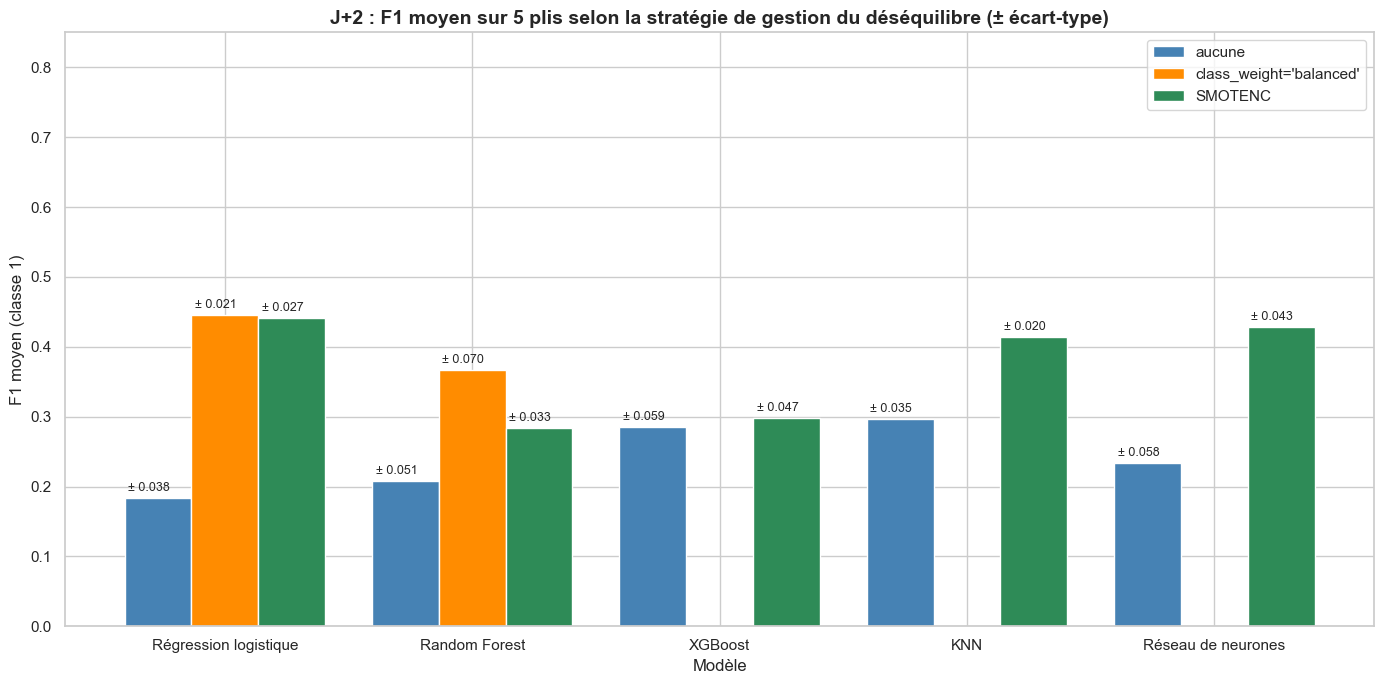

In [95]:
# CELL 95: J+2 : visualisation des stratégies de gestion du déséquilibre

# Une barre par option (fonction barres_option, CELL 27) ; pas de barre class_weight='balanced'
# pour XGBoost, KNN et le réseau de neurones (option non testée)
plt.figure(figsize=(14, 7))
barres_option(table_recap_deseq_J2, 'aucune', -largeur, 'steelblue')
barres_option(table_recap_deseq_J2, "class_weight='balanced'", 0, 'darkorange')
barres_option(table_recap_deseq_J2, 'SMOTENC', largeur, 'seagreen')
plt.title("J+2 : F1 moyen sur 5 plis selon la stratégie de gestion du déséquilibre (± écart-type)",
          fontsize=14, fontweight='bold')
plt.xlabel("Modèle")
plt.ylabel("F1 moyen (classe 1)")
plt.xticks(positions, modeles)
plt.ylim(0, 0.85)
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape3_11_desequilibre_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_11_desequilibre_J2.png")
plt.show()

In [96]:
# CELL 96: J+2 : données SMOTENC des plis réutilisées pour XGBoost

# Mêmes grilles que J+1 (CELL 29) ; données non mises à l'échelle rééchantillonnées en CELL 87
for k in range(len(plis_J2)):
    d = donnees_plis_J2[k]
    print(f"Pli {k + 1} | SMOTENC ({d['duree_smote_a']:.2f} s): entraînement {len(d['y_tr'])} -> {len(d['ya_tr_sm'])} lignes, "
          f"y = 1: {d['y_tr'].mean() * 100:.2f}% -> {d['ya_tr_sm'].mean() * 100:.2f}%")

Pli 1 | SMOTENC (0.08 s): entraînement 4351 -> 7002 lignes, y = 1: 19.54% -> 50.00%
Pli 2 | SMOTENC (1.29 s): entraînement 25617 -> 40188 lignes, y = 1: 21.56% -> 50.00%
Pli 3 | SMOTENC (3.89 s): entraînement 46698 -> 71732 lignes, y = 1: 23.20% -> 50.00%
Pli 4 | SMOTENC (8.80 s): entraînement 67908 -> 104820 lignes, y = 1: 22.82% -> 50.00%
Pli 5 | SMOTENC (13.57 s): entraînement 90230 -> 139684 lignes, y = 1: 22.60% -> 50.00%


In [97]:
# CELL 97: J+2 : recherche des hyperparamètres : Random Forest (class_weight='balanced', non mises à l'échelle)

ignorer_avertissements()

# Options retenues en J+2 (CELL 94) : Random Forest avec class_weight='balanced' et XGBoost avec SMOTENC
# (les mêmes qu'en J+1), réseau de neurones avec son option J+2 (CELL 99) ; une colonne par combinaison
f1_par_combinaison = {}
durees_par_combinaison = {}
for c in combinaisons_rf:
    f1_par_combinaison[c['texte']] = []
    durees_par_combinaison[c['texte']] = []
    for k in range(len(plis_J2)):
        d = donnees_plis_J2[k]
        modele = RandomForestClassifier(n_estimators=c['parametres']['n_estimators'], max_depth=c['parametres']['max_depth'],
                                        class_weight='balanced', random_state=42, n_jobs=-1)
        debut = time()
        modele.fit(d['Xa_tr'], d['y_tr'])
        durees_par_combinaison[c['texte']].append(time() - debut)
        f1_par_combinaison[c['texte']].append(f1_score(d['y_va'], modele.predict(d['Xa_va'])))
lignes_rf_J2 = enregistrer_grille('Random Forest', combinaisons_rf, pd.DataFrame(f1_par_combinaison),
                                  pd.DataFrame(durees_par_combinaison))

Random Forest | n_estimators=100, max_depth=10 | F1 moyen = 0.4518 | écart-type = 0.0568 | entraînement 0.82 s
Random Forest | n_estimators=100, max_depth=20 | F1 moyen = 0.3896 | écart-type = 0.0839 | entraînement 1.16 s
Random Forest | n_estimators=100, max_depth=30 | F1 moyen = 0.3709 | écart-type = 0.0705 | entraînement 1.28 s
Random Forest | n_estimators=200, max_depth=10 | F1 moyen = 0.4500 | écart-type = 0.0612 | entraînement 1.61 s
Random Forest | n_estimators=200, max_depth=20 | F1 moyen = 0.3904 | écart-type = 0.0827 | entraînement 2.37 s
Random Forest | n_estimators=200, max_depth=30 | F1 moyen = 0.3711 | écart-type = 0.0738 | entraînement 2.56 s
Random Forest | n_estimators=300, max_depth=10 | F1 moyen = 0.4523 | écart-type = 0.0572 | entraînement 2.49 s
Random Forest | n_estimators=300, max_depth=20 | F1 moyen = 0.3908 | écart-type = 0.0816 | entraînement 3.52 s
Random Forest | n_estimators=300, max_depth=30 | F1 moyen = 0.3712 | écart-type = 0.0751 | entraînement 3.59 s


In [98]:
# CELL 98: J+2 : recherche des hyperparamètres : XGBoost (SMOTENC, données non mises à l'échelle)

f1_par_combinaison = {}
durees_par_combinaison = {}
for c in combinaisons_xgb:
    f1_par_combinaison[c['texte']] = []
    durees_par_combinaison[c['texte']] = []
    for k in range(len(plis_J2)):
        d = donnees_plis_J2[k]
        modele = XGBClassifier(n_estimators=c['parametres']['n_estimators'], learning_rate=c['parametres']['learning_rate'],
                               max_depth=c['parametres']['max_depth'], random_state=42, n_jobs=-1)
        debut = time()
        modele.fit(d['Xa_tr_sm'], d['ya_tr_sm'])
        durees_par_combinaison[c['texte']].append(time() - debut)
        f1_par_combinaison[c['texte']].append(f1_score(d['y_va'], modele.predict(d['Xa_va'])))
print()
lignes_xgb_J2 = enregistrer_grille('XGBoost', combinaisons_xgb, pd.DataFrame(f1_par_combinaison),
                                   pd.DataFrame(durees_par_combinaison))


XGBoost | n_estimators=100, learning_rate=0.05, max_depth=3 | F1 moyen = 0.3516 | écart-type = 0.0270 | entraînement 0.33 s
XGBoost | n_estimators=100, learning_rate=0.05, max_depth=6 | F1 moyen = 0.3039 | écart-type = 0.0291 | entraînement 0.55 s
XGBoost | n_estimators=100, learning_rate=0.05, max_depth=9 | F1 moyen = 0.3067 | écart-type = 0.0313 | entraînement 1.18 s
XGBoost | n_estimators=100, learning_rate=0.05, max_depth=12 | F1 moyen = 0.3062 | écart-type = 0.0324 | entraînement 2.71 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=3 | F1 moyen = 0.2989 | écart-type = 0.0387 | entraînement 0.33 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=6 | F1 moyen = 0.2846 | écart-type = 0.0353 | entraînement 0.52 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=9 | F1 moyen = 0.2958 | écart-type = 0.0379 | entraînement 1.21 s
XGBoost | n_estimators=100, learning_rate=0.1, max_depth=12 | F1 moyen = 0.3041 | écart-type = 0.0430 | entraînement 2.39 s
XGBoost |

In [99]:
# CELL 99: J+2 : recherche des hyperparamètres : réseau de neurones (option retenue en J+2, mises à l'échelle)

# Option de déséquilibre retenue pour le réseau en J+2 (CELL 94) ; avec SMOTENC, lignes mélangées pour que
# la validation interne de Keras ne contienne pas que des exemples synthétiques. Données d'entraînement préparées une fois par pli.
option_reseau_J2 = strategie_retenue_J2['Réseau de neurones']
donnees_reseau_J2 = []
for k in range(len(plis_J2)):
    X_fit, y_fit = donnees_selon_option(donnees_plis_J2[k], option_reseau_J2, True)
    if option_reseau_J2 == 'SMOTENC':
        X_fit = X_fit.sample(frac=1, random_state=42)
        y_fit = y_fit.loc[X_fit.index]
    donnees_reseau_J2.append([X_fit.values, y_fit.values])

# F1 et durée de chaque pli : une colonne par combinaison
f1_par_combinaison = {}
durees_par_combinaison = {}
for c in combinaisons_reseau:
    f1_par_combinaison[c['texte']] = []
    durees_par_combinaison[c['texte']] = []
    for k in range(len(plis_J2)):
        reseau, duree_fit = entrainer_reseau(donnees_reseau_J2[k][0], donnees_reseau_J2[k][1], c['parametres'])
        pred, proba_1, duree_pred = predire_reseau(reseau, donnees_plis_J2[k]['Xs_va'].values)
        durees_par_combinaison[c['texte']].append(duree_fit)
        f1_par_combinaison[c['texte']].append(f1_score(donnees_plis_J2[k]['y_va'], pred))
print()
lignes_reseau_J2 = enregistrer_grille('Réseau de neurones', combinaisons_reseau, pd.DataFrame(f1_par_combinaison),
                                      pd.DataFrame(durees_par_combinaison))
table_grille_J2 = pd.DataFrame(lignes_rf_J2 + lignes_xgb_J2 + lignes_reseau_J2)


Réseau de neurones | couches=(64, 32), dropout=0 | F1 moyen = 0.4285 | écart-type = 0.0429 | entraînement 79.43 s
Réseau de neurones | couches=(64, 32), dropout=0.2 | F1 moyen = 0.4586 | écart-type = 0.0390 | entraînement 62.88 s
Réseau de neurones | couches=(128, 64), dropout=0 | F1 moyen = 0.4043 | écart-type = 0.0597 | entraînement 71.02 s
Réseau de neurones | couches=(128, 64), dropout=0.2 | F1 moyen = 0.4373 | écart-type = 0.0623 | entraînement 208.53 s


In [100]:
# CELL 100: J+2 : récapitulatif et règle de décision des 3 grilles

# Même règle que J+1 : pour chaque modèle, on retient la combinaison qui a le F1 moyen le plus élevé sur les 5 plis
# (valeurs non arrondies) ; si aucune combinaison ne dépasse le F1 moyen des paramètres par défaut avec l'option
# retenue (CELL 94), on garde les paramètres par défaut. Régression logistique et KNN : paramètres par défaut.
parametres_retenus_J2 = {'Régression logistique': parametres_defaut['Régression logistique'], 'KNN': parametres_defaut['KNN']}
etape_J2 = {'table_grille': table_grille_J2, 'table_recap_deseq': table_recap_deseq_J2,
            'strategie': strategie_retenue_J2, 'parametres_retenus': parametres_retenus_J2}
r = afficher_grille(etape_J2, 'Random Forest')
retenir_combinaison(etape_J2, 'Random Forest', r)
r = afficher_grille(etape_J2, 'XGBoost')
retenir_combinaison(etape_J2, 'XGBoost', r)
r = afficher_grille(etape_J2, 'Réseau de neurones')
retenir_combinaison(etape_J2, 'Réseau de neurones', r)

print("parametres_retenus_J2:")
for nom in modeles:
    print(f"  {nom}: {parametres_retenus_J2[nom]}")

Random Forest (class_weight='balanced'), combinaisons triées par F1 moyen décroissant:
                      Combinaison             F1 moyen  Écart-type F1  Temps entraînement moyen (s)
0  n_estimators=300, max_depth=10  0.45228584888412754         0.0572                        2.4937
1  n_estimators=100, max_depth=10   0.4517504513094461         0.0568                        0.8235
2  n_estimators=200, max_depth=10    0.450024151434112         0.0612                        1.6063
3  n_estimators=300, max_depth=20   0.3908102814072698         0.0816                        3.5224
4  n_estimators=200, max_depth=20  0.39041148977064694         0.0827                        2.3652
5  n_estimators=100, max_depth=20  0.38964414516484036         0.0839                        1.1626
6  n_estimators=300, max_depth=30  0.37123992122113564         0.0751                        3.5850
7  n_estimators=200, max_depth=30   0.3710804564906194         0.0738                        2.5587
8  n_estimato

Figure sauvegardée: figures/etape3_12_hyperparametres_J2.png


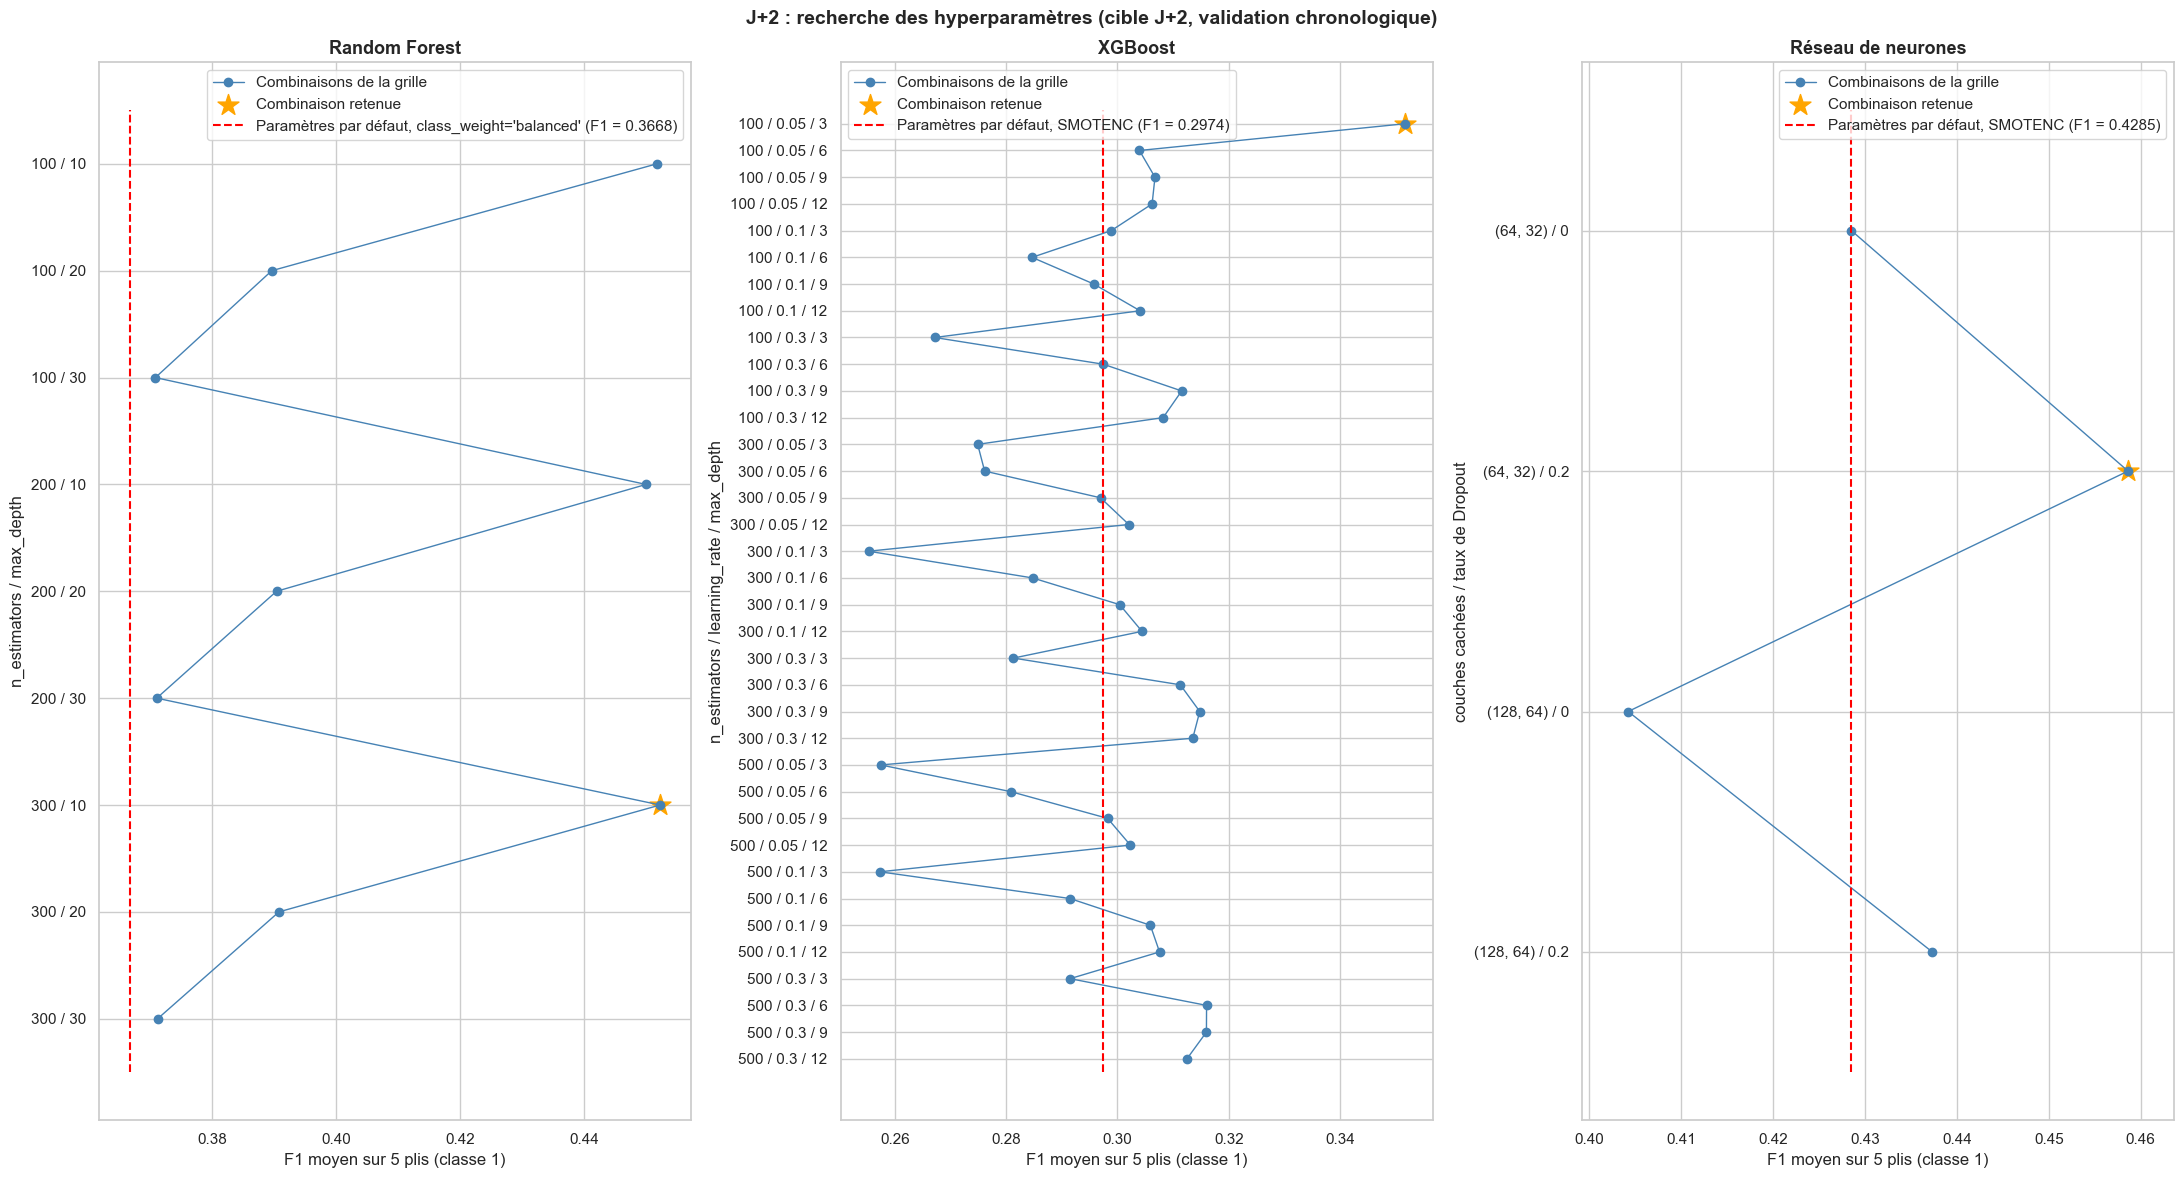

In [101]:
# CELL 101: J+2 : visualisation de la recherche des hyperparamètres

plt.figure(figsize=(22, 12))
panneau_grille(etape_J2, 1, 'Random Forest', 'n_estimators / max_depth')
panneau_grille(etape_J2, 2, 'XGBoost', 'n_estimators / learning_rate / max_depth')
panneau_grille(etape_J2, 3, 'Réseau de neurones', 'couches cachées / taux de Dropout')
plt.suptitle("J+2 : recherche des hyperparamètres (cible J+2, validation chronologique)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_12_hyperparametres_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_12_hyperparametres_J2.png")
plt.show()

In [102]:
# CELL 102: J+2 : probabilités de validation : régression logistique (paramètres et option retenus)

# Pour chaque modèle (paramètres retenus en CELL 100, option retenue en CELL 94)
# et chaque pli : probabilité de la classe 1 sur la partie validation
probas_plis_J2 = {}
p = parametres_retenus_J2['Régression logistique']
option = strategie_retenue_J2['Régression logistique']
probas_plis_J2['Régression logistique'] = []
for k in range(len(plis_J2)):
    X_fit, y_fit = donnees_selon_option(donnees_plis_J2[k], option, True)
    modele = LogisticRegression(max_iter=p['max_iter'], class_weight=poids_selon_option(option))
    modele.fit(X_fit, y_fit)
    probas_plis_J2['Régression logistique'].append(modele.predict_proba(donnees_plis_J2[k]['Xs_va'])[:, 1])

In [103]:
# CELL 103: J+2 : probabilités de validation : Random Forest (paramètres et option retenus)

p = parametres_retenus_J2['Random Forest']
option = strategie_retenue_J2['Random Forest']
probas_plis_J2['Random Forest'] = []
for k in range(len(plis_J2)):
    X_fit, y_fit = donnees_selon_option(donnees_plis_J2[k], option, False)
    modele = RandomForestClassifier(n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                                    class_weight=poids_selon_option(option), random_state=42, n_jobs=-1)
    modele.fit(X_fit, y_fit)
    probas_plis_J2['Random Forest'].append(modele.predict_proba(donnees_plis_J2[k]['Xa_va'])[:, 1])

In [104]:
# CELL 104: J+2 : probabilités de validation : XGBoost (paramètres et option retenus)

p = parametres_retenus_J2['XGBoost']
option = strategie_retenue_J2['XGBoost']
probas_plis_J2['XGBoost'] = []
for k in range(len(plis_J2)):
    X_fit, y_fit = donnees_selon_option(donnees_plis_J2[k], option, False)
    modele = XGBClassifier(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                           max_depth=p['max_depth'], random_state=42, n_jobs=-1)
    modele.fit(X_fit, y_fit)
    probas_plis_J2['XGBoost'].append(modele.predict_proba(donnees_plis_J2[k]['Xa_va'])[:, 1])

In [105]:
# CELL 105: J+2 : probabilités de validation : KNN (paramètres et option retenus)

p = parametres_retenus_J2['KNN']
option = strategie_retenue_J2['KNN']
probas_plis_J2['KNN'] = []
for k in range(len(plis_J2)):
    X_fit, y_fit = donnees_selon_option(donnees_plis_J2[k], option, True)
    modele = KNeighborsClassifier(n_neighbors=p['n_neighbors'], n_jobs=-1)
    modele.fit(X_fit, y_fit)
    probas_plis_J2['KNN'].append(modele.predict_proba(donnees_plis_J2[k]['Xs_va'])[:, 1])

In [106]:
# CELL 106: J+2 : probabilités de validation : réseau de neurones (paramètres et option retenus)

p = parametres_retenus_J2['Réseau de neurones']
option = strategie_retenue_J2['Réseau de neurones']
probas_plis_J2['Réseau de neurones'] = []
for k in range(len(plis_J2)):
    X_fit, y_fit = donnees_selon_option(donnees_plis_J2[k], option, True)
    if option == 'SMOTENC':
        # Même mélange que pour J+1 : la validation interne ne doit pas contenir que des exemples synthétiques
        X_fit = X_fit.sample(frac=1, random_state=42)
        y_fit = y_fit.loc[X_fit.index]
    reseau, duree_fit = entrainer_reseau(X_fit.values, y_fit.values, p)
    pred, proba_1, duree_pred = predire_reseau(reseau, donnees_plis_J2[k]['Xs_va'].values)
    probas_plis_J2['Réseau de neurones'].append(proba_1)
    print(f"Pli {k + 1}: probabilités de la classe 1 calculées pour les 5 modèles")

Pli 1: probabilités de la classe 1 calculées pour les 5 modèles


Pli 2: probabilités de la classe 1 calculées pour les 5 modèles


Pli 3: probabilités de la classe 1 calculées pour les 5 modèles


Pli 4: probabilités de la classe 1 calculées pour les 5 modèles


Pli 5: probabilités de la classe 1 calculées pour les 5 modèles


In [107]:
# CELL 107: J+2 : optimisation du seuil de probabilité (validation croisée chronologique)

# Même règle que J+1 : seuils np.arange(0, 1, 0.001), F1 moyen sur les 5 plis pour chaque seuil,
# seuil retenu = celui qui maximise le F1 moyen (np.argmax)
courbes_seuils_J2 = {}
resultats_seuils_J2 = []
for nom in modeles:
    f1_moyens = []
    precisions_moyennes = []
    rappels_moyens = []
    for seuil in seuils:
        f1, precision, rappel = scores_moyens(probas_plis_J2[nom], y_va_plis_J2, seuil)
        f1_moyens.append(f1)
        precisions_moyennes.append(precision)
        rappels_moyens.append(rappel)
    courbes_seuils_J2[nom] = {'F1': f1_moyens, 'Précision': precisions_moyennes, 'Rappel': rappels_moyens}
    i_max = np.argmax(f1_moyens)
    f1_05, precision_05, rappel_05 = scores_moyens(probas_plis_J2[nom], y_va_plis_J2, 0.5)
    resultats_seuils_J2.append({'Modèle': nom, 'Seuil retenu': round(seuils[i_max], 3),
                                'F1 moyen (seuil retenu)': f1_moyens[i_max], 'F1 moyen (seuil 0,5)': f1_05,
                                'Précision moyenne (seuil retenu)': precisions_moyennes[i_max],
                                'Rappel moyen (seuil retenu)': rappels_moyens[i_max],
                                'Précision moyenne (seuil 0,5)': precision_05, 'Rappel moyen (seuil 0,5)': rappel_05})
    print(f"{nom} | seuil retenu = {seuils[i_max]:.3f} | F1 moyen = {f1_moyens[i_max]:.4f} (seuil 0,5: {f1_05:.4f})")

Régression logistique | seuil retenu = 0.468 | F1 moyen = 0.4478 (seuil 0,5: 0.4452)


Random Forest | seuil retenu = 0.461 | F1 moyen = 0.4581 (seuil 0,5: 0.4523)


XGBoost | seuil retenu = 0.373 | F1 moyen = 0.4382 (seuil 0,5: 0.3516)


KNN | seuil retenu = 0.201 | F1 moyen = 0.4197 (seuil 0,5: 0.4133)


Réseau de neurones | seuil retenu = 0.459 | F1 moyen = 0.4621 (seuil 0,5: 0.4586)


In [108]:
# CELL 108: J+2 : récapitulatif des seuils

table_seuils_J2 = pd.DataFrame(resultats_seuils_J2)
table_seuils_J2['Différence F1'] = table_seuils_J2['F1 moyen (seuil retenu)'] - table_seuils_J2['F1 moyen (seuil 0,5)']
table_seuils_J2 = table_seuils_J2[['Modèle', 'Seuil retenu', 'F1 moyen (seuil retenu)', 'F1 moyen (seuil 0,5)',
                                   'Différence F1', 'Précision moyenne (seuil retenu)', 'Rappel moyen (seuil retenu)',
                                   'Précision moyenne (seuil 0,5)', 'Rappel moyen (seuil 0,5)']]
table_affichage_seuils = table_seuils_J2.copy()
f1_texte = []
for v in table_seuils_J2['F1 moyen (seuil retenu)'].values:
    f1_texte.append(str(v))
table_affichage_seuils['F1 moyen (seuil retenu)'] = f1_texte
for col in ['F1 moyen (seuil 0,5)', 'Différence F1', 'Précision moyenne (seuil retenu)', 'Rappel moyen (seuil retenu)',
            'Précision moyenne (seuil 0,5)', 'Rappel moyen (seuil 0,5)']:
    valeurs_arrondies = []
    for v in table_seuils_J2[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_seuils[col] = valeurs_arrondies
print("J+2, seuil de probabilité retenu par modèle (F1 moyen maximal sur les 5 plis de validation):")
print(table_affichage_seuils)

seuil_retenu_J2 = {}
for i in range(len(table_seuils_J2)):
    seuil_retenu_J2[table_seuils_J2['Modèle'].values[i]] = table_seuils_J2['Seuil retenu'].values[i]
print(f"\nseuil_retenu_J2 = {seuil_retenu_J2}")

J+2, seuil de probabilité retenu par modèle (F1 moyen maximal sur les 5 plis de validation):
                  Modèle  Seuil retenu F1 moyen (seuil retenu)  F1 moyen (seuil 0,5)  Différence F1  Précision moyenne (seuil retenu)  Rappel moyen (seuil retenu)  Précision moyenne (seuil 0,5)  \
0  Régression logistique         0.468     0.44775900145331116                0.4452         0.0026                            0.3356                       0.6731                         0.3501   
1          Random Forest         0.461     0.45814904816032553                0.4523         0.0059                            0.3554                       0.6633                         0.3848   
2                XGBoost         0.373     0.43821896333102195                0.3516         0.0866                            0.3289                       0.6570                         0.4165   
3                    KNN         0.201      0.4196914164353469                0.4133         0.0063                    

Figure sauvegardée: figures/etape3_13_seuils_J2.png


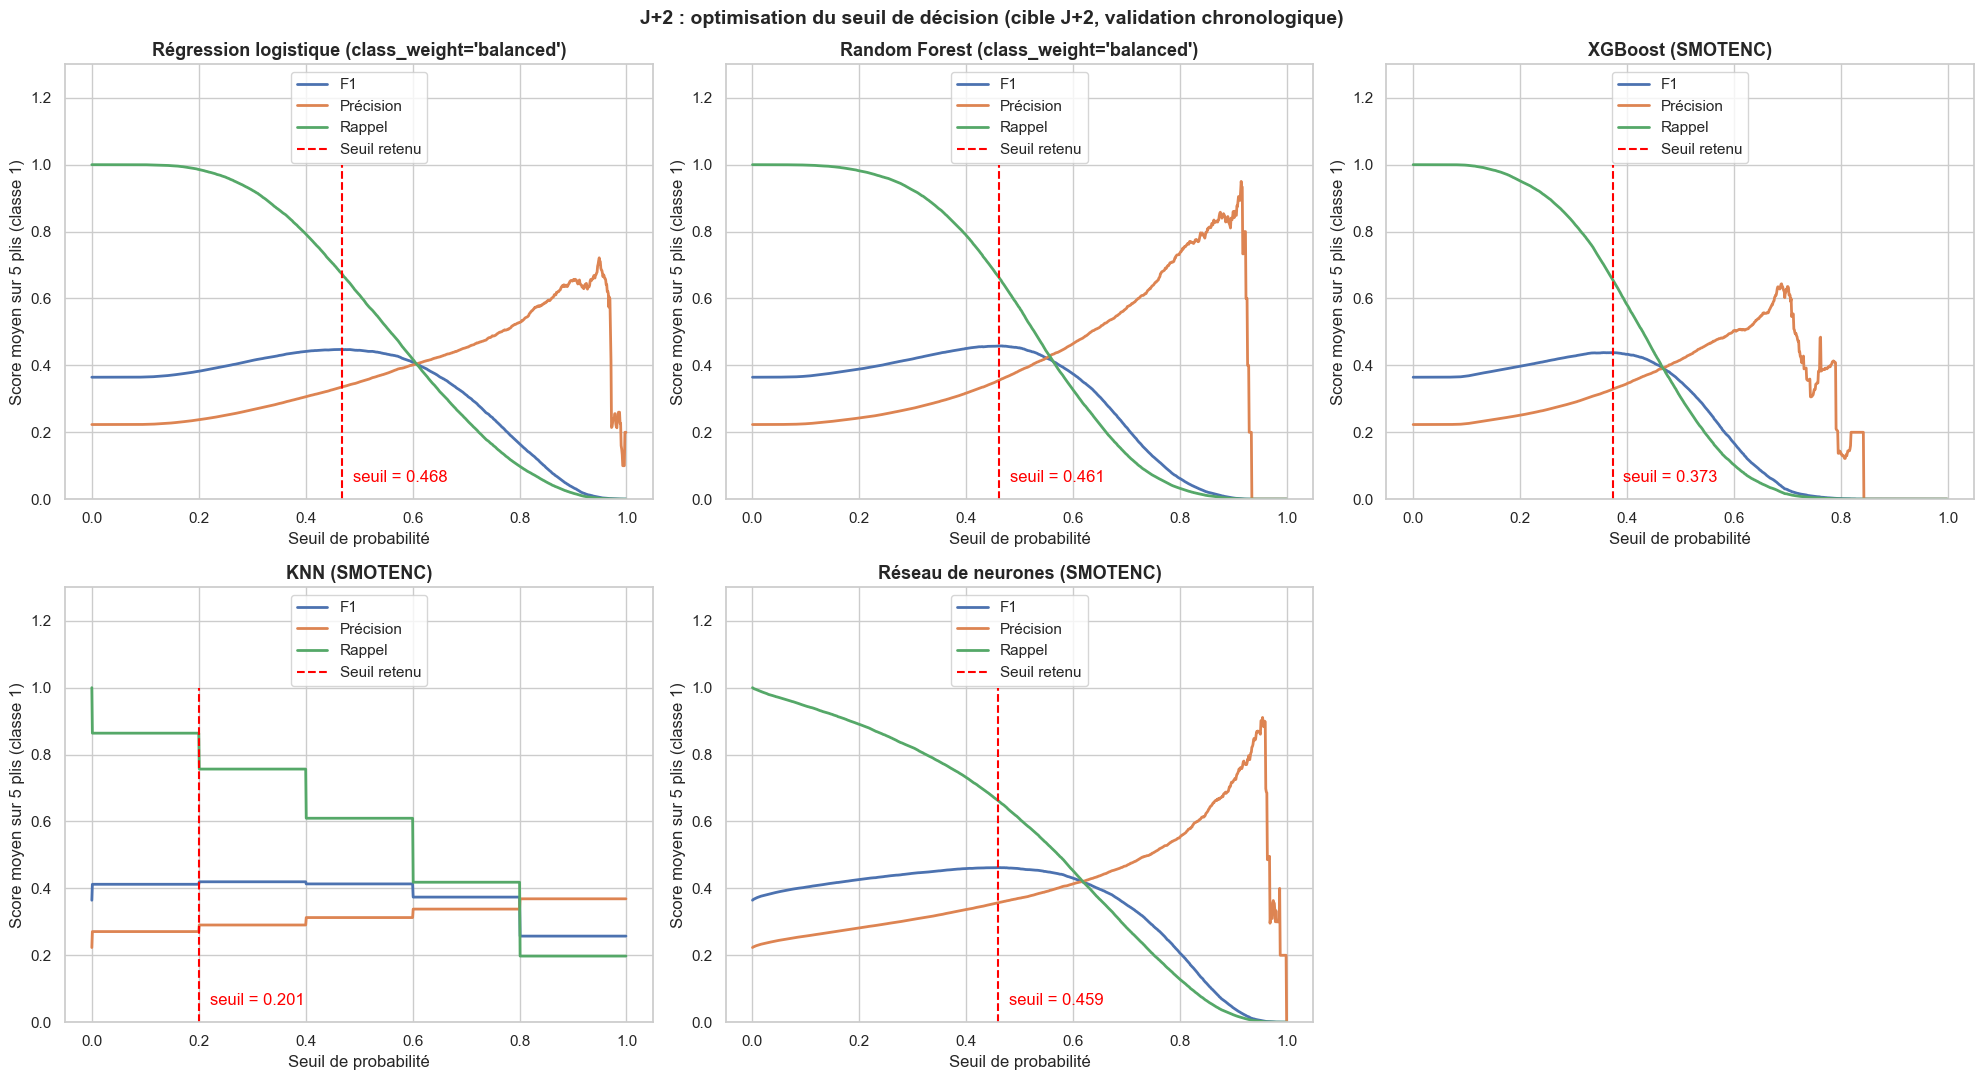

In [109]:
# CELL 109: J+2 : visualisation des seuils

plt.figure(figsize=(20, 11))
for i in range(len(modeles)):
    nom = modeles[i]
    s = seuil_retenu_J2[nom]
    plt.subplot(2, 3, i + 1)
    plt.plot(seuils, courbes_seuils_J2[nom]['F1'], linewidth=2, label="F1")
    plt.plot(seuils, courbes_seuils_J2[nom]['Précision'], linewidth=2, label="Précision")
    plt.plot(seuils, courbes_seuils_J2[nom]['Rappel'], linewidth=2, label="Rappel")
    plt.plot([s, s], [0, 1], color='red', linestyle='--', label="Seuil retenu")
    plt.text(s + 0.02, 0.05, f"seuil = {s:.3f}", color='red')
    plt.title(f"{nom} ({strategie_retenue_J2[nom]})", fontsize=13, fontweight='bold')
    plt.xlabel("Seuil de probabilité")
    plt.ylabel("Score moyen sur 5 plis (classe 1)")
    plt.ylim(0, 1.3)
    plt.legend(loc='upper center')

plt.suptitle("J+2 : optimisation du seuil de décision (cible J+2, validation chronologique)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_13_seuils_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_13_seuils_J2.png")
plt.show()

In [110]:
# CELL 110: J+2 : SMOTENC sur l'ensemble d'entraînement complet

# Location_encoded_J2 : celle des fichiers, calculée sur tout l'ensemble d'entraînement J+2 (correct ici) ;
# SMOTENC sur l'entraînement complet uniquement (jamais sur le test), une fois par jeu de données
smote_s = SMOTENC(categorical_features=[position_raintoday_J2], random_state=42)
debut = time()
Xs_train_sm_J2, ys_train_sm_J2 = smote_s.fit_resample(X_train_scaled_J2, y_train_J2)
duree_smote_s = time() - debut
smote_a = SMOTENC(categorical_features=[position_raintoday_J2], random_state=42)
debut = time()
Xa_train_sm_J2, ya_train_sm_J2 = smote_a.fit_resample(X_train_arbres_J2, y_train_J2)
duree_smote_a = time() - debut
print(f"SMOTENC sur l'entraînement complet J+2: {duree_smote_s:.2f} s (mises à l'échelle), {duree_smote_a:.2f} s "
      f"(non mises à l'échelle) | {len(y_train_J2)} -> {len(ys_train_sm_J2)} lignes, y = 1: {y_train_J2.mean() * 100:.2f}% -> "
      f"{ys_train_sm_J2.mean() * 100:.2f}%\n")

# Mêmes clés que les données d'un pli, pour réutiliser donnees_selon_option (CELL 40)
donnees_completes_J2 = {'Xs_tr': X_train_scaled_J2, 'Xa_tr': X_train_arbres_J2, 'y_tr': y_train_J2,
                        'Xs_tr_sm': Xs_train_sm_J2, 'ys_tr_sm': ys_train_sm_J2, 'Xa_tr_sm': Xa_train_sm_J2,
                        'ya_tr_sm': ya_train_sm_J2}

SMOTENC sur l'entraînement complet J+2: 3840.39 s (mises à l'échelle), 43.82 s (non mises à l'échelle) | 112353 -> 174862 lignes, y = 1: 22.18% -> 50.00%



In [111]:
# CELL 111: J+2 : entraînement final : régression logistique (ensemble d'entraînement complet)

modeles_finaux_J2 = {}
temps_entrainement_final_J2 = {}
p = parametres_retenus_J2['Régression logistique']
option = strategie_retenue_J2['Régression logistique']
X_fit, y_fit = donnees_selon_option(donnees_completes_J2, option, True)
modele = LogisticRegression(max_iter=p['max_iter'], class_weight=poids_selon_option(option))
debut = time()
modele.fit(X_fit, y_fit)
temps_entrainement_final_J2['Régression logistique'] = time() - debut
modeles_finaux_J2['Régression logistique'] = modele
print(f"Régression logistique | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {temps_entrainement_final_J2['Régression logistique']:.2f} s")

Régression logistique | paramètres: {'max_iter': 1000} | option: class_weight='balanced' | 112353 lignes d'entraînement | entraînement 1.29 s


In [112]:
# CELL 112: J+2 : entraînement final : Random Forest (ensemble d'entraînement complet)

p = parametres_retenus_J2['Random Forest']
option = strategie_retenue_J2['Random Forest']
X_fit, y_fit = donnees_selon_option(donnees_completes_J2, option, False)
modele = RandomForestClassifier(n_estimators=p['n_estimators'], max_depth=p['max_depth'],
                                class_weight=poids_selon_option(option), random_state=42, n_jobs=-1)
debut = time()
modele.fit(X_fit, y_fit)
temps_entrainement_final_J2['Random Forest'] = time() - debut
modeles_finaux_J2['Random Forest'] = modele
print(f"Random Forest | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {temps_entrainement_final_J2['Random Forest']:.2f} s")

Random Forest | paramètres: {'n_estimators': 300, 'max_depth': 10} | option: class_weight='balanced' | 112353 lignes d'entraînement | entraînement 13.37 s


In [113]:
# CELL 113: J+2 : entraînement final : XGBoost (ensemble d'entraînement complet)

p = parametres_retenus_J2['XGBoost']
option = strategie_retenue_J2['XGBoost']
X_fit, y_fit = donnees_selon_option(donnees_completes_J2, option, False)
modele = XGBClassifier(n_estimators=p['n_estimators'], learning_rate=p['learning_rate'],
                       max_depth=p['max_depth'], random_state=42, n_jobs=-1)
debut = time()
modele.fit(X_fit, y_fit)
temps_entrainement_final_J2['XGBoost'] = time() - debut
modeles_finaux_J2['XGBoost'] = modele
print(f"XGBoost | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {temps_entrainement_final_J2['XGBoost']:.2f} s")

XGBoost | paramètres: {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3} | option: SMOTENC | 174862 lignes d'entraînement | entraînement 1.42 s


In [114]:
# CELL 114: J+2 : entraînement final : KNN (ensemble d'entraînement complet)

p = parametres_retenus_J2['KNN']
option = strategie_retenue_J2['KNN']
X_fit, y_fit = donnees_selon_option(donnees_completes_J2, option, True)
modele = KNeighborsClassifier(n_neighbors=p['n_neighbors'], n_jobs=-1)
debut = time()
modele.fit(X_fit, y_fit)
temps_entrainement_final_J2['KNN'] = time() - debut
modeles_finaux_J2['KNN'] = modele
print(f"KNN | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {temps_entrainement_final_J2['KNN']:.2f} s")

KNN | paramètres: {'n_neighbors': 5} | option: SMOTENC | 174862 lignes d'entraînement | entraînement 0.06 s


In [115]:
# CELL 115: J+2 : entraînement final : réseau de neurones (ensemble d'entraînement complet)

p = parametres_retenus_J2['Réseau de neurones']
option = strategie_retenue_J2['Réseau de neurones']
X_fit, y_fit = donnees_selon_option(donnees_completes_J2, option, True)
if option == 'SMOTENC':
    # Même mélange que pour J+1 : la validation interne ne doit pas contenir que des exemples synthétiques
    X_fit = X_fit.sample(frac=1, random_state=42)
    y_fit = y_fit.loc[X_fit.index]
reseau, duree_fit = entrainer_reseau(X_fit.values, y_fit.values, p)
modeles_finaux_J2['Réseau de neurones'] = reseau
temps_entrainement_final_J2['Réseau de neurones'] = duree_fit
print(f"Réseau de neurones | paramètres: {p} | option: {option} | {len(y_fit)} lignes d'entraînement | "
      f"entraînement {duree_fit:.2f} s")

Réseau de neurones | paramètres: {'couches': (64, 32), 'dropout': 0.2} | option: SMOTENC | 174862 lignes d'entraînement | entraînement 289.89 s


In [116]:
# CELL 116: J+2 : probabilités de la classe 1 sur l'ensemble de test

# Une seule évaluation sur le test J+2, avec les modèles, options et seuils choisis sur les plis de validation J+2
probas_test_J2 = {}
durees_prediction_test_J2 = {}
for nom in modeles:
    debut = time()
    if nom == 'Réseau de neurones':
        probas_test_J2[nom] = modeles_finaux_J2[nom].predict(X_test_scaled_J2.values, verbose=0)[:, 1]
    elif nom == 'Random Forest' or nom == 'XGBoost':
        probas_test_J2[nom] = modeles_finaux_J2[nom].predict_proba(X_test_arbres_J2)[:, 1]
    else:
        probas_test_J2[nom] = modeles_finaux_J2[nom].predict_proba(X_test_scaled_J2)[:, 1]
    durees_prediction_test_J2[nom] = time() - debut

In [117]:
# CELL 117: J+2 : évaluation unique sur l'ensemble de test (seuil retenu de chaque modèle)

lignes_test_J2 = []
matrices_test_J2 = {}
courbes_roc_test_J2 = {}
for nom in modeles:
    seuil = seuil_retenu_J2[nom]
    pred = (probas_test_J2[nom] >= seuil).astype(int)
    pred_05 = (probas_test_J2[nom] >= 0.5).astype(int)
    fpr, tpr, seuils_roc = roc_curve(y_test_J2, probas_test_J2[nom])
    courbes_roc_test_J2[nom] = (fpr, tpr, auc(fpr, tpr))
    matrices_test_J2[nom] = confusion_matrix(y_test_J2, pred)
    lignes_test_J2.append({'Modèle': nom, 'Seuil': seuil, 'F1': f1_score(y_test_J2, pred),
                           'Précision': precision_score(y_test_J2, pred), 'Rappel': recall_score(y_test_J2, pred),
                           'Exactitude': accuracy_score(y_test_J2, pred), 'AUC': auc(fpr, tpr),
                           'F1 (seuil 0,5)': f1_score(y_test_J2, pred_05),
                           'Temps entraînement (s)': temps_entrainement_final_J2[nom],
                           'Temps prédiction (s)': durees_prediction_test_J2[nom]})
    print(f"===== J+2 | {nom} (seuil = {seuil:.3f}) =====")
    print(classification_report(y_test_J2, pred))
    print("Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):")
    print(matrices_test_J2[nom])
    print()

===== J+2 | Régression logistique (seuil = 0.468) =====
              precision    recall  f1-score   support

           0       0.87      0.61      0.72     21873
           1       0.34      0.69      0.45      6205

    accuracy                           0.63     28078
   macro avg       0.60      0.65      0.59     28078
weighted avg       0.76      0.63      0.66     28078

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[13412  8461]
 [ 1933  4272]]

===== J+2 | Random Forest (seuil = 0.461) =====
              precision    recall  f1-score   support

           0       0.89      0.59      0.71     21873
           1       0.34      0.73      0.46      6205

    accuracy                           0.62     28078
   macro avg       0.61      0.66      0.59     28078
weighted avg       0.77      0.62      0.66     28078

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[12967  8906]
 [ 1656  4549]]



===== J+2 | XGBoost (seuil = 0.373) =====
              precision    recall  f1-score   support

           0       0.86      0.62      0.72     21873
           1       0.33      0.65      0.44      6205

    accuracy                           0.63     28078
   macro avg       0.59      0.64      0.58     28078
weighted avg       0.74      0.63      0.66     28078

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[13506  8367]
 [ 2149  4056]]

===== J+2 | KNN (seuil = 0.201) =====
              precision    recall  f1-score   support

           0       0.87      0.47      0.61     21873
           1       0.29      0.76      0.42      6205

    accuracy                           0.54     28078
   macro avg       0.58      0.62      0.52     28078
weighted avg       0.75      0.54      0.57     28078

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[10349 11524]
 [ 1480  4725]]



===== J+2 | Réseau de neurones (seuil = 0.459) =====
              precision    recall  f1-score   support

           0       0.89      0.61      0.72     21873
           1       0.35      0.74      0.47      6205

    accuracy                           0.63     28078
   macro avg       0.62      0.67      0.60     28078
weighted avg       0.77      0.63      0.67     28078

Matrice de confusion (lignes = réel, colonnes = prédit ; 0 = pas de pluie, 1 = pluie):
[[13263  8610]
 [ 1642  4563]]



In [118]:
# CELL 118: J+2 : récapitulatif de l'évaluation sur l'ensemble de test

# Modèle naïf (toujours 0) : exactitude = part de la classe 0 dans le test ; précision et F1 valent 0 par définition
lignes_test_J2.append({'Modèle': 'Naïf (toujours pas de pluie)', 'Seuil': None, 'F1': 0.0, 'Précision': 0.0, 'Rappel': 0.0,
                       'Exactitude': (y_test_J2 == 0).mean(), 'AUC': None, 'F1 (seuil 0,5)': 0.0,
                       'Temps entraînement (s)': None, 'Temps prédiction (s)': None})
table_test_J2 = pd.DataFrame(lignes_test_J2).sort_values('F1', ascending=False).reset_index().drop(columns=['index'])

# Affichage : F1 en pleine précision, 4 décimales pour les autres colonnes
table_affichage_test = table_test_J2.copy()
f1_texte = []
for v in table_test_J2['F1'].values:
    f1_texte.append(str(v))
table_affichage_test['F1'] = f1_texte
for col in ['Seuil', 'Précision', 'Rappel', 'Exactitude', 'AUC', 'F1 (seuil 0,5)', 'Temps entraînement (s)',
            'Temps prédiction (s)']:
    valeurs_arrondies = []
    for v in table_test_J2[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_test[col] = valeurs_arrondies
print("Évaluation sur l'ensemble de test (cible J+2), triée par F1 décroissant:")
print(table_affichage_test)

Évaluation sur l'ensemble de test (cible J+2), triée par F1 décroissant:
                         Modèle  Seuil                   F1  Précision  Rappel  Exactitude     AUC  F1 (seuil 0,5)  Temps entraînement (s)  Temps prédiction (s)
0            Réseau de neurones  0.459   0.4709464341005264     0.3464  0.7354      0.6349  0.7340          0.4763                289.8870                2.3619
1                 Random Forest  0.461   0.4627670396744659     0.3381  0.7331      0.6238  0.7251          0.4673                 13.3669                0.3543
2         Régression logistique  0.468   0.4511564051114162     0.3355  0.6885      0.6298  0.7063          0.4489                  1.2875                0.0201
3                       XGBoost  0.373  0.43547348078161907     0.3265  0.6537      0.6255  0.6875          0.3477                  1.4223                0.0197
4                           KNN  0.201   0.4208604257593302     0.2908  0.7615      0.5369  0.6591          0.4195        

Figure sauvegardée: figures/etape3_14_matrices_confusion_test_J2.png


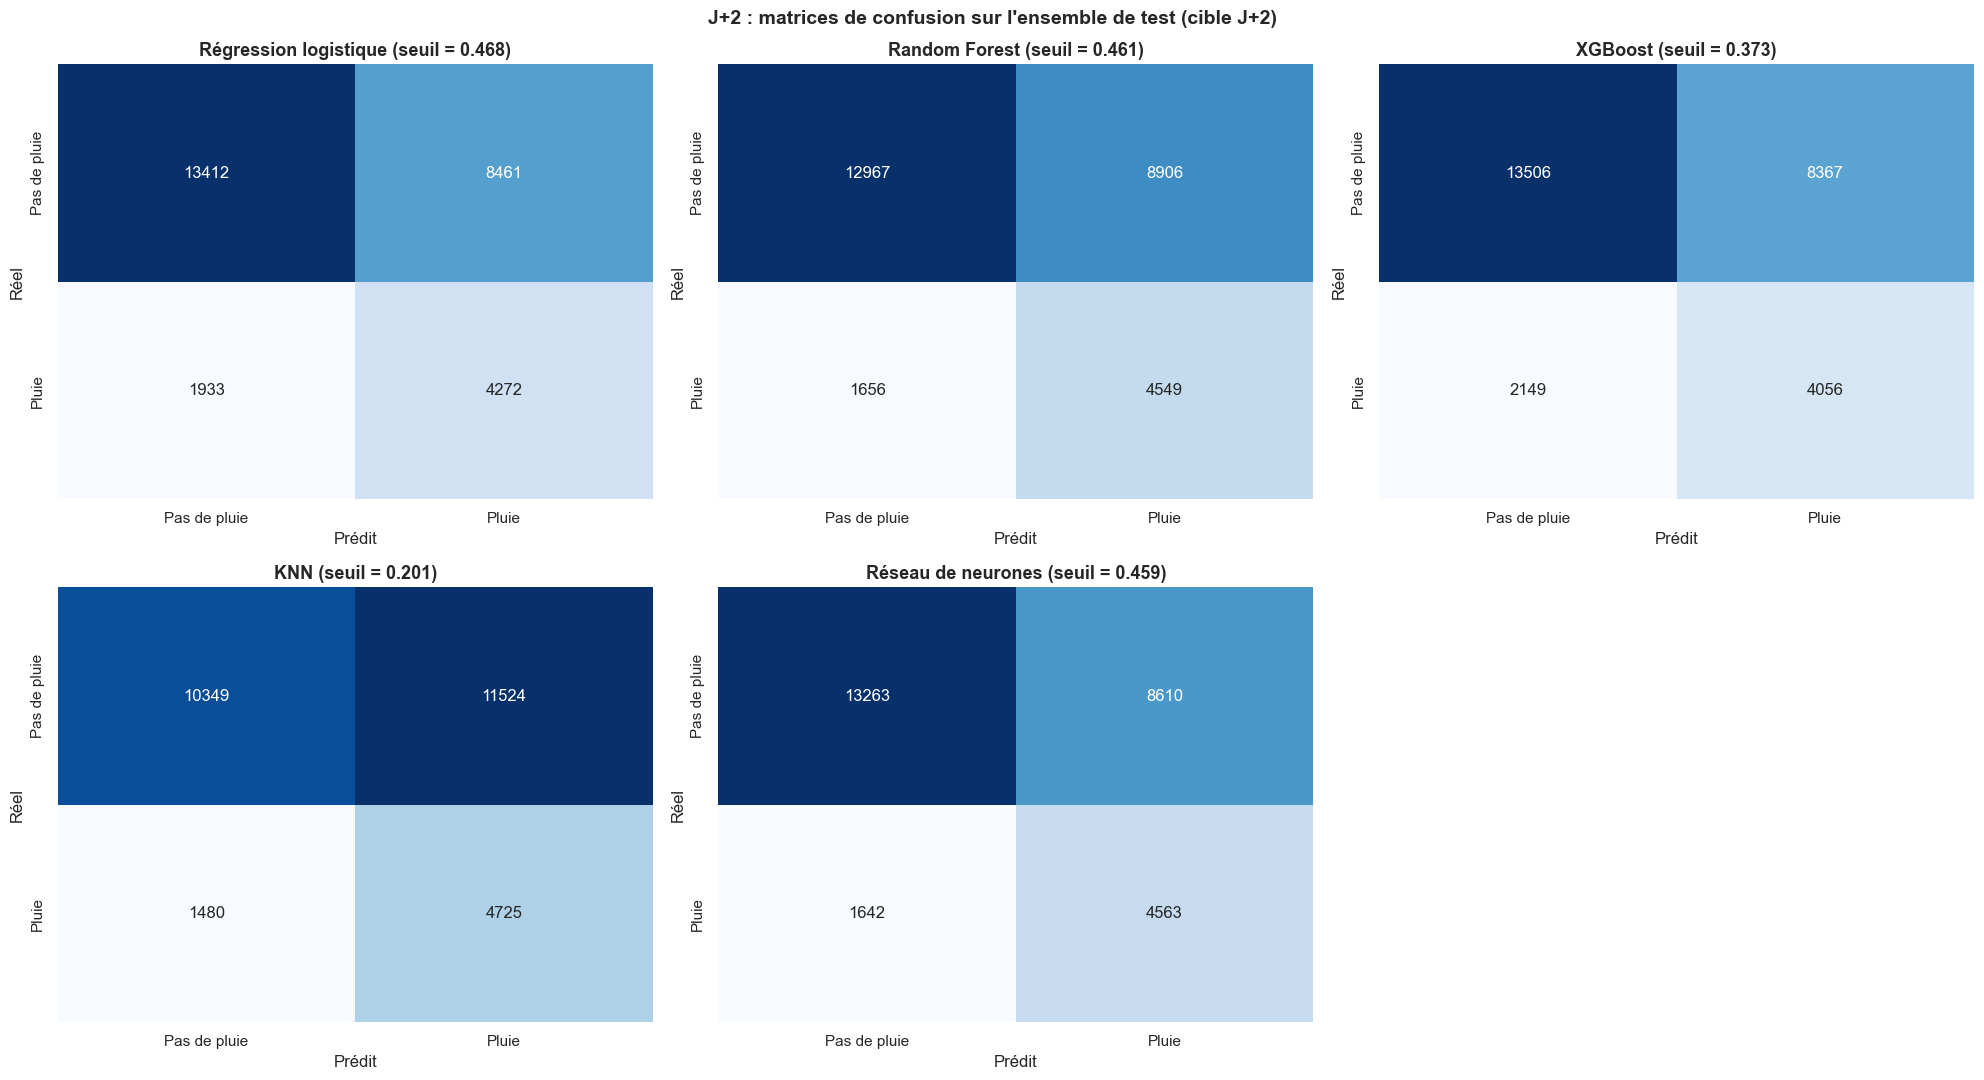

In [119]:
# CELL 119: J+2 : matrices de confusion (test)

plt.figure(figsize=(20, 11))
for i in range(len(modeles)):
    nom = modeles[i]
    plt.subplot(2, 3, i + 1)
    sns.heatmap(matrices_test_J2[nom], annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xticks([0.5, 1.5], ['Pas de pluie', 'Pluie'])
    plt.yticks([0.5, 1.5], ['Pas de pluie', 'Pluie'])
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title(f"{nom} (seuil = {seuil_retenu_J2[nom]:.3f})", fontsize=13, fontweight='bold')

plt.suptitle("J+2 : matrices de confusion sur l'ensemble de test (cible J+2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_14_matrices_confusion_test_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_14_matrices_confusion_test_J2.png")
plt.show()

Figure sauvegardée: figures/etape3_15_courbes_roc_test_J2.png


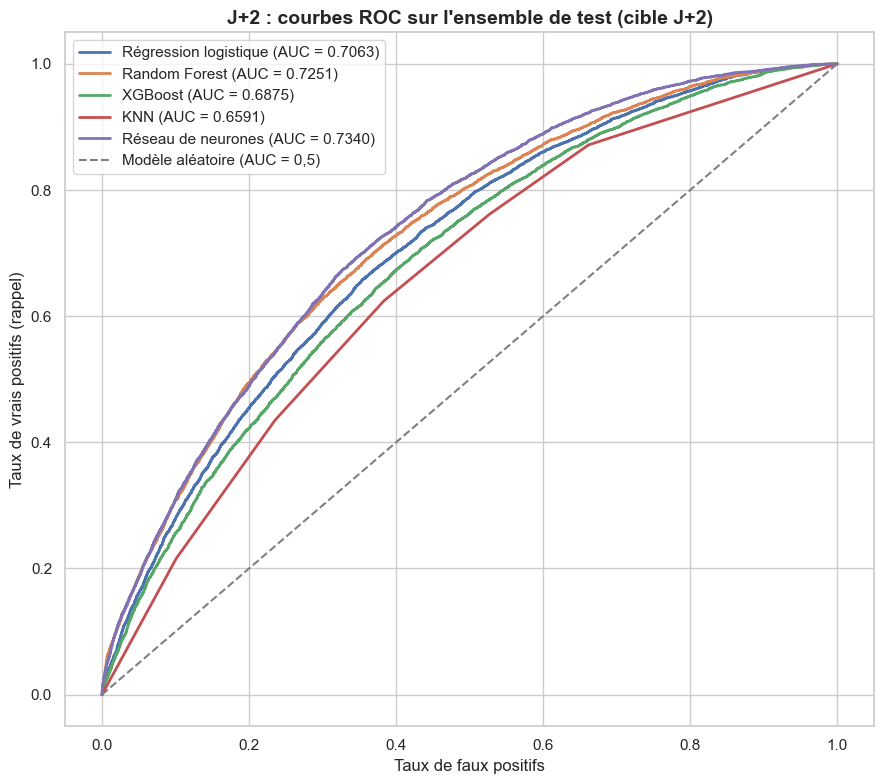

In [120]:
# CELL 120: J+2 : courbes ROC (test)

plt.figure(figsize=(9, 8))
for nom in modeles:
    fpr, tpr, auc_test = courbes_roc_test_J2[nom]
    plt.plot(fpr, tpr, linewidth=2, label=f"{nom} (AUC = {auc_test:.4f})")
# Diagonale : modèle aléatoire (AUC = 0,5)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Modèle aléatoire (AUC = 0,5)")
plt.title("J+2 : courbes ROC sur l'ensemble de test (cible J+2)", fontsize=14, fontweight='bold')
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape3_15_courbes_roc_test_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_15_courbes_roc_test_J2.png")
plt.show()

In [121]:
# CELL 121: J+2 : sauvegarde des modèles finaux

ignorer_avertissements()

# Mêmes formats que J+1 (CELL 61), suffixe _J2
fichiers_J2 = {
    'Régression logistique': 'modele_regression_logistique_J2.joblib',
    'KNN': 'modele_knn_J2.joblib',
    'Random Forest': 'modele_random_forest_J2.joblib',
    'XGBoost': 'modele_xgboost_J2.json',
    'Réseau de neurones': 'modele_reseau_neurones_J2.keras'
}
joblib.dump(modeles_finaux_J2['Régression logistique'], dossier_modeles + fichiers_J2['Régression logistique'])
joblib.dump(modeles_finaux_J2['KNN'], dossier_modeles + fichiers_J2['KNN'])
joblib.dump(modeles_finaux_J2['Random Forest'], dossier_modeles + fichiers_J2['Random Forest'])
modeles_finaux_J2['XGBoost'].save_model(dossier_modeles + fichiers_J2['XGBoost'])
modeles_finaux_J2['Réseau de neurones'].save(dossier_modeles + fichiers_J2['Réseau de neurones'])
joblib.dump({'parametres_retenus': parametres_retenus_J2, 'strategie_retenue': strategie_retenue_J2,
             'seuil_retenu': seuil_retenu_J2}, dossier_modeles + 'modeles_parametres_J2.joblib')

noms_fichiers = []
for nom in modeles:
    noms_fichiers.append(fichiers_J2[nom])
noms_fichiers.append('modeles_parametres_J2.joblib')
print("Fichiers sauvegardés dans models/:")
for nom_fichier in noms_fichiers:
    with open(dossier_modeles + nom_fichier, 'rb') as f:
        taille = len(f.read()) / (1024 * 1024)
    print(f"  {nom_fichier}: {taille:.2f} Mo")

Fichiers sauvegardés dans models/:
  modele_regression_logistique_J2.joblib: 0.00 Mo
  modele_random_forest_J2.joblib: 37.12 Mo
  modele_xgboost_J2.json: 0.12 Mo
  modele_knn_J2.joblib: 33.35 Mo
  modele_reseau_neurones_J2.keras: 0.07 Mo
  modeles_parametres_J2.joblib: 0.00 Mo


In [122]:
# CELL 122: J+2 : performances sur l'ensemble d'entraînement (détection du surapprentissage)

# Un grand écart positif entraînement - test signale un surapprentissage ; un petit écart, un modèle qui généralise.
# Scores calculés sur les lignes d'entraînement d'origine (pas sur les lignes SMOTENC), seuil retenu de chaque modèle
lignes_surapprentissage_J2 = []
for nom in modeles:
    if nom == 'Réseau de neurones':
        proba_tr = modeles_finaux_J2[nom].predict(X_train_scaled_J2.values, verbose=0)[:, 1]
    elif nom == 'Random Forest' or nom == 'XGBoost':
        proba_tr = modeles_finaux_J2[nom].predict_proba(X_train_arbres_J2)[:, 1]
    else:
        proba_tr = modeles_finaux_J2[nom].predict_proba(X_train_scaled_J2)[:, 1]
    pred_tr = (proba_tr >= seuil_retenu_J2[nom]).astype(int)
    fpr, tpr, seuils_roc = roc_curve(y_train_J2, proba_tr)
    r = table_test_J2[table_test_J2['Modèle'] == nom]
    lignes_surapprentissage_J2.append({
        'Modèle': nom,
        'F1 entraînement': f1_score(y_train_J2, pred_tr), 'F1 test': r['F1'].values[0],
        'Écart F1': f1_score(y_train_J2, pred_tr) - r['F1'].values[0],
        'Exactitude entraînement': accuracy_score(y_train_J2, pred_tr), 'Exactitude test': r['Exactitude'].values[0],
        'Écart exactitude': accuracy_score(y_train_J2, pred_tr) - r['Exactitude'].values[0],
        'AUC entraînement': auc(fpr, tpr), 'AUC test': r['AUC'].values[0], 'Écart AUC': auc(fpr, tpr) - r['AUC'].values[0]
    })
    print(f"{nom} | entraînement: F1 = {f1_score(y_train_J2, pred_tr):.4f} | précision = {precision_score(y_train_J2, pred_tr):.4f} | "
          f"rappel = {recall_score(y_train_J2, pred_tr):.4f} | exactitude = {accuracy_score(y_train_J2, pred_tr):.4f} | "
          f"AUC = {auc(fpr, tpr):.4f}")

Régression logistique | entraînement: F1 = 0.4557 | précision = 0.3381 | rappel = 0.6991 | exactitude = 0.6296 | AUC = 0.7171


Random Forest | entraînement: F1 = 0.5259 | précision = 0.3851 | rappel = 0.8292 | exactitude = 0.6684 | AUC = 0.8111


XGBoost | entraînement: F1 = 0.4501 | précision = 0.3378 | rappel = 0.6743 | exactitude = 0.6345 | AUC = 0.7081


KNN | entraînement: F1 = 0.5697 | précision = 0.3995 | rappel = 0.9927 | exactitude = 0.6674 | AUC = 0.9582


Réseau de neurones | entraînement: F1 = 0.5024 | précision = 0.3711 | rappel = 0.7775 | exactitude = 0.6584 | AUC = 0.7721


In [123]:
# CELL 123: J+2 : comparaison des performances entraînement / test

table_surapprentissage_J2 = pd.DataFrame(lignes_surapprentissage_J2)
table_affichage_surapp = table_surapprentissage_J2.copy()
for col in ['F1 entraînement', 'F1 test', 'Écart F1', 'Exactitude entraînement', 'Exactitude test', 'Écart exactitude',
            'AUC entraînement', 'AUC test', 'Écart AUC']:
    valeurs_arrondies = []
    for v in table_surapprentissage_J2[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_surapp[col] = valeurs_arrondies
print("\nJ+2, performances entraînement / test (seuil retenu de chaque modèle):")
print(table_affichage_surapp)


J+2, performances entraînement / test (seuil retenu de chaque modèle):
                  Modèle  F1 entraînement  F1 test  Écart F1  Exactitude entraînement  Exactitude test  Écart exactitude  AUC entraînement  AUC test  Écart AUC
0  Régression logistique           0.4557   0.4512    0.0046                   0.6296           0.6298           -0.0002            0.7171    0.7063     0.0108
1          Random Forest           0.5259   0.4628    0.0632                   0.6684           0.6238            0.0446            0.8111    0.7251     0.0860
2                XGBoost           0.4501   0.4355    0.0146                   0.6345           0.6255            0.0091            0.7081    0.6875     0.0206
3                    KNN           0.5697   0.4209    0.1488                   0.6674           0.5369            0.1305            0.9582    0.6591     0.2991
4     Réseau de neurones           0.5024   0.4709    0.0315                   0.6584           0.6349            0.0235        

In [124]:
# CELL 124: J+2 : interprétation de la régression logistique (odds ratios)

# Odds ratio = exp(coefficient) ; variables mises à l'échelle : un odds ratio supérieur à 1 augmente la probabilité
# de pluie dans deux jours quand la variable augmente, un odds ratio inférieur à 1 la diminue
coefficients_J2 = modeles_finaux_J2['Régression logistique'].coef_[0]
table_odds_J2 = pd.DataFrame({'Variable': X_train_scaled_J2.columns, 'Coefficient': coefficients_J2,
                              'Odds ratio': np.exp(coefficients_J2)})
table_odds_J2 = table_odds_J2.sort_values('Odds ratio', ascending=False).reset_index().drop(columns=['index'])
table_affichage_odds = table_odds_J2.copy()
coefficients_arrondis = []
odds_arrondis = []
for i in range(len(table_odds_J2)):
    coefficients_arrondis.append(round(table_odds_J2['Coefficient'].values[i], 4))
    odds_arrondis.append(round(table_odds_J2['Odds ratio'].values[i], 4))
table_affichage_odds['Coefficient'] = coefficients_arrondis
table_affichage_odds['Odds ratio'] = odds_arrondis
print("J+2, régression logistique finale, odds ratios triés par ordre décroissant:")
print(table_affichage_odds)

J+2, régression logistique finale, odds ratios triés par ordre décroissant:
               Variable  Coefficient  Odds ratio
0       WindGustDir_cos       0.3696      1.4472
1           Humidity3pm       0.3382      1.4025
2        WindDir3pm_cos       0.3101      1.3635
3             RainToday       0.3024      1.3531
4   Location_encoded_J2       0.2596      1.2964
5           Humidity9am       0.2383      1.2691
6        WindDir9am_cos       0.2167      1.2420
7         WindGustSpeed       0.1609      1.1746
8               MinTemp       0.1492      1.1610
9       WindGustDir_sin       0.1400      1.1503
10        Humidity_diff       0.0720      1.0747
11            Temp_diff       0.0505      1.0518
12       WindDir9am_sin       0.0494      1.0507
13         WindSpeed9am       0.0288      1.0292
14             Rainfall       0.0052      1.0052
15            Month_sin      -0.0062      0.9939
16       WindDir3pm_sin      -0.0338      0.9667
17           Season_cos      -0.1027      

Figure sauvegardée: figures/etape3_16_odds_ratios_J2.png


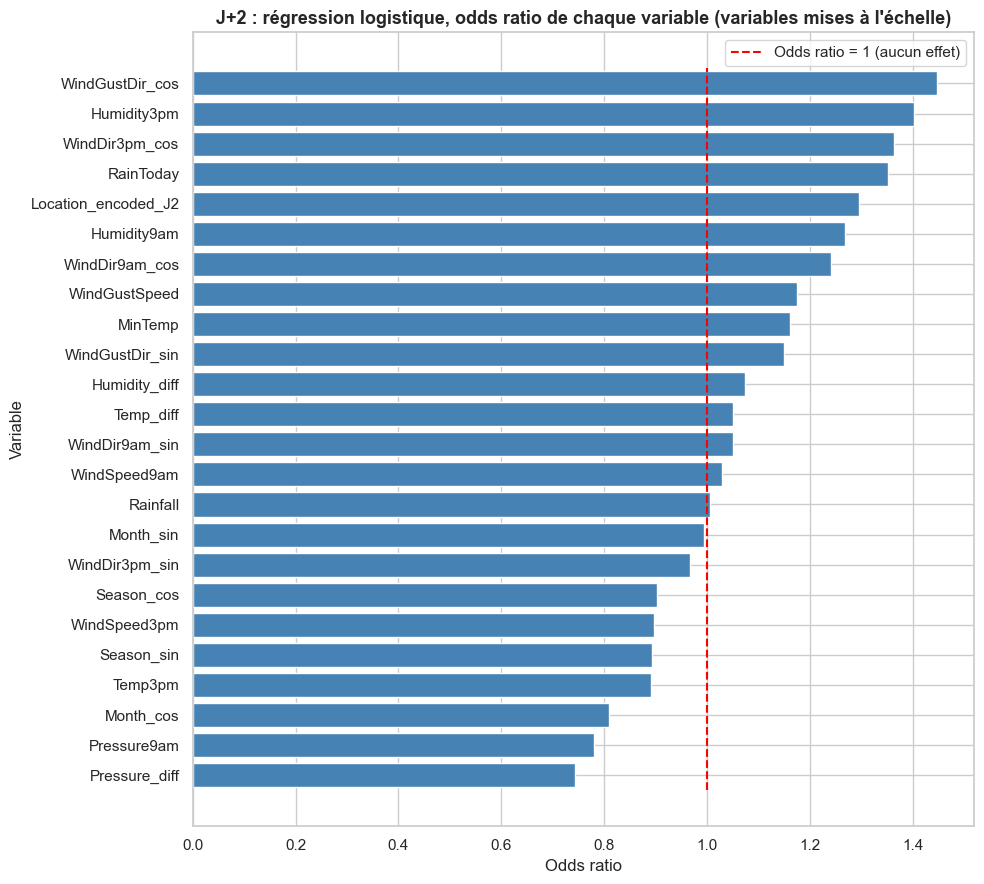

In [125]:
# CELL 125: J+2 : graphique des odds ratios

table_graphique = table_odds_J2.sort_values('Odds ratio', ascending=True)
plt.figure(figsize=(10, 9))
plt.barh(table_graphique['Variable'], table_graphique['Odds ratio'], color='steelblue')
plt.plot([1, 1], [-0.5, len(table_graphique) - 0.5], color='red', linestyle='--', label="Odds ratio = 1 (aucun effet)")
plt.title("J+2 : régression logistique, odds ratio de chaque variable (variables mises à l'échelle)",
          fontsize=13, fontweight='bold')
plt.xlabel("Odds ratio")
plt.ylabel("Variable")
plt.legend()
plt.tight_layout()
plt.savefig('../figures/etape3_16_odds_ratios_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_16_odds_ratios_J2.png")
plt.show()

In [126]:
# CELL 126: J+2 : importance des variables (Random Forest et XGBoost)

# Fonction table_importance de CELL 67
tables_importance_J2 = {}
tables_importance_J2['Random Forest'] = table_importance(modeles_finaux_J2['Random Forest'], X_train_arbres_J2.columns,
                                                         'J+2, Random Forest')
tables_importance_J2['XGBoost'] = table_importance(modeles_finaux_J2['XGBoost'], X_train_arbres_J2.columns, 'J+2, XGBoost')

J+2, Random Forest final, importance des variables triée par ordre décroissant:
               Variable  Importance
0           Humidity3pm      0.1703
1   Location_encoded_J2      0.0868
2           Humidity9am      0.0798
3              Rainfall      0.0652
4           Pressure9am      0.0622
5         Pressure_diff      0.0586
6       WindGustDir_cos      0.0548
7        WindDir3pm_cos      0.0537
8             Temp_diff      0.0493
9               MinTemp      0.0393
10        Humidity_diff      0.0382
11              Temp3pm      0.0378
12            RainToday      0.0329
13       WindDir9am_cos      0.0324
14        WindGustSpeed      0.0270
15         WindSpeed3pm      0.0176
16            Month_cos      0.0173
17         WindSpeed9am      0.0142
18       WindDir3pm_sin      0.0120
19      WindGustDir_sin      0.0120
20       WindDir9am_sin      0.0115
21            Month_sin      0.0112
22           Season_cos      0.0091
23           Season_sin      0.0067

J+2, XGBoost final,

Figure sauvegardée: figures/etape3_17_importance_variables_J2.png


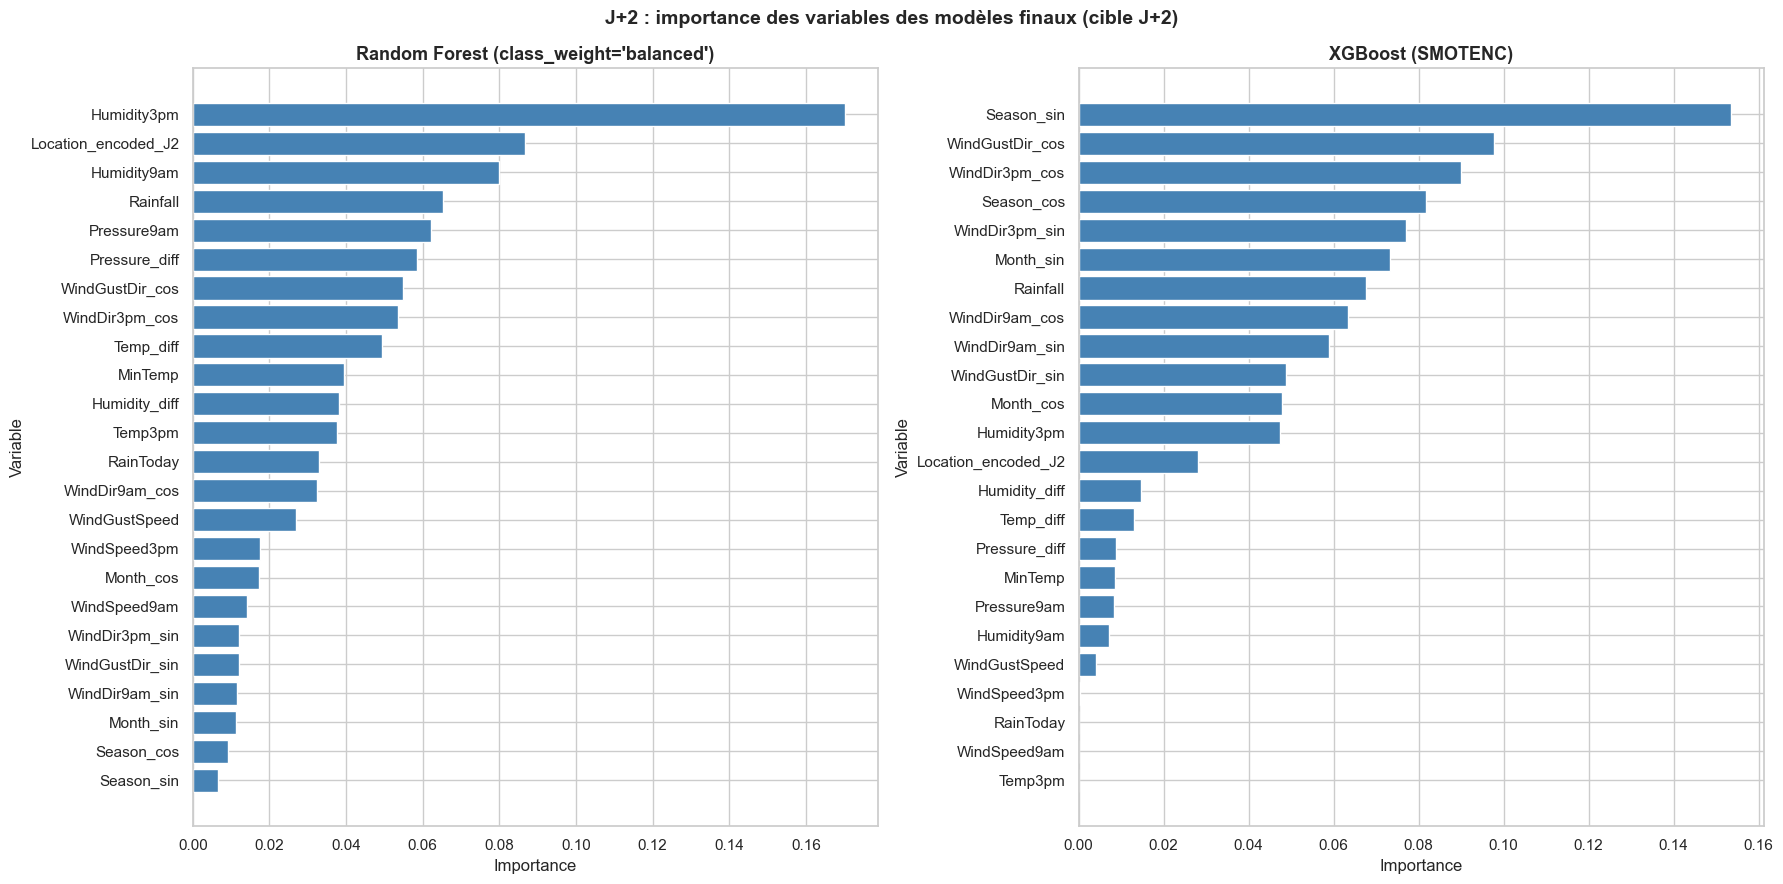

In [127]:
# CELL 127: J+2 : graphique de l'importance des variables

plt.figure(figsize=(18, 9))

plt.subplot(1, 2, 1)
table_graphique = tables_importance_J2['Random Forest'].sort_values('Importance', ascending=True)
plt.barh(table_graphique['Variable'], table_graphique['Importance'], color='steelblue')
plt.title(f"Random Forest ({strategie_retenue_J2['Random Forest']})", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.subplot(1, 2, 2)
table_graphique = tables_importance_J2['XGBoost'].sort_values('Importance', ascending=True)
plt.barh(table_graphique['Variable'], table_graphique['Importance'], color='steelblue')
plt.title(f"XGBoost ({strategie_retenue_J2['XGBoost']})", fontsize=13, fontweight='bold')
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.suptitle("J+2 : importance des variables des modèles finaux (cible J+2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_17_importance_variables_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_17_importance_variables_J2.png")
plt.show()

In [128]:
# CELL 128: J+2 : valeurs SHAP du modèle XGBoost final sur l'ensemble de test

# Mêmes étapes que J+1 (CELL 69) : données de test J+2 non mises à l'échelle (CELL 116), log-odds de la classe 1
explainer_J2 = shap.TreeExplainer(modeles_finaux_J2['XGBoost'])
valeurs_shap_J2 = explainer_J2.shap_values(X_test_arbres_J2)
print(f"Valeurs SHAP J+2: {valeurs_shap_J2.shape[0]} lignes × {valeurs_shap_J2.shape[1]} variables")
print(f"Valeur de base (sortie brute moyenne du modèle): {explainer_J2.expected_value:.4f}")

# Contrôle : valeur de base + somme des valeurs SHAP d'une ligne = sortie brute log(p / (1 - p)) (CELL 116)
sortie_brute_J2 = np.log(probas_test_J2['XGBoost'] / (1 - probas_test_J2['XGBoost']))
ecart_shap_J2 = np.abs(explainer_J2.expected_value + valeurs_shap_J2.sum(axis=1) - sortie_brute_J2).max()
print(f"Écart maximal entre valeur de base + somme des valeurs SHAP et sortie brute du modèle: {ecart_shap_J2:.2e}")

Valeurs SHAP J+2: 28078 lignes × 24 variables
Valeur de base (sortie brute moyenne du modèle): 0.0017
Écart maximal entre valeur de base + somme des valeurs SHAP et sortie brute du modèle: 1.43e-06


In [129]:
# CELL 129: J+2 : valeur SHAP absolue moyenne de chaque variable et rang dans l'importance intégrée de XGBoost

# Fonction table_shap_xgboost de CELL 70 ; importance intégrée J+2 de CELL 126
table_shap_J2 = table_shap_xgboost(valeurs_shap_J2, X_test_arbres_J2.columns, tables_importance_J2['XGBoost'])
table_affichage_shap = table_shap_J2.copy()
valeurs_arrondies = []
for v in table_shap_J2['SHAP absolu moyen'].values:
    valeurs_arrondies.append(round(v, 4))
table_affichage_shap['SHAP absolu moyen'] = valeurs_arrondies
print("J+2, XGBoost final, 15 premières variables par valeur SHAP absolue moyenne sur le test,")
print("avec leur rang dans l'importance intégrée de XGBoost (CELL 126):")
print(table_affichage_shap.head(15))

J+2, XGBoost final, 15 premières variables par valeur SHAP absolue moyenne sur le test,
avec leur rang dans l'importance intégrée de XGBoost (CELL 126):
               Variable  SHAP absolu moyen  Rang SHAP  Rang importance XGBoost
0              Rainfall             0.2659          1                        7
1           Humidity3pm             0.2206          2                       12
2        WindDir3pm_cos             0.1616          3                        3
3        WindDir9am_sin             0.1425          4                        9
4   Location_encoded_J2             0.1393          5                       13
5       WindGustDir_cos             0.1352          6                        2
6            Season_sin             0.1237          7                        1
7        WindDir9am_cos             0.1115          8                        8
8        WindDir3pm_sin             0.0936          9                        5
9       WindGustDir_sin             0.0806         10    

Figure sauvegardée: figures/etape3_21_shap_xgboost_J2.png


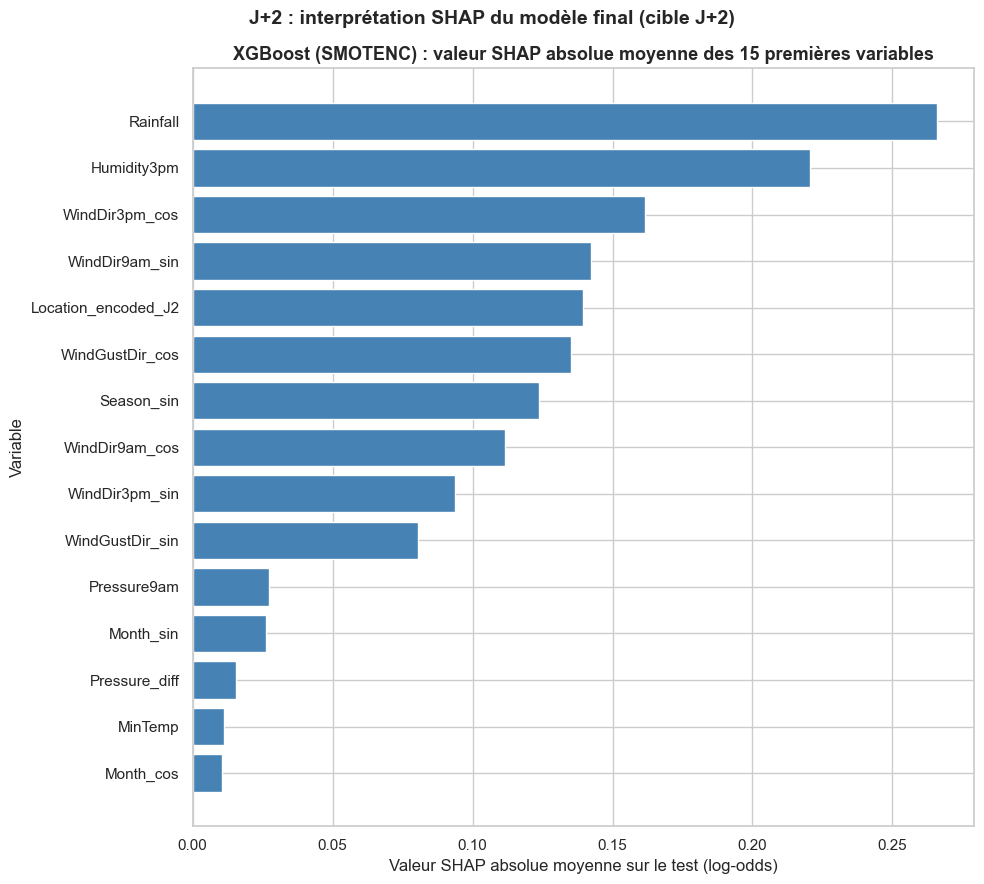

In [130]:
# CELL 130: J+2 : graphique de la valeur SHAP absolue moyenne (15 premières variables)

table_graphique = table_shap_J2.head(15).sort_values('SHAP absolu moyen', ascending=True)
plt.figure(figsize=(10, 9))
plt.barh(table_graphique['Variable'], table_graphique['SHAP absolu moyen'], color='steelblue')
plt.title(f"XGBoost ({strategie_retenue_J2['XGBoost']}) : valeur SHAP absolue moyenne des 15 premières variables",
          fontsize=13, fontweight='bold')
plt.xlabel("Valeur SHAP absolue moyenne sur le test (log-odds)")
plt.ylabel("Variable")
plt.suptitle("J+2 : interprétation SHAP du modèle final (cible J+2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_21_shap_xgboost_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_21_shap_xgboost_J2.png")
plt.show()

Figure sauvegardée: figures/etape3_22_shap_dependance_J2.png


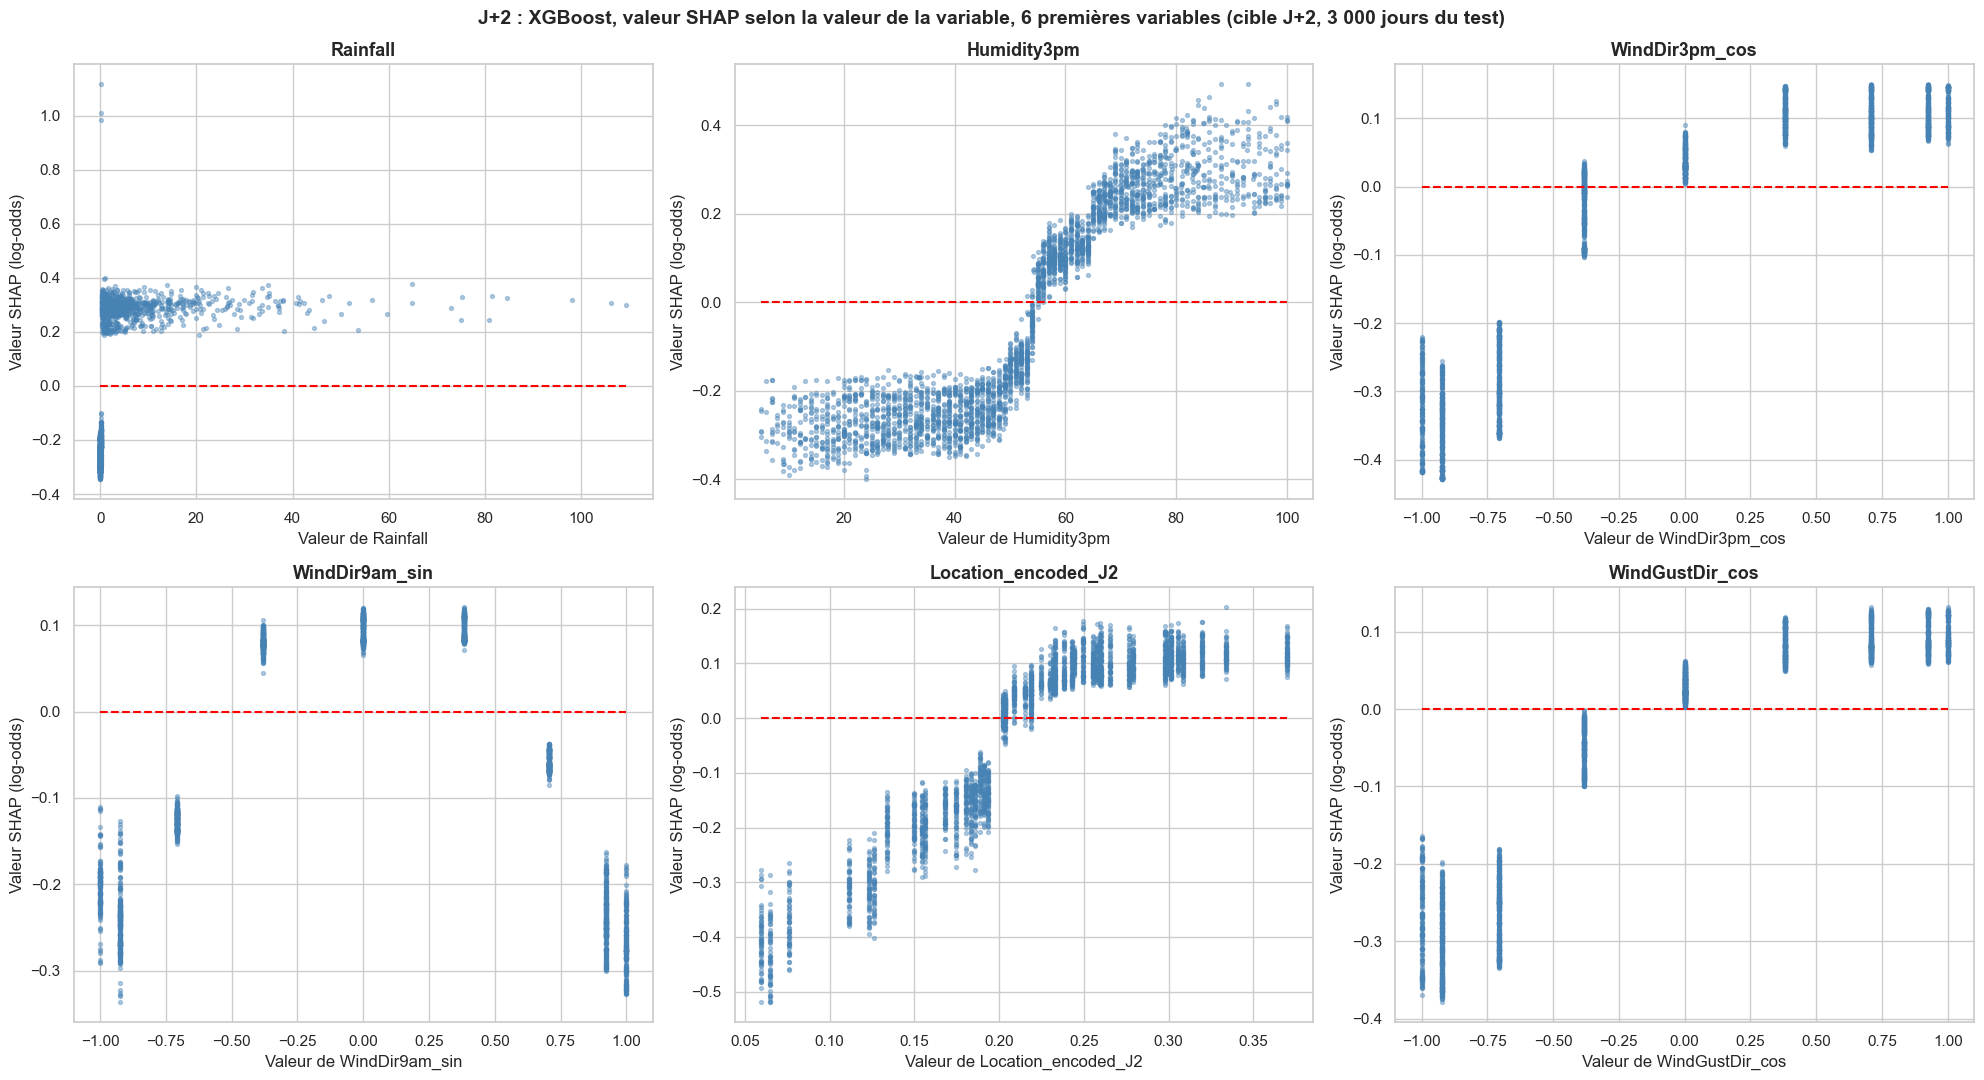

In [131]:
# CELL 131: J+2 : graphique de dépendance SHAP des 6 variables à la plus forte valeur SHAP absolue moyenne

# Fonction panneaux_dependance de CELL 72 (échantillon aléatoire de 3 000 lignes du test, random_state=42)
plt.figure(figsize=(20, 11))
panneaux_dependance(table_shap_J2, X_test_arbres_J2, valeurs_shap_J2)
plt.suptitle("J+2 : XGBoost, valeur SHAP selon la valeur de la variable, 6 premières variables "
             "(cible J+2, 3 000 jours du test)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_22_shap_dependance_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_22_shap_dependance_J2.png")
plt.show()

In [132]:
# CELL 132: J+2 : scores par station sur l'ensemble de test

# Probabilités de CELL 116 et seuil retenu de chaque modèle (scores_au_seuil, CELL 46)
stations_J2 = np.sort(meta_test_J2['Location'].unique())
lignes_stations_J2 = []
for nom in modeles:
    for station in stations_J2:
        masque = (meta_test_J2['Location'] == station).values
        y_station = y_test_J2[masque]
        f1, precision, rappel = scores_au_seuil(probas_test_J2[nom][masque], y_station, seuil_retenu_J2[nom])
        lignes_stations_J2.append({'Modèle': nom, 'Station': station, 'Jours de test': len(y_station),
                                   'Jours de pluie': int(y_station.sum()), 'F1': f1, 'Précision': precision,
                                   'Rappel': rappel})
table_stations_J2 = pd.DataFrame(lignes_stations_J2)

In [133]:
# CELL 133: J+2 : analyse par station : meilleur modèle et résumé par modèle

# Modèle au meilleur F1 sur le test J+2 (CELL 118, ligne 0 du tableau trié)
meilleur_modele_J2 = table_test_J2['Modèle'].values[0]
table_meilleur_J2 = table_stations_J2[table_stations_J2['Modèle'] == meilleur_modele_J2].sort_values('F1', ascending=False)
table_meilleur_J2 = table_meilleur_J2.reset_index().drop(columns=['index'])
table_affichage_stations = table_meilleur_J2.copy()
for col in ['F1', 'Précision', 'Rappel']:
    valeurs_arrondies = []
    for v in table_meilleur_J2[col].values:
        valeurs_arrondies.append(round(v, 4))
    table_affichage_stations[col] = valeurs_arrondies
print(f"J+2, {meilleur_modele_J2} (meilleur F1 sur le test), scores par station triés par F1 décroissant:")
print(table_affichage_stations)

print(f"\nJ+2, résumé du F1 par station ({len(stations_J2)} stations):")
for nom in modeles:
    r = table_stations_J2[table_stations_J2['Modèle'] == nom]
    print(f"  {nom}: F1 moyen = {r['F1'].mean():.4f} | minimum = {r['F1'].min():.4f} | maximum = {r['F1'].max():.4f} | "
          f"stations avec F1 < 0,5: {(r['F1'] < 0.5).sum()}")

J+2, Réseau de neurones (meilleur F1 sur le test), scores par station triés par F1 décroissant:
                Modèle           Station  Jours de test  Jours de pluie      F1  Précision  Rappel
0   Réseau de neurones       Witchcliffe            575             164  0.6477     0.5051  0.9024
1   Réseau de neurones           Walpole            553             196  0.6333     0.4876  0.9031
2   Réseau de neurones            Darwin            592             189  0.6288     0.4897  0.8783
3   Réseau de neurones          Portland            586             208  0.6090     0.4757  0.8462
4   Réseau de neurones          Dartmoor            588             168  0.5934     0.4554  0.8512
5   Réseau de neurones      MountGambier            575             169  0.5720     0.4493  0.7870
6   Réseau de neurones            Cairns            524             180  0.5449     0.3829  0.9444
7   Réseau de neurones         Katherine            572             125  0.5440     0.4023  0.8400
8   Réseau de

Figure sauvegardée: figures/etape3_18_analyse_par_station_J2.png


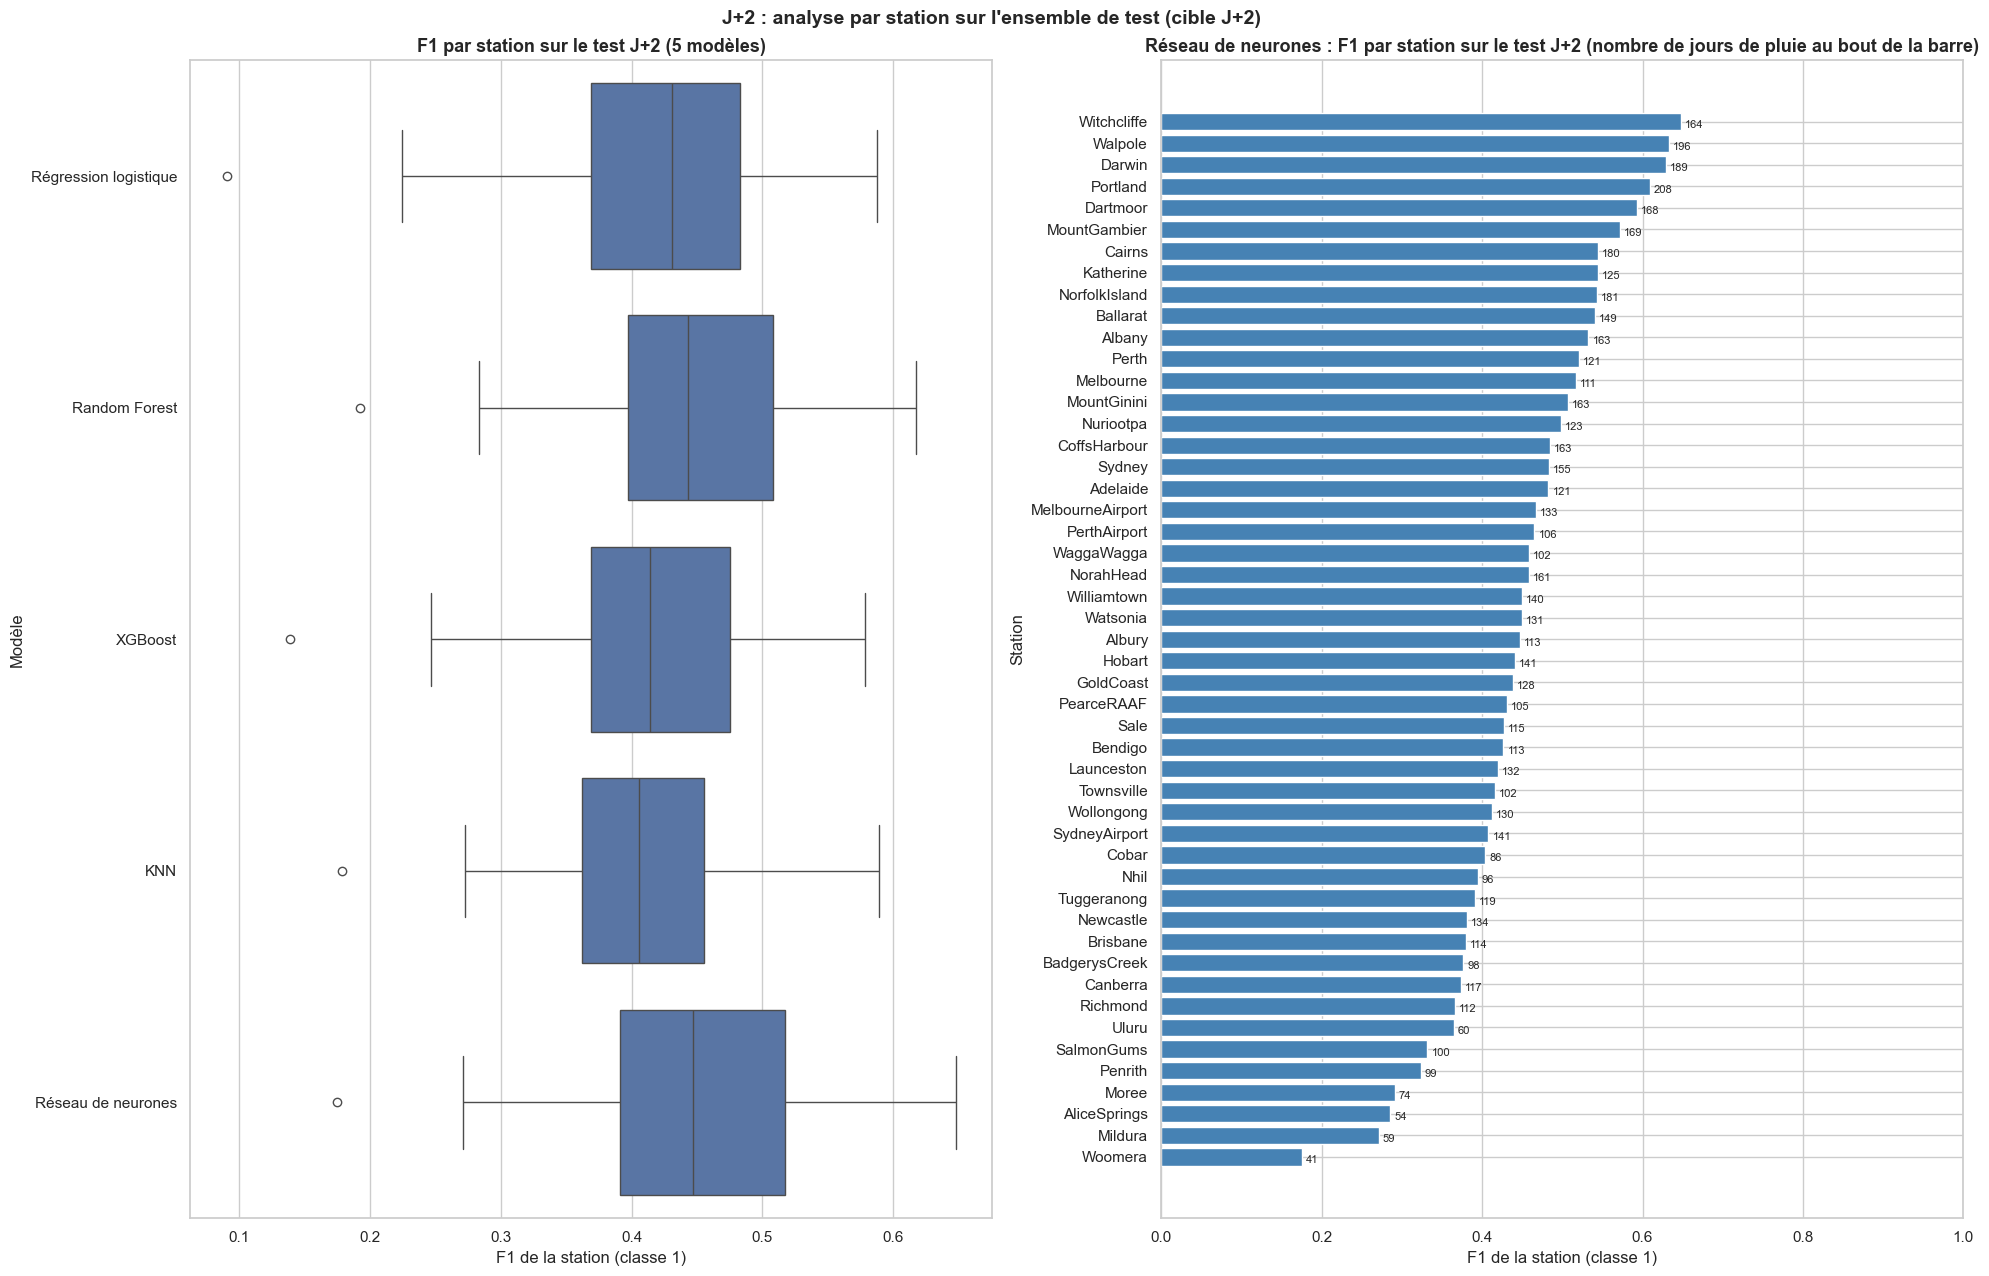

In [134]:
# CELL 134: J+2 : visualisation par station

ignorer_avertissements()

plt.figure(figsize=(20, 13))

# Panneau 1 : distribution du F1 par station pour les 5 modèles (boîtes horizontales)
plt.subplot(1, 2, 1)
sns.boxplot(x='F1', y='Modèle', data=table_stations_J2)
plt.title("F1 par station sur le test J+2 (5 modèles)", fontsize=13, fontweight='bold')
plt.xlabel("F1 de la station (classe 1)")
plt.ylabel("Modèle")

# Panneau 2 : F1 par station du meilleur modèle, nombre de jours de pluie du test au bout de chaque barre
table_graphique = table_meilleur_J2.sort_values('F1', ascending=True)
plt.subplot(1, 2, 2)
plt.barh(table_graphique['Station'], table_graphique['F1'], color='steelblue')
for i in range(len(table_graphique)):
    plt.text(table_graphique['F1'].values[i] + 0.005, i - 0.3, str(table_graphique['Jours de pluie'].values[i]), fontsize=8)
plt.title(f"{meilleur_modele_J2} : F1 par station sur le test J+2 (nombre de jours de pluie au bout de la barre)",
          fontsize=13, fontweight='bold')
plt.xlabel("F1 de la station (classe 1)")
plt.ylabel("Station")
plt.xlim(0, 1)

plt.suptitle("J+2 : analyse par station sur l'ensemble de test (cible J+2)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/etape3_18_analyse_par_station_J2.png', dpi=150)
print("Figure sauvegardée: figures/etape3_18_analyse_par_station_J2.png")
plt.show()

In [135]:
# CELL 135: Comparaison J+1 / J+2 sur l'ensemble de test

# Pour chaque modèle : F1, précision, rappel, AUC et seuil sur le test J+1 (CELL 58) et J+2
# (CELL 118), puis l'écart de F1 J+2 - J+1 (perte de fiabilité d'un jour à deux jours)
lignes_comparaison = []
for nom in modeles:
    r1 = table_test[table_test['Modèle'] == nom]
    r2 = table_test_J2[table_test_J2['Modèle'] == nom]
    lignes_comparaison.append({
        'Modèle': nom,
        'F1 J+1': round(r1['F1'].values[0], 4), 'F1 J+2': round(r2['F1'].values[0], 4),
        'Écart F1 (J+2 - J+1)': round(r2['F1'].values[0] - r1['F1'].values[0], 4),
        'Précision J+1': round(r1['Précision'].values[0], 4), 'Précision J+2': round(r2['Précision'].values[0], 4),
        'Rappel J+1': round(r1['Rappel'].values[0], 4), 'Rappel J+2': round(r2['Rappel'].values[0], 4),
        'AUC J+1': round(r1['AUC'].values[0], 4), 'AUC J+2': round(r2['AUC'].values[0], 4),
        'Seuil J+1': r1['Seuil'].values[0], 'Seuil J+2': r2['Seuil'].values[0]
    })
table_comparaison = pd.DataFrame(lignes_comparaison).sort_values('F1 J+1', ascending=False).reset_index().drop(columns=['index'])
print("Comparaison J+1 / J+2 sur l'ensemble de test (seuil retenu de chaque modèle):")
print(table_comparaison)

Comparaison J+1 / J+2 sur l'ensemble de test (seuil retenu de chaque modèle):
                  Modèle  F1 J+1  F1 J+2  Écart F1 (J+2 - J+1)  Précision J+1  Précision J+2  Rappel J+1  Rappel J+2  AUC J+1  AUC J+2  Seuil J+1  Seuil J+2
0                XGBoost  0.6596  0.4355               -0.2241         0.6124         0.3265      0.7146      0.6537   0.8823   0.6875      0.302      0.373
1     Réseau de neurones  0.6503  0.4709               -0.1794         0.6220         0.3464      0.6814      0.7354   0.8777   0.7340      0.306      0.459
2          Random Forest  0.6419  0.4628               -0.1791         0.5845         0.3381      0.7118      0.7331   0.8745   0.7251      0.438      0.461
3  Régression logistique  0.6154  0.4512               -0.1643         0.5624         0.3355      0.6795      0.6885   0.8504   0.7063      0.594      0.468
4                    KNN  0.5688  0.4209               -0.1479         0.4614         0.2908      0.7412      0.7615   0.8089   0.6591   